# CPSAM branching-length analysis

Decode every CPSAM prediction for one image and apply the exact reference skeleton-graph, branch-pruning, tree-metric algorithm.

In [11]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from skimage.morphology import skeletonize


PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").is_file()
)

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cnt_project.features.core.cnt_feature_extraction import (
    MICRONS_PER_PIXEL,
    decode_annotation_mask,
)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2


## Branching skeleton and edge-covering traversal

In [12]:
def skeleton_graph(skeleton):
    G = nx.Graph()
    pixels = set(map(tuple, np.argwhere(skeleton)))

    for p in pixels:
        G.add_node(p)

        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                q = (p[0] + dr, p[1] + dc)

                if q in pixels and q != p:
                    G.add_edge(
                        p,
                        q,
                        weight=np.hypot(dr, dc),
                    )

    return G

In [13]:
def prune_branches(G, min_length=20):
    G = G.copy()

    while True:
        endpoints = [
            n for n in G
            if G.degree[n] == 1
        ]

        removed = False

        for endpoint in endpoints:
            path = [endpoint]
            length = 0
            previous = None
            current = endpoint

            while G.degree[current] == 1 or G.degree[current] == 2:
                neighbours = [
                    n for n in G.neighbors(current)
                    if n != previous
                ]

                if not neighbours:
                    break

                nxt = neighbours[0]
                length += G[current][nxt]["weight"]
                path.append(nxt)
                previous, current = current, nxt

                if G.degree[current] != 2:
                    break

            if length < min_length:
                G.remove_nodes_from(path[:-1])
                removed = True
                break

        if not removed:
            break

    return G

In [14]:
# %%
def branch_traversal_path(
    G,
    diameter_path,
):
    if not diameter_path:
        return []

    diameter_edges = {
        frozenset(
            (
                start,
                end,
            )
        )
        for start, end in zip(
            diameter_path,
            diameter_path[1:],
        )
    }

    visited_off_diameter_edges = set()
    traversal_path = [
        diameter_path[0]
    ]

    def walk_off_diameter_branch(
        current,
    ):
        for neighbour in G.neighbors(
            current
        ):
            edge = frozenset(
                (
                    current,
                    neighbour,
                )
            )

            if (
                edge in diameter_edges
                or edge
                in visited_off_diameter_edges
            ):
                continue

            visited_off_diameter_edges.add(
                edge
            )

            traversal_path.append(
                neighbour
            )

            walk_off_diameter_branch(
                neighbour
            )

            traversal_path.append(
                current
            )

    for index, current in enumerate(
        diameter_path
    ):
        walk_off_diameter_branch(
            current
        )

        if index < len(diameter_path) - 1:
            traversal_path.append(
                diameter_path[index + 1]
            )

    return traversal_path


def edge_covering_walk(
    G,
):
    """
    Return a shortest closed walk covering every edge
    in a connected graph.
    """
    if G.number_of_nodes() == 0:
        return [], 0.0

    if G.number_of_edges() == 0:
        node = next(
            iter(G.nodes)
        )

        return [
            node
        ], 0.0

    odd_nodes = [
        node
        for node in G
        if G.degree[node] % 2
    ]

    distances = dict(
        nx.all_pairs_dijkstra_path_length(
            G,
            weight="weight",
        )
    )

    paths = dict(
        nx.all_pairs_dijkstra_path(
            G,
            weight="weight",
        )
    )

    matching_graph = nx.Graph()

    matching_graph.add_nodes_from(
        odd_nodes
    )

    for index, first in enumerate(
        odd_nodes
    ):
        for second in odd_nodes[
            index + 1:
        ]:
            matching_graph.add_edge(
                first,
                second,
                weight=distances[
                    first
                ][second],
            )

    matching = (
        nx.algorithms.matching
        .min_weight_matching(
            matching_graph,
            weight="weight",
        )
    )

    augmented = nx.MultiGraph(
        G
    )

    for first, second in matching:
        shortest_path = paths[
            first
        ][second]

        for start, end in zip(
            shortest_path,
            shortest_path[1:],
        ):
            augmented.add_edge(
                start,
                end,
                weight=G[
                    start
                ][end]["weight"],
            )

    euler_edges = list(
        nx.eulerian_circuit(
            augmented,
            keys=True,
        )
    )

    walk = [
        euler_edges[0][0]
    ]

    for _, end, _ in euler_edges:
        walk.append(end)

    walk_length = augmented.size(
        weight="weight"
    )

    return (
        walk,
        walk_length,
    )


def tree_metrics(
    G,
):
    tree_length = G.size(
        weight="weight"
    )

    diameter_length = 0
    diameter_path = []
    traversal_length = 0
    traversal_paths = []

    for component_nodes in (
        nx.connected_components(G)
    ):
        component = G.subgraph(
            component_nodes
        ).copy()

        endpoints = [
            node
            for node in component
            if component.degree[node] == 1
        ]

        if not endpoints:
            endpoints = list(
                component.nodes
            )

        component_diameter_length = 0
        component_diameter_path = [
            endpoints[0]
        ]

        for start in endpoints:
            lengths, paths = (
                nx.single_source_dijkstra(
                    component,
                    start,
                    weight="weight",
                )
            )

            for end in endpoints:
                if (
                    lengths[end]
                    > component_diameter_length
                ):
                    component_diameter_length = (
                        lengths[end]
                    )

                    component_diameter_path = (
                        paths[end]
                    )

        (
            traversal_path,
            component_traversal_length,
        ) = edge_covering_walk(
            component
        )

        traversal_length += (
            component_traversal_length
        )

        traversal_paths.append(
            traversal_path
        )

        if (
            component_diameter_length
            > diameter_length
        ):
            diameter_length = (
                component_diameter_length
            )

            diameter_path = (
                component_diameter_path
            )

    return (
        tree_length,
        diameter_length,
        traversal_length,
        diameter_path,
        traversal_paths,
    )

In [15]:
def branching_skeleton_length(
    mask,
    min_branch_length=None,
):
    skeleton = skeletonize(
        mask
    )

    G = skeleton_graph(
        skeleton
    )

    if min_branch_length is not None:
        G = prune_branches(
            G,
            min_length=min_branch_length,
        )

    (
        tree_length,
        diameter,
        traversal,
        diameter_path,
        traversal_paths,
    ) = tree_metrics(
        G
    )

    tree = np.zeros_like(
        mask,
        dtype=bool,
    )

    for r, c in G.nodes:
        tree[
            r,
            c,
        ] = True

    return {
        "skeleton": skeleton,
        "tree": tree,
        "graph": G,
        "tree_length": tree_length,
        "diameter": diameter,
        "traversal_length": traversal,
        "diameter_path": diameter_path,
        "traversal_paths": traversal_paths,
    }

In [21]:
def extract_graph_branches(
    graph,
):
    """
    Extract maximal graph paths between endpoints and junctions.

    Every graph edge belongs to exactly one returned branch.
    """
    visited_edges = set()
    branches = []

    critical_nodes = {
        node
        for node in graph
        if graph.degree[node] != 2
    }

    for start in critical_nodes:
        for neighbour in graph.neighbors(
            start
        ):
            first_edge = frozenset(
                (
                    start,
                    neighbour,
                )
            )

            if first_edge in visited_edges:
                continue

            visited_edges.add(
                first_edge
            )

            path = [
                start,
                neighbour,
            ]

            previous = start
            current = neighbour

            while graph.degree[current] == 2:
                candidates = [
                    node
                    for node in graph.neighbors(
                        current
                    )
                    if node != previous
                ]

                if not candidates:
                    break

                next_node = candidates[0]

                edge = frozenset(
                    (
                        current,
                        next_node,
                    )
                )

                if edge in visited_edges:
                    break

                visited_edges.add(edge)
                path.append(next_node)

                previous = current
                current = next_node

            length = float(
                sum(
                    graph[first][second][
                        "weight"
                    ]
                    for first, second in zip(
                        path,
                        path[1:],
                    )
                )
            )

            branches.append(
                {
                    "path": path,
                    "length": length,
                }
            )

    # Handle any remaining edges, such as a closed cycle
    # containing no endpoint or junction.
    for first, second in graph.edges:
        edge = frozenset(
            (
                first,
                second,
            )
        )

        if edge in visited_edges:
            continue

        visited_edges.add(edge)

        path = [
            first,
            second,
        ]

        previous = first
        current = second

        while True:
            candidates = [
                node
                for node in graph.neighbors(
                    current
                )
                if (
                    node != previous
                    and frozenset(
                        (
                            current,
                            node,
                        )
                    )
                    not in visited_edges
                )
            ]

            if not candidates:
                break

            next_node = candidates[0]

            visited_edges.add(
                frozenset(
                    (
                        current,
                        next_node,
                    )
                )
            )

            path.append(next_node)

            previous = current
            current = next_node

        length = float(
            sum(
                graph[start][end]["weight"]
                for start, end in zip(
                    path,
                    path[1:],
                )
            )
        )

        branches.append(
            {
                "path": path,
                "length": length,
            }
        )

    return branches

## Load one CPSAM image

In [16]:
CPSAM_RLE_JSON = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / "cpsam_v2_legacy_seed42_best_validation_optimized"
    / "inference"
    / "predicted_annotations_rle.json"
)

TARGET_FILENAME = "400-1093-w11-c1p1-befo3-10sp-15flow_left"

coco = json.loads(
    CPSAM_RLE_JSON.read_text(encoding="utf-8-sig")
)

target_image = next(
    image
    for image in coco["images"]
    if Path(image["file_name"]).stem.lower()
    == TARGET_FILENAME.lower()
)

target_annotations = [
    annotation
    for annotation in coco["annotations"]
    if int(annotation["image_id"]) == int(target_image["id"])
]

print("Image ID:", target_image["id"])
print("Filename:", target_image["file_name"])
print("Number of predictions:", len(target_annotations))

Image ID: 2
Filename: 400-1093-w11-c1p1-befo3-10sp-15flow_left.tif
Number of predictions: 168


## Calculate all prediction lengths

In [17]:
length_rows = []
object_data = {}

height = int(target_image["height"])
width = int(target_image["width"])

for object_index, annotation in enumerate(target_annotations):
    annotation_id = int(annotation["id"])

    mask = decode_annotation_mask(
        annotation,
        height,
        width,
    ).astype(bool)

    result = branching_skeleton_length(
        mask,
        min_branch_length=None,
    )

    length_rows.append(
        {
            "object_index": object_index,
            "annotation_id": annotation_id,
            "mask_area_px": int(mask.sum()),
            "tree_length_px": result["tree_length"],
            "tree_length_um": result["tree_length"] * MICRONS_PER_PIXEL,
            "diameter_px": result["diameter"],
            "diameter_um": result["diameter"] * MICRONS_PER_PIXEL,
            "traversal_length_px": result["traversal_length"],
            "traversal_length_um": result["traversal_length"] * MICRONS_PER_PIXEL,
        }
    )

    object_data[annotation_id] = {
        "mask": mask,
        **result,
    }

length_results = pd.DataFrame(length_rows)
display(length_results)

,object_index,annotation_id,mask_area_px,tree_length_px,tree_length_um,diameter_px,diameter_um,traversal_length_px,traversal_length_um
0,0,117,36,10.656854,0.208142,10.656854,0.208142,21.313708,0.416283
1,1,118,188,42.142136,0.823089,38.313708,0.748315,80.870058,1.579493
2,2,119,33,2.000000,0.039062,2.000000,0.039062,4.000000,0.078125
3,3,120,46,13.242641,0.258645,13.242641,0.258645,26.485281,0.517291
4,4,121,44,8.656854,0.169079,8.656854,0.169079,17.313708,0.338158
...,...,...,...,...,...,...,...,...,...
163,163,280,163,37.071068,0.724044,37.071068,0.724044,74.142136,1.448089
164,164,281,28,7.242641,0.141458,7.242641,0.141458,14.485281,0.282916
165,165,282,39,14.071068,0.274826,10.242641,0.200052,24.727922,0.482967
166,166,283,47,9.828427,0.191961,9.828427,0.191961,19.656854,0.383923


## Visualize every annotation

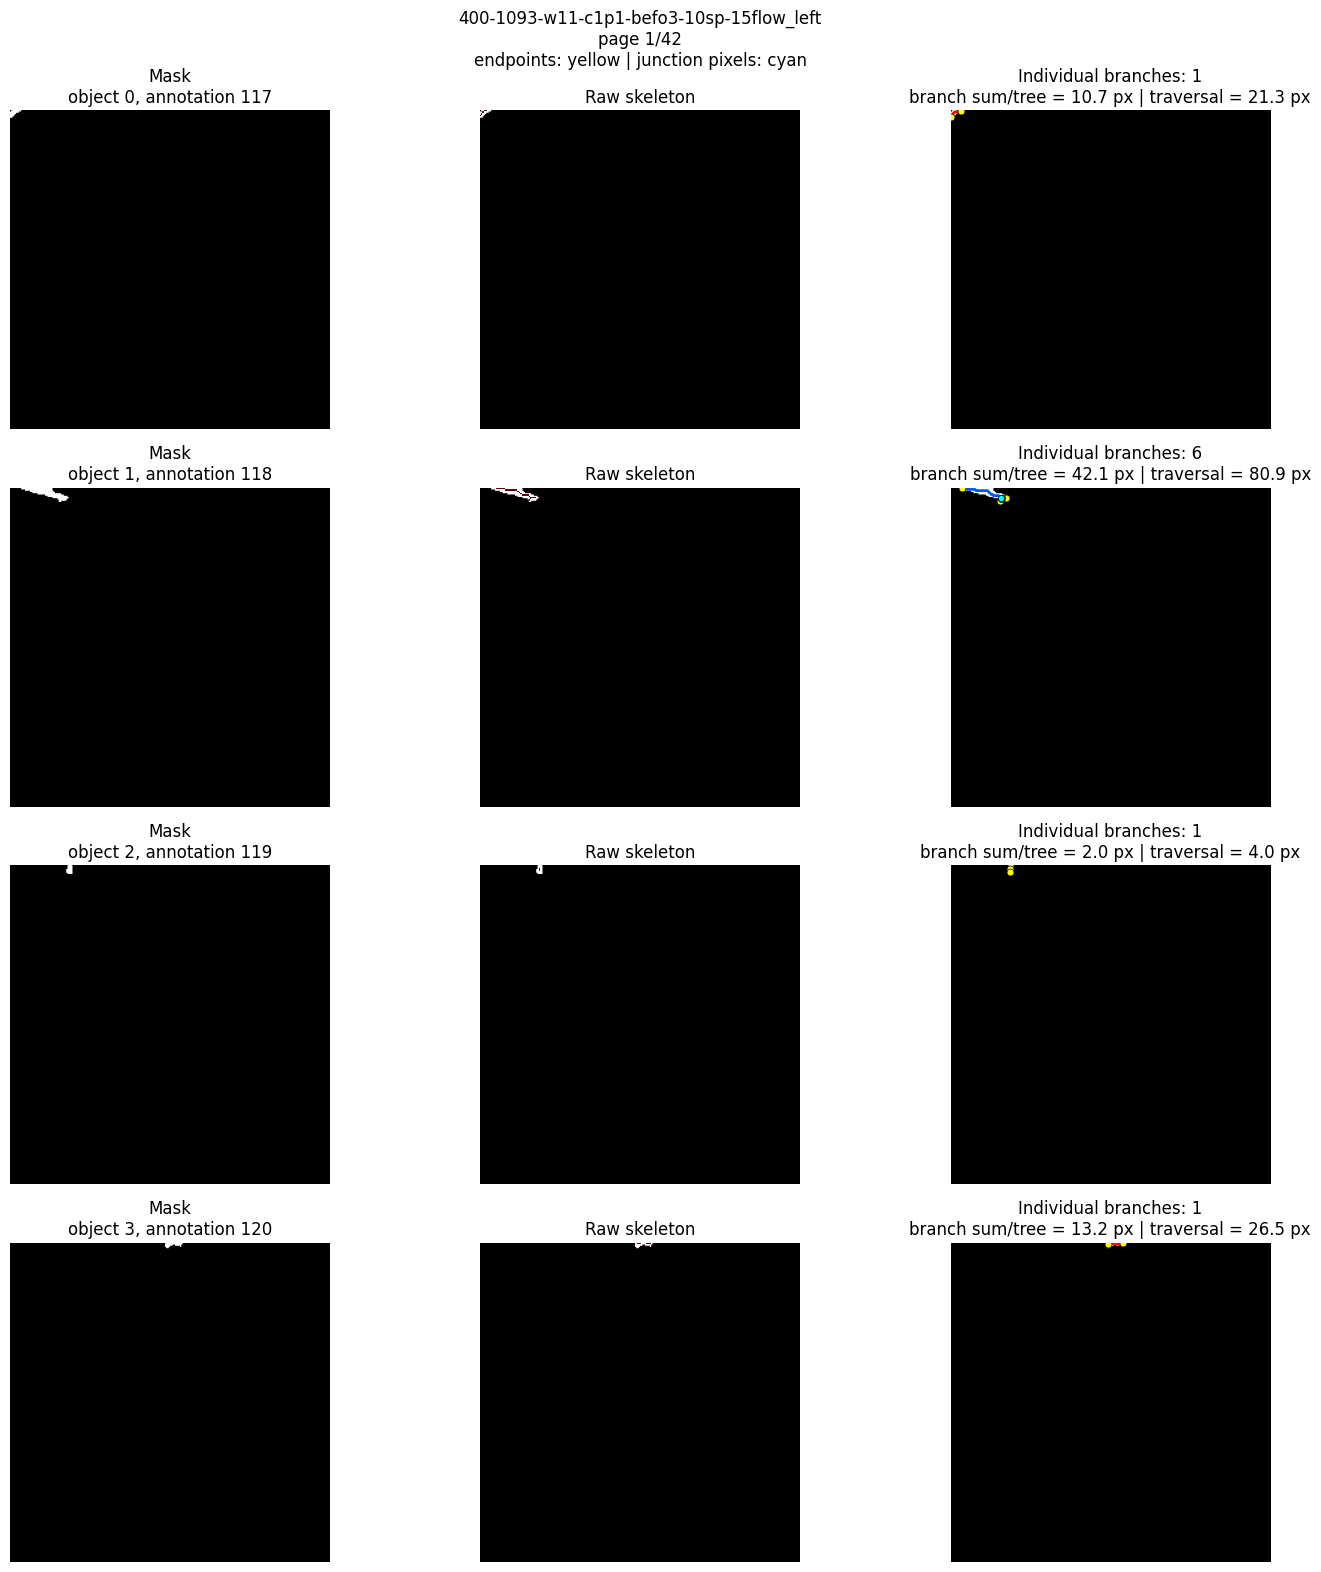

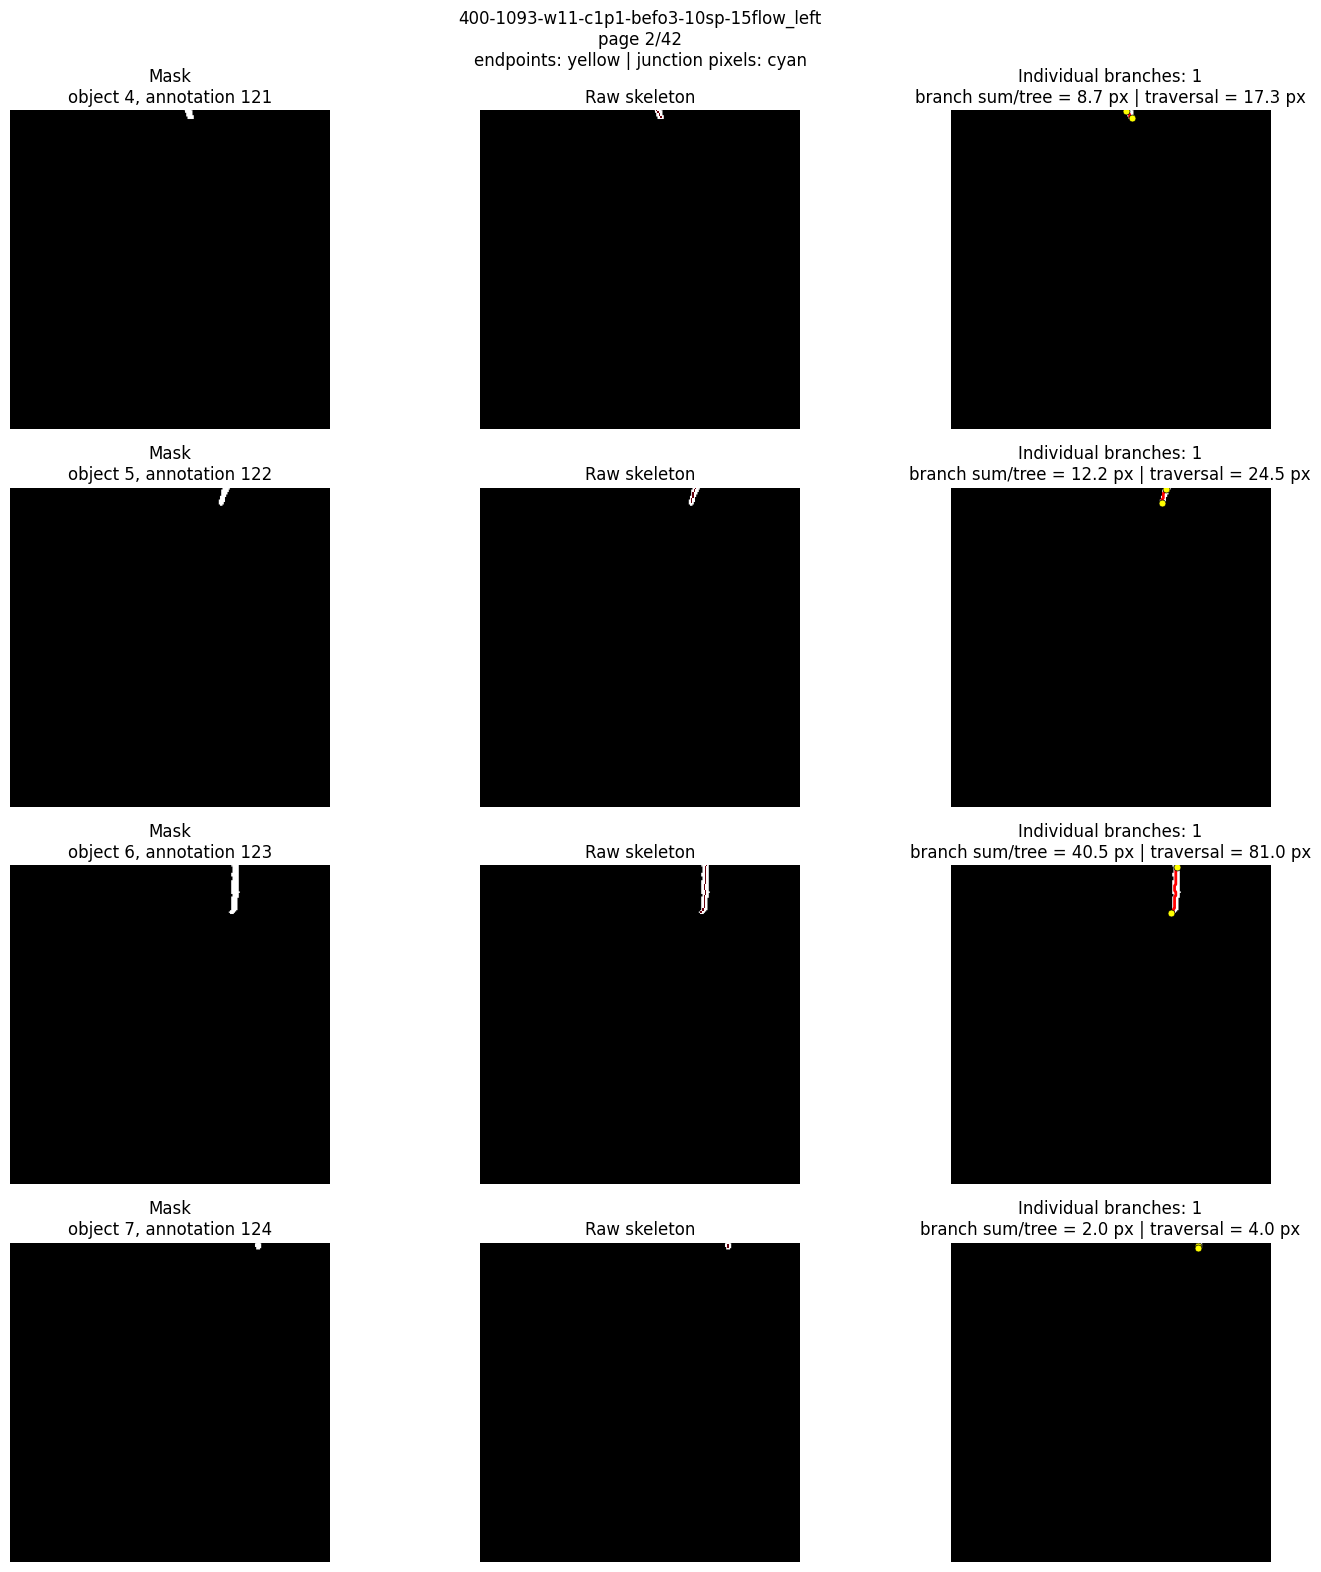

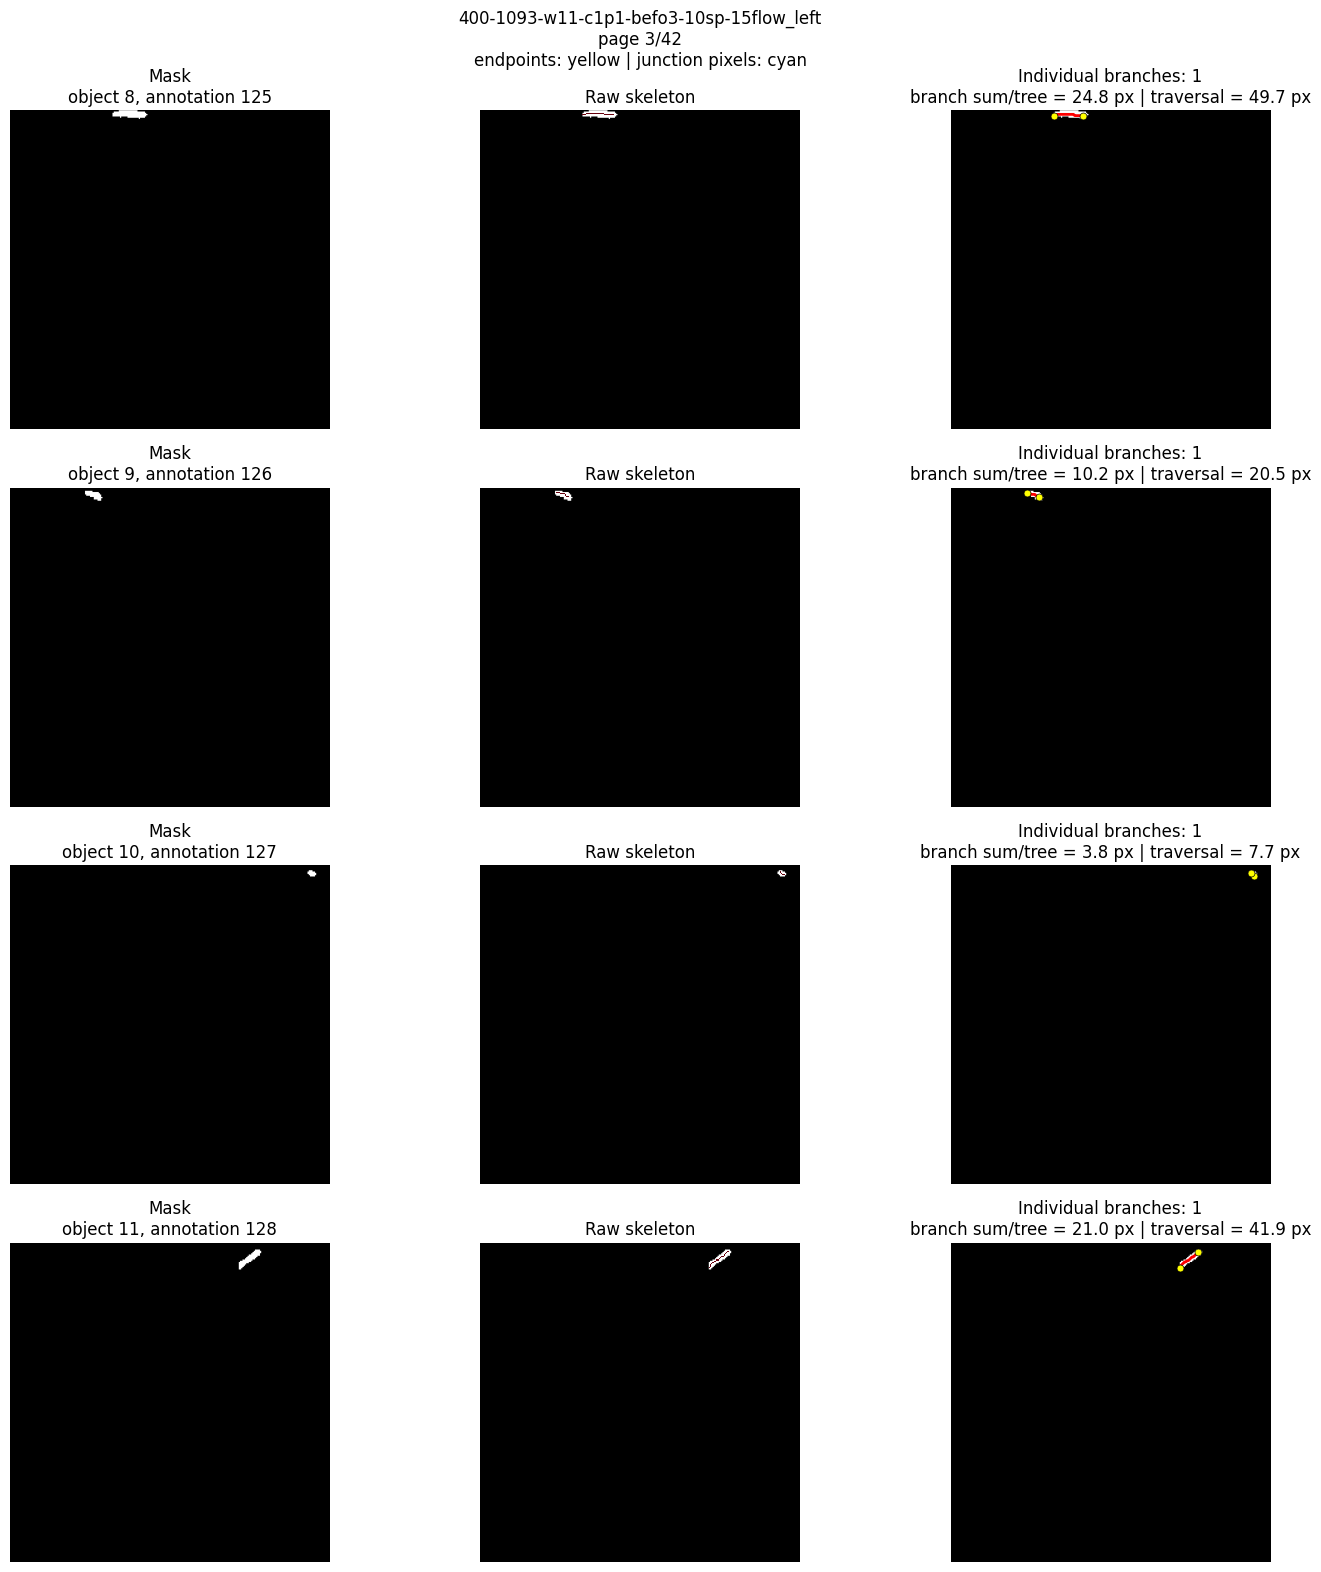

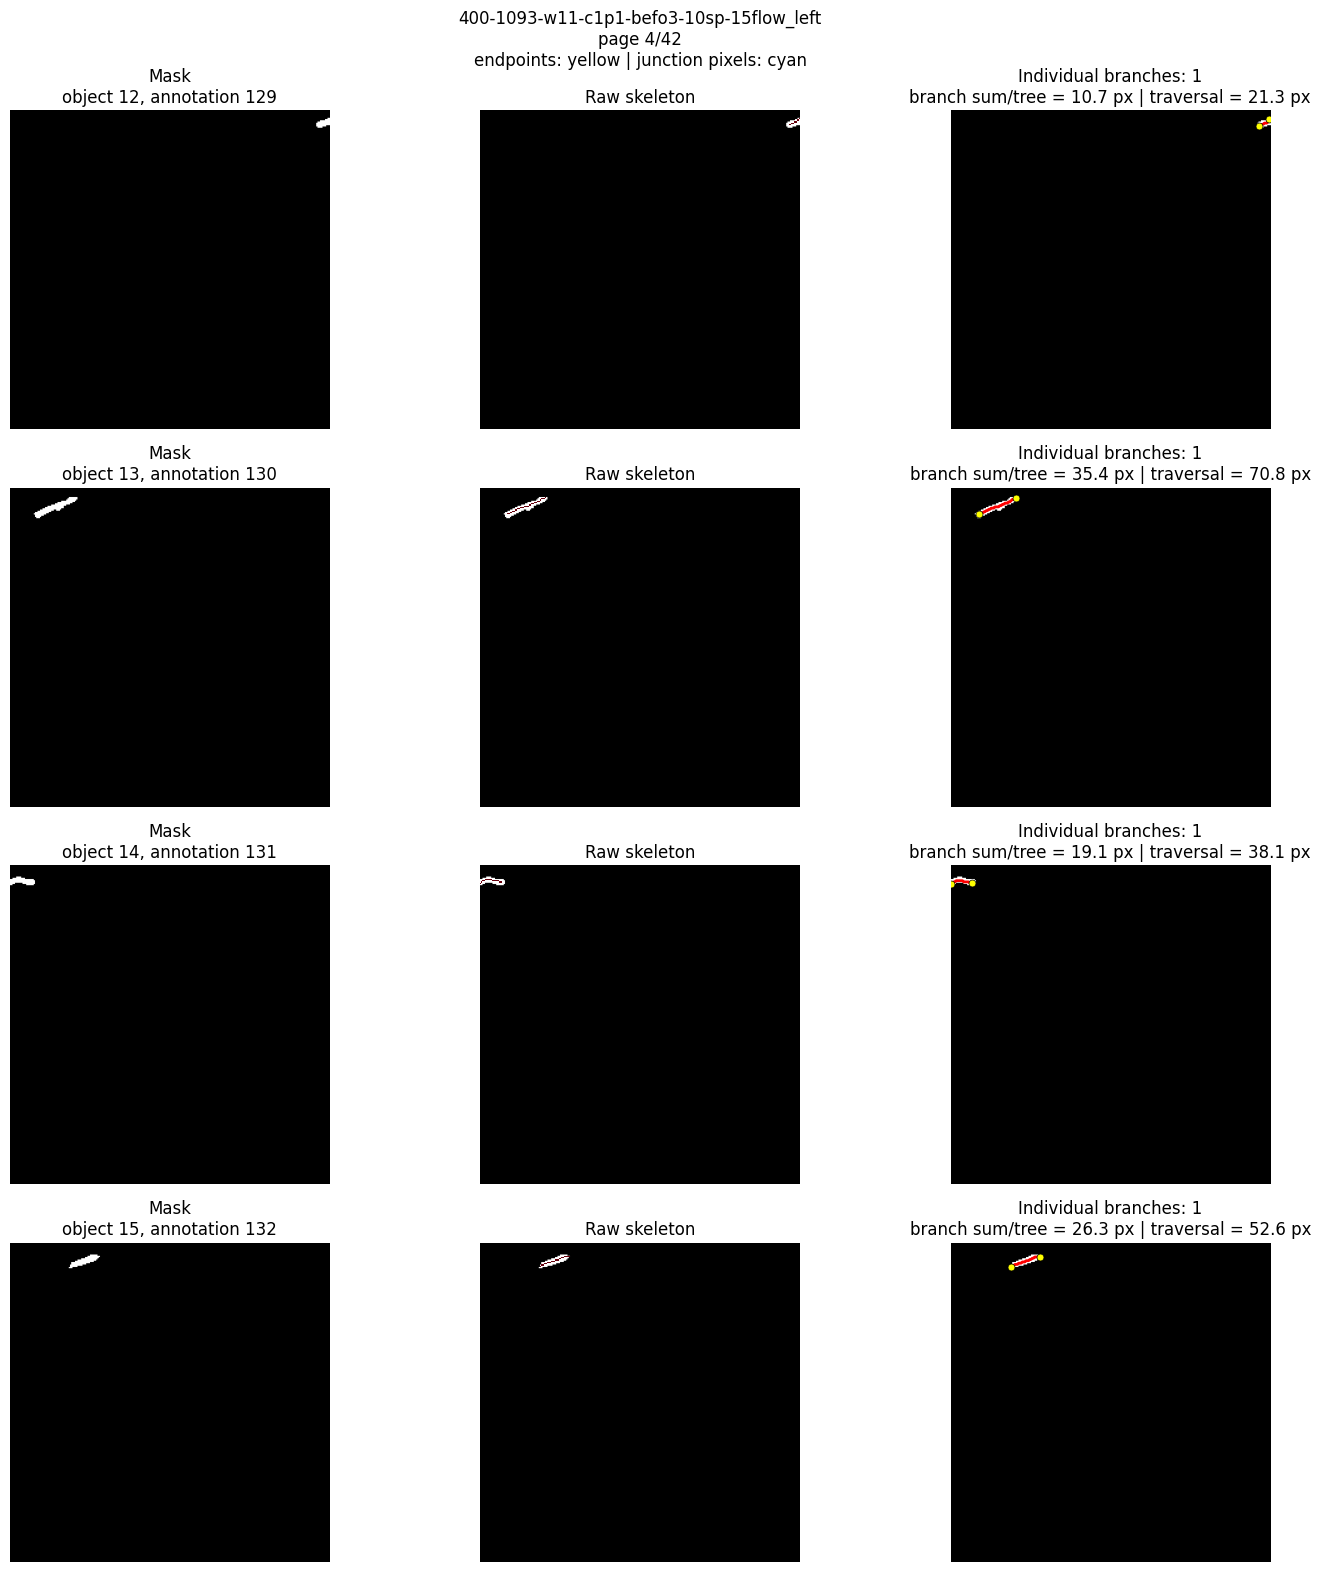

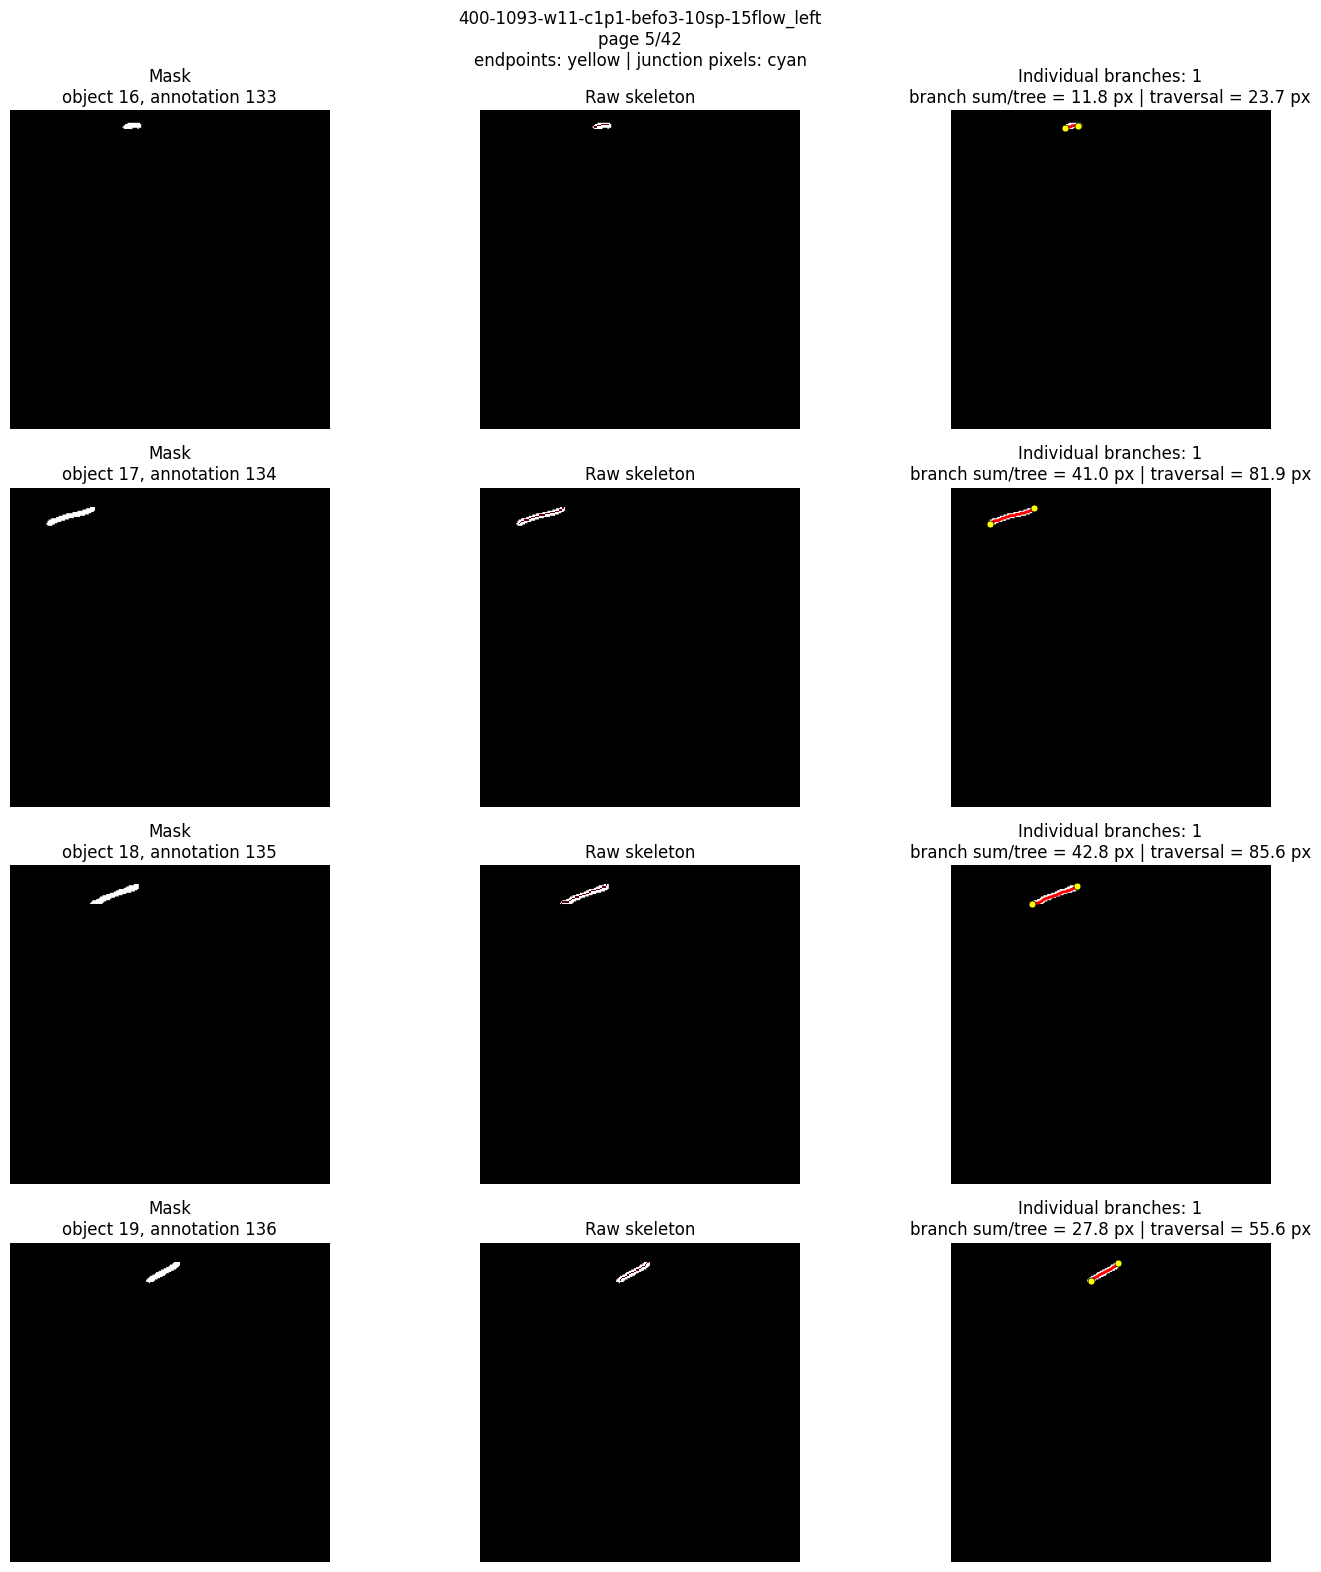

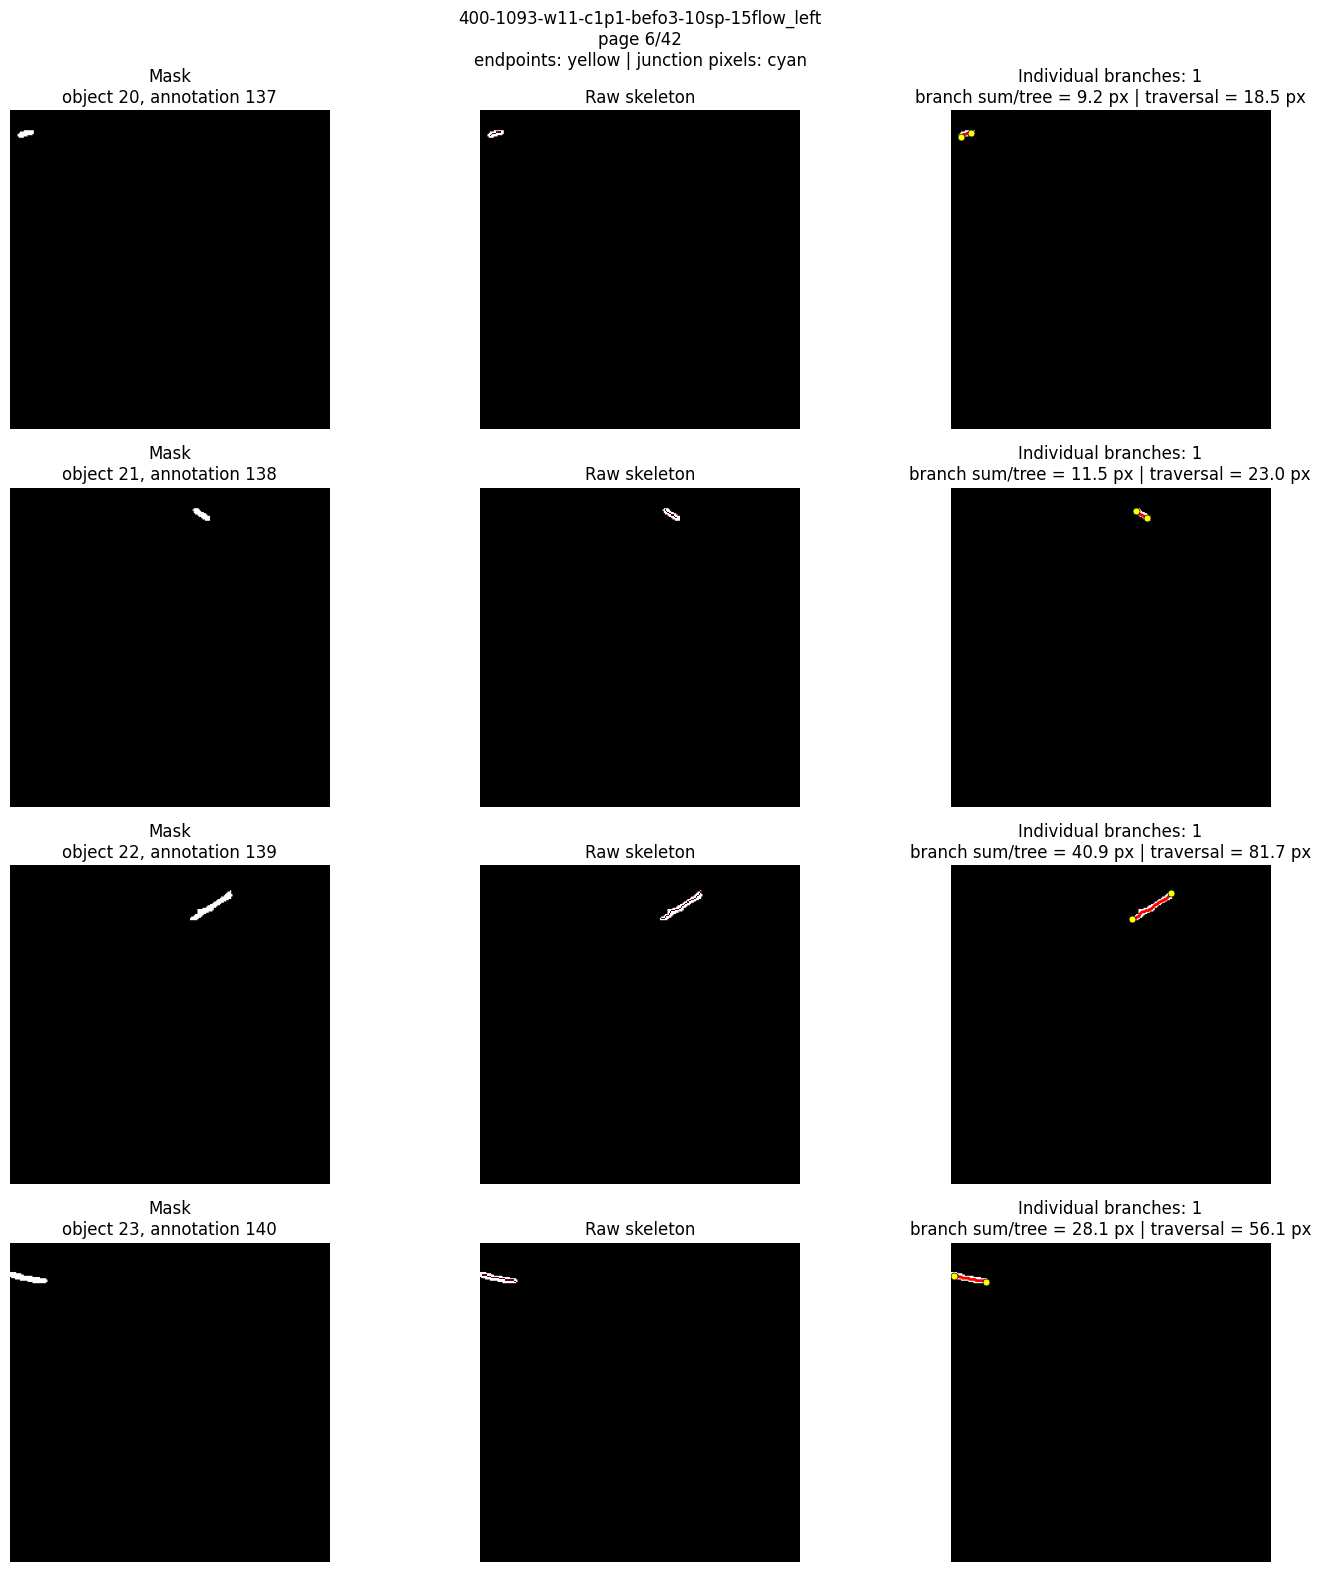

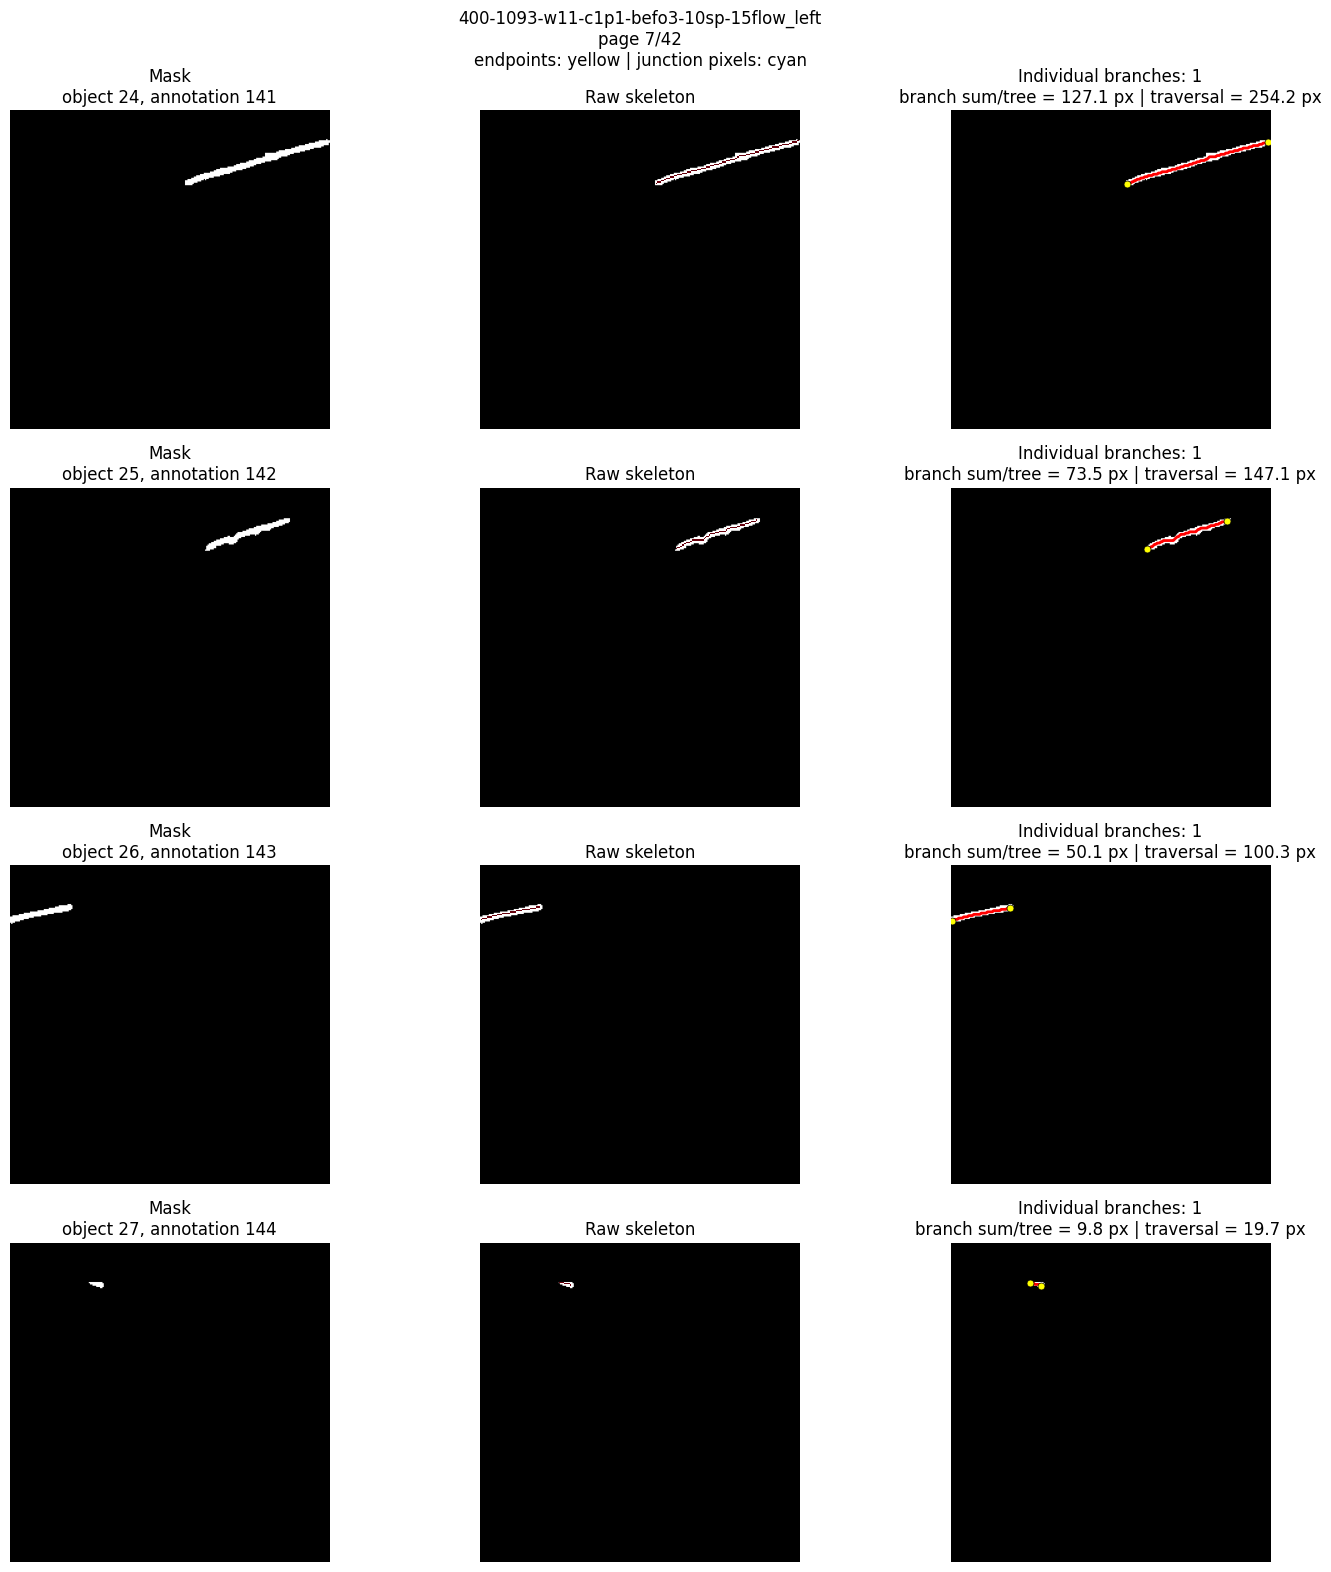

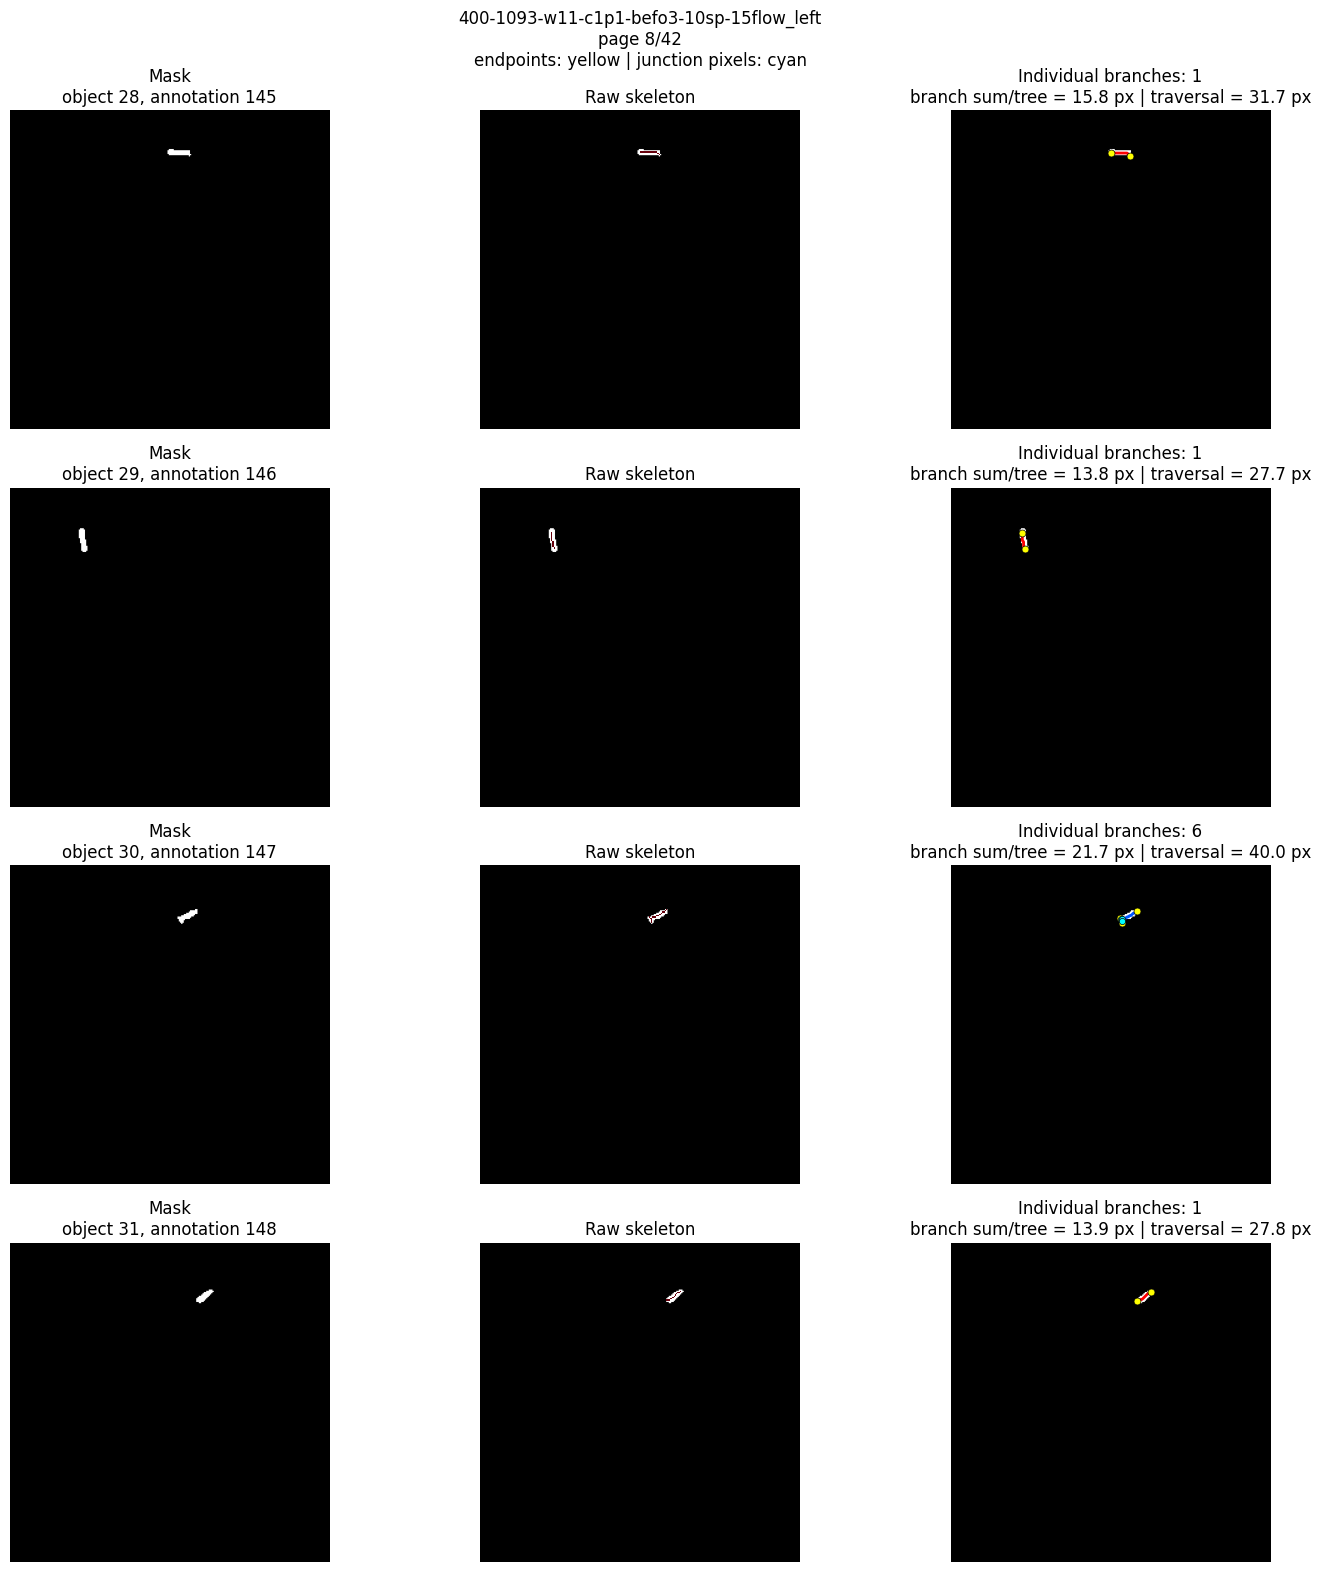

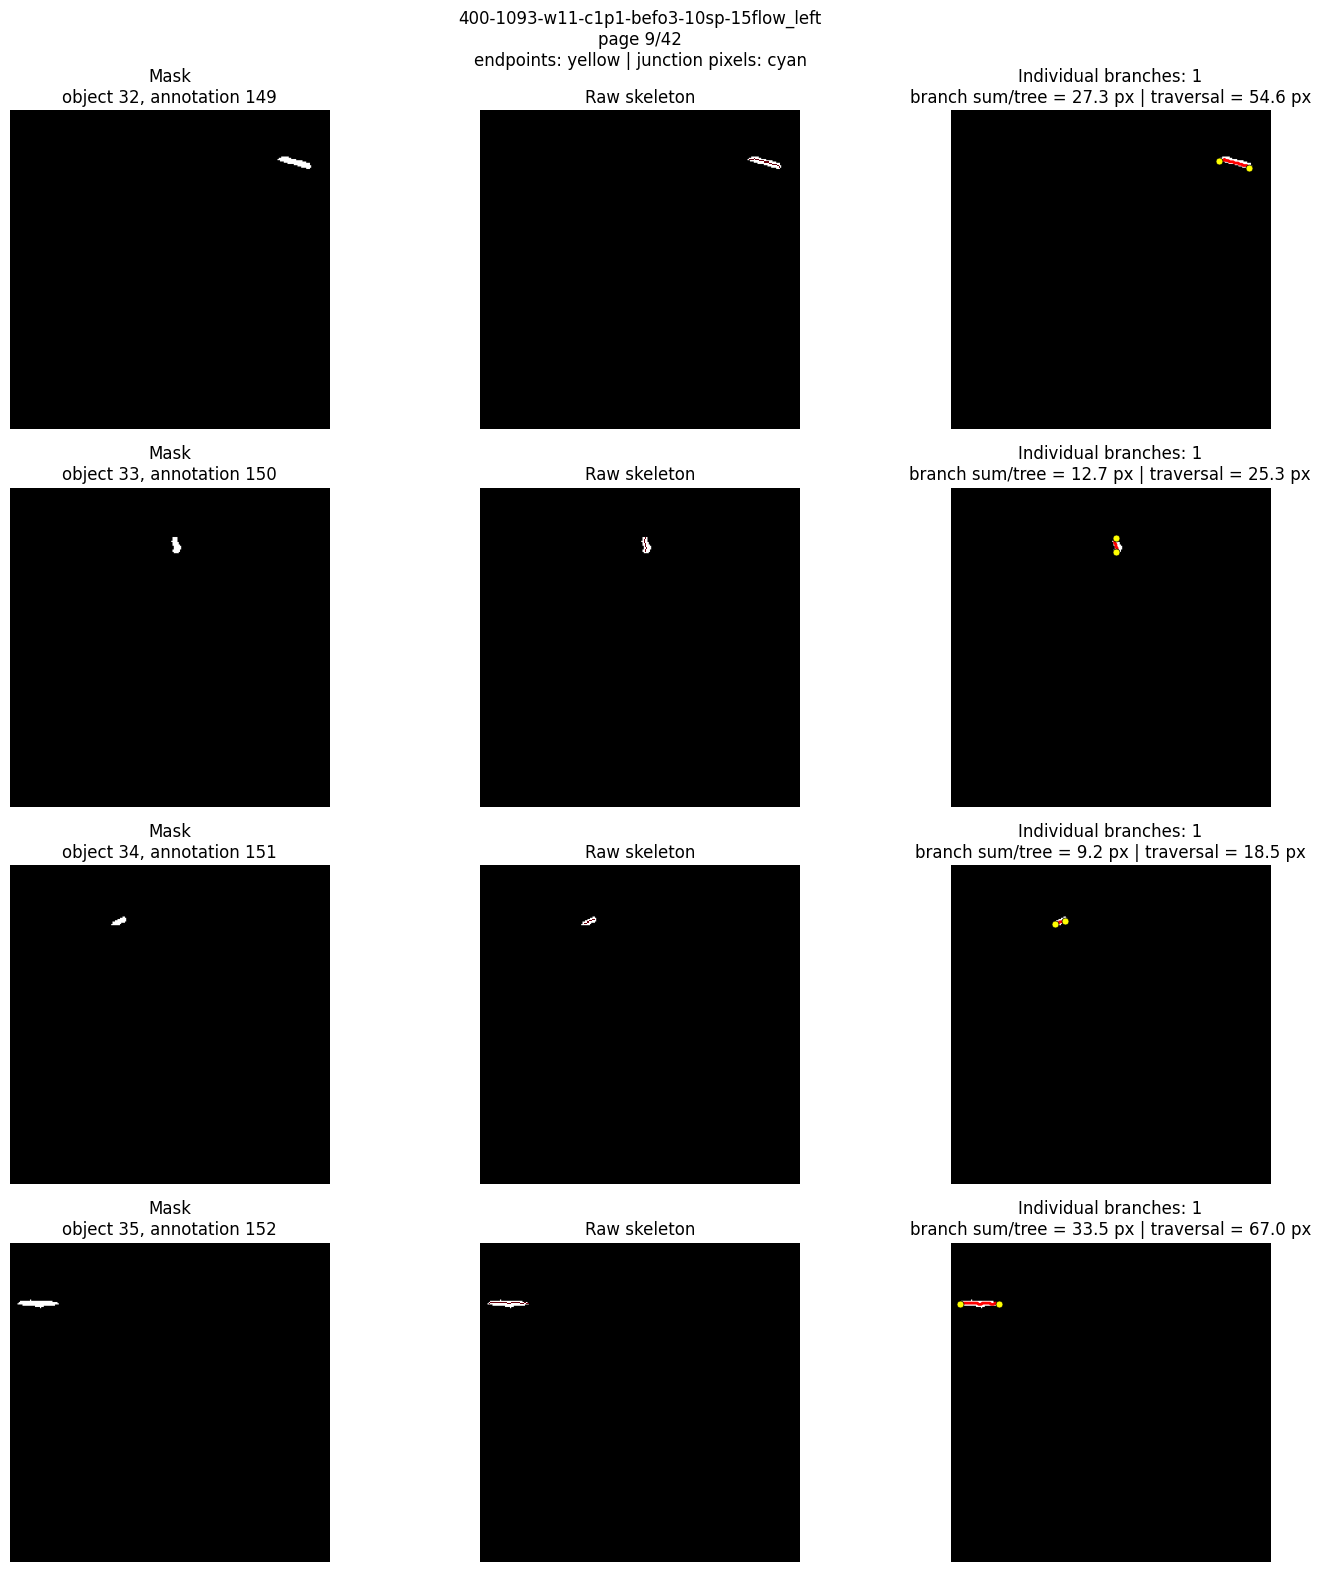

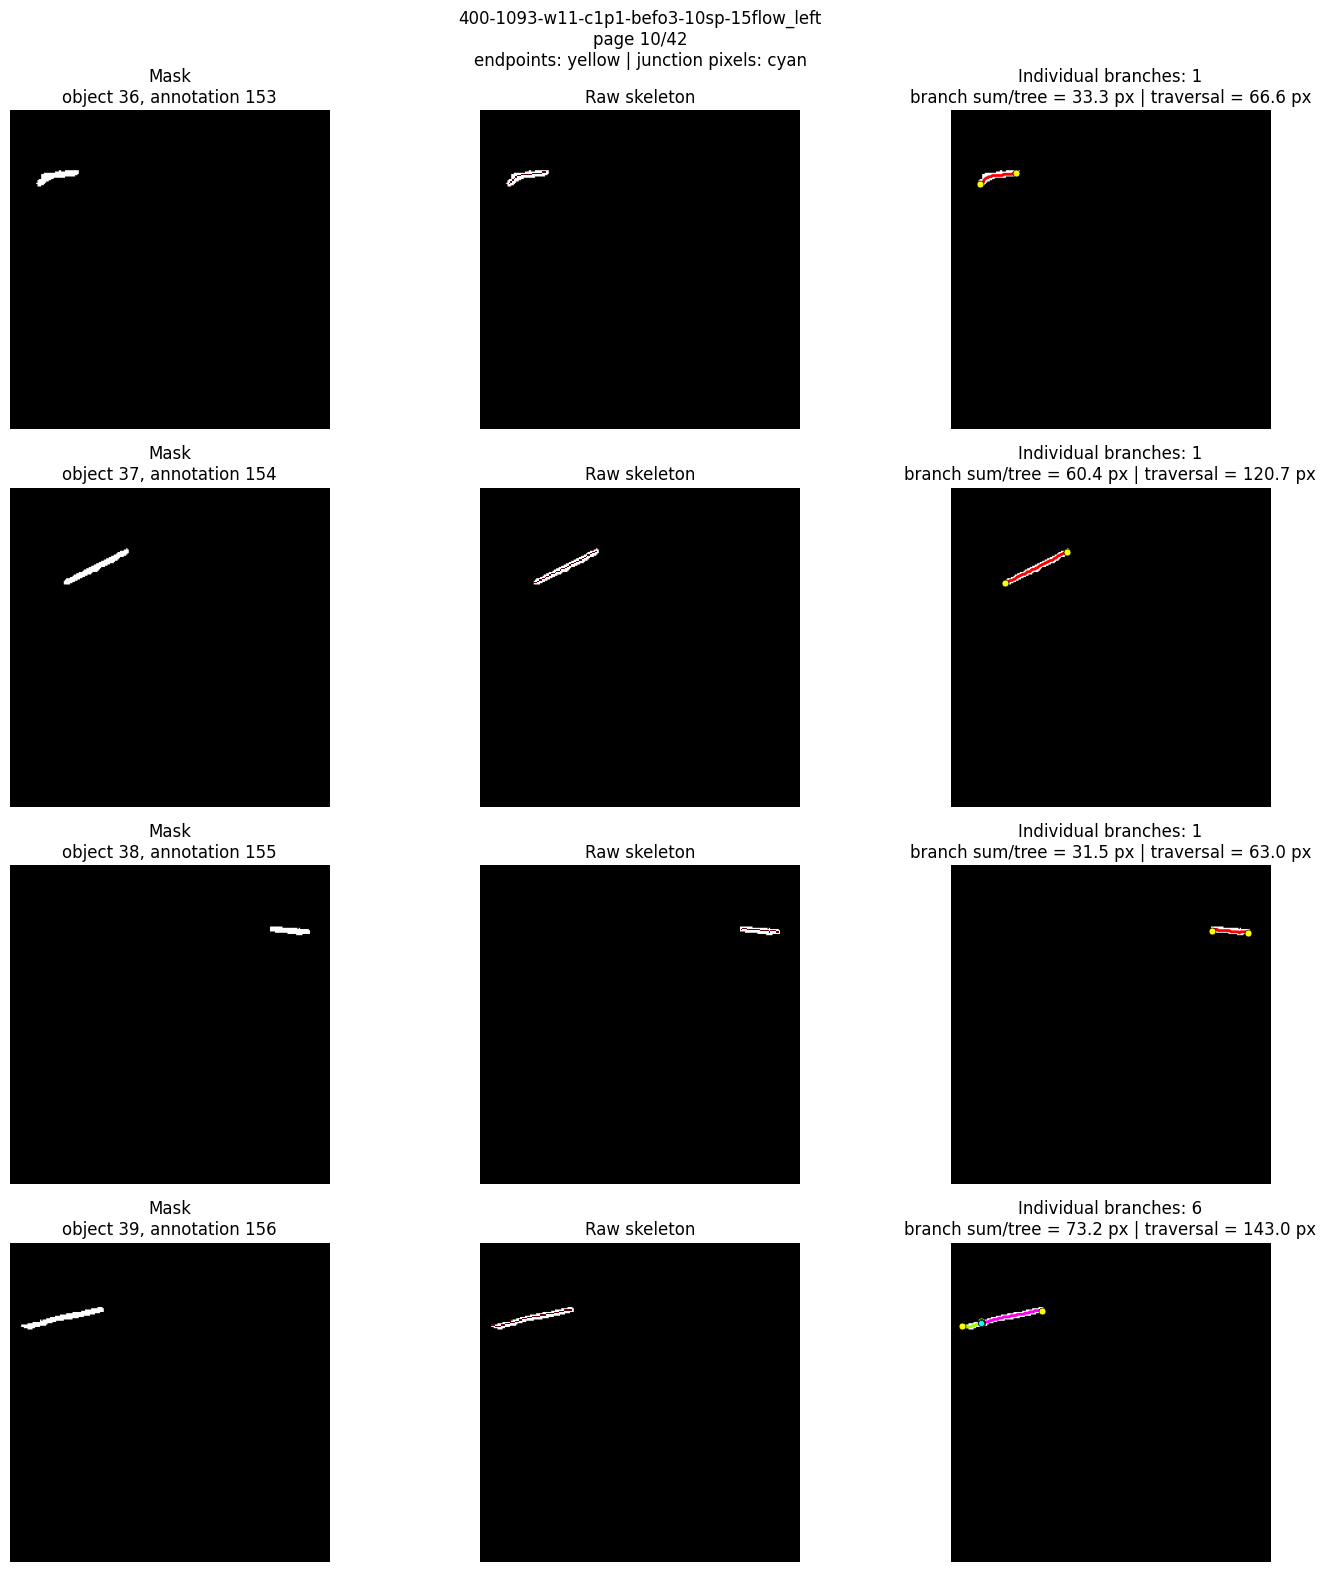

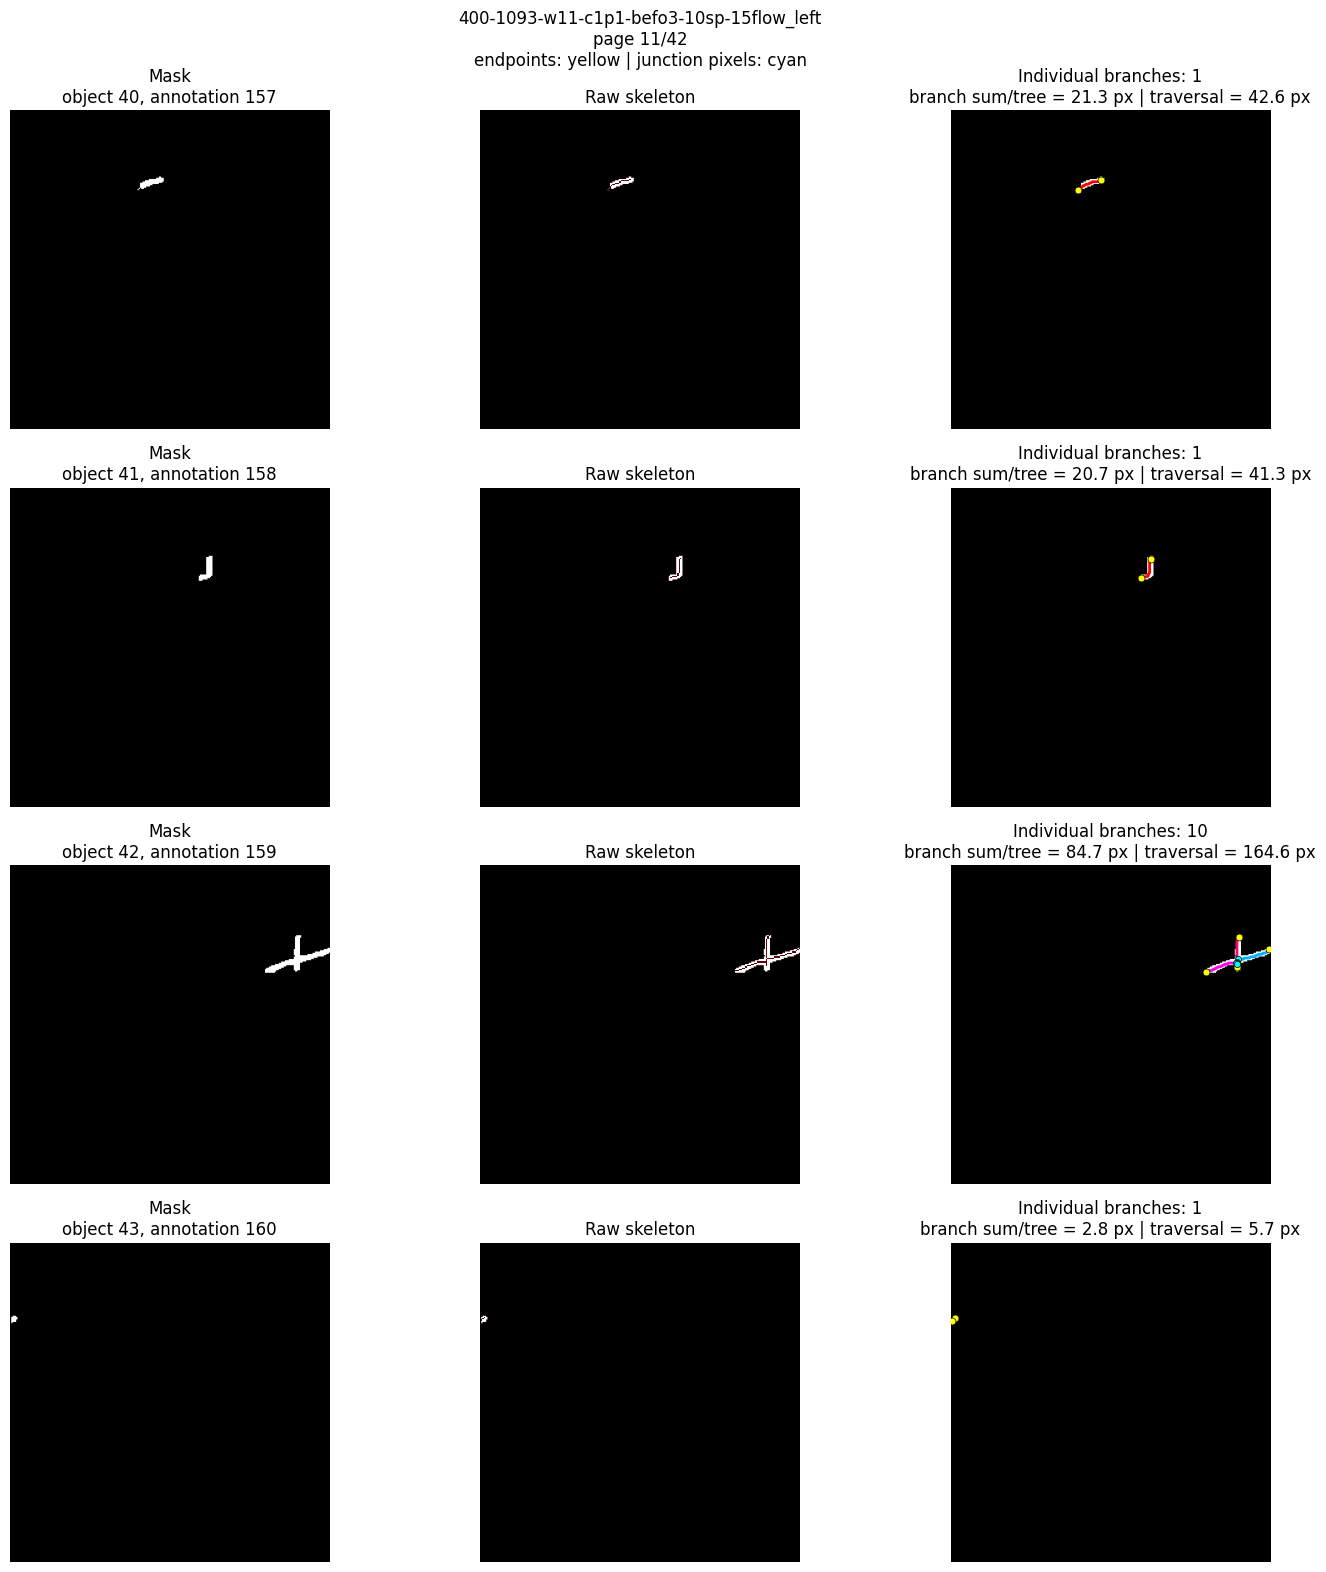

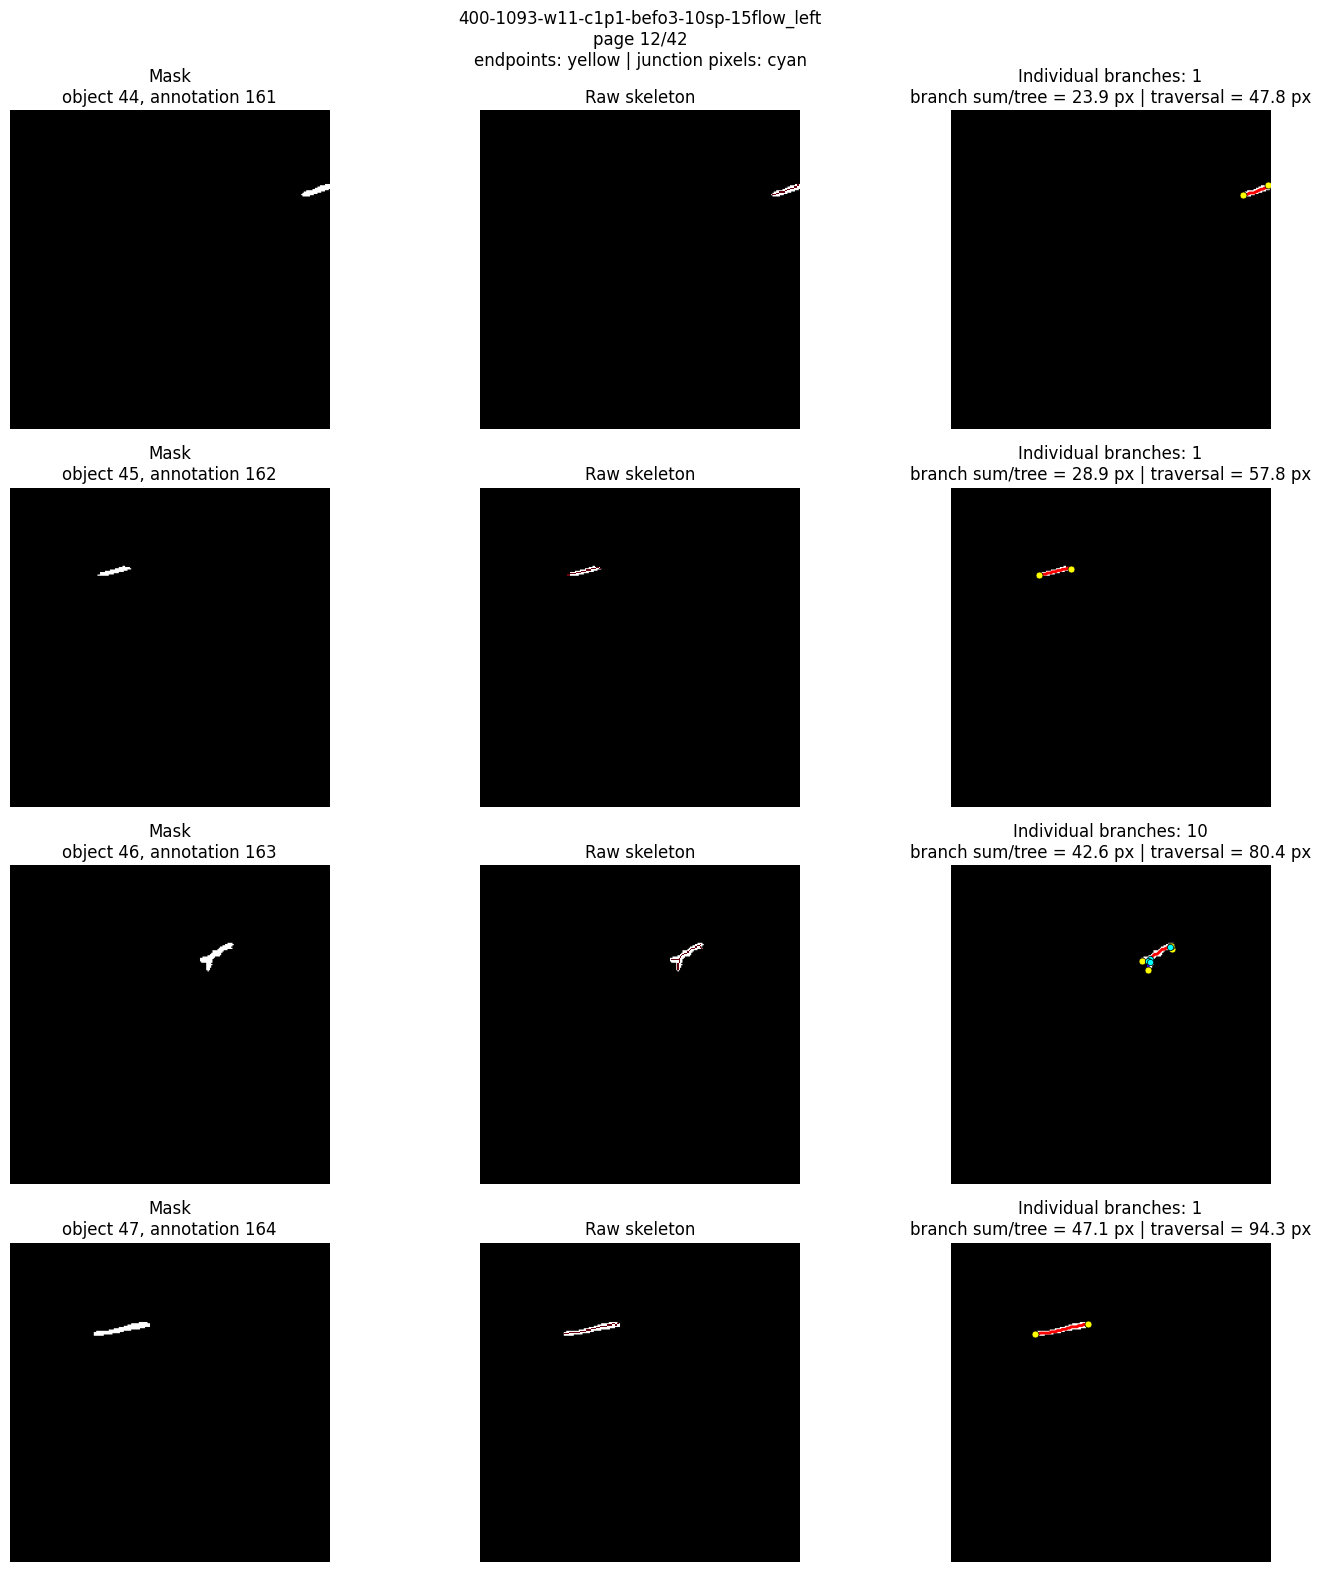

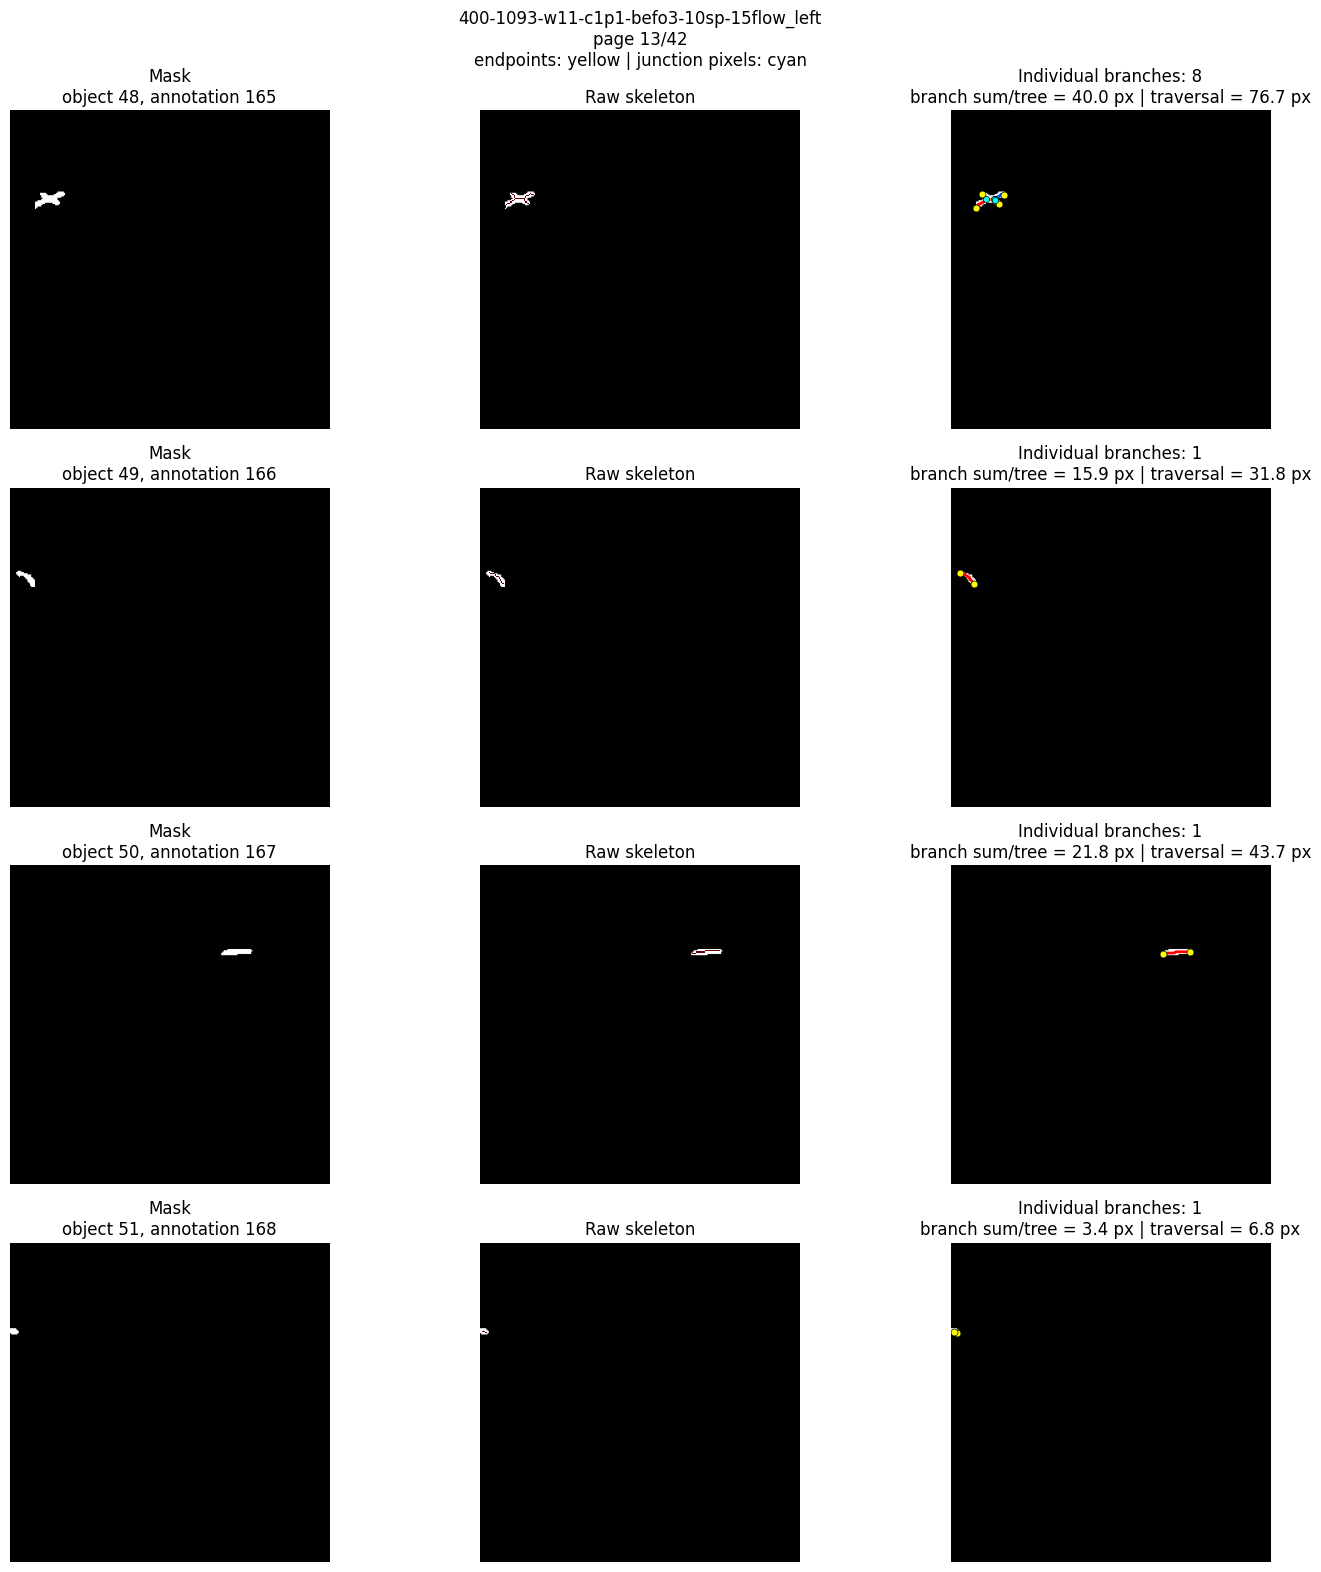

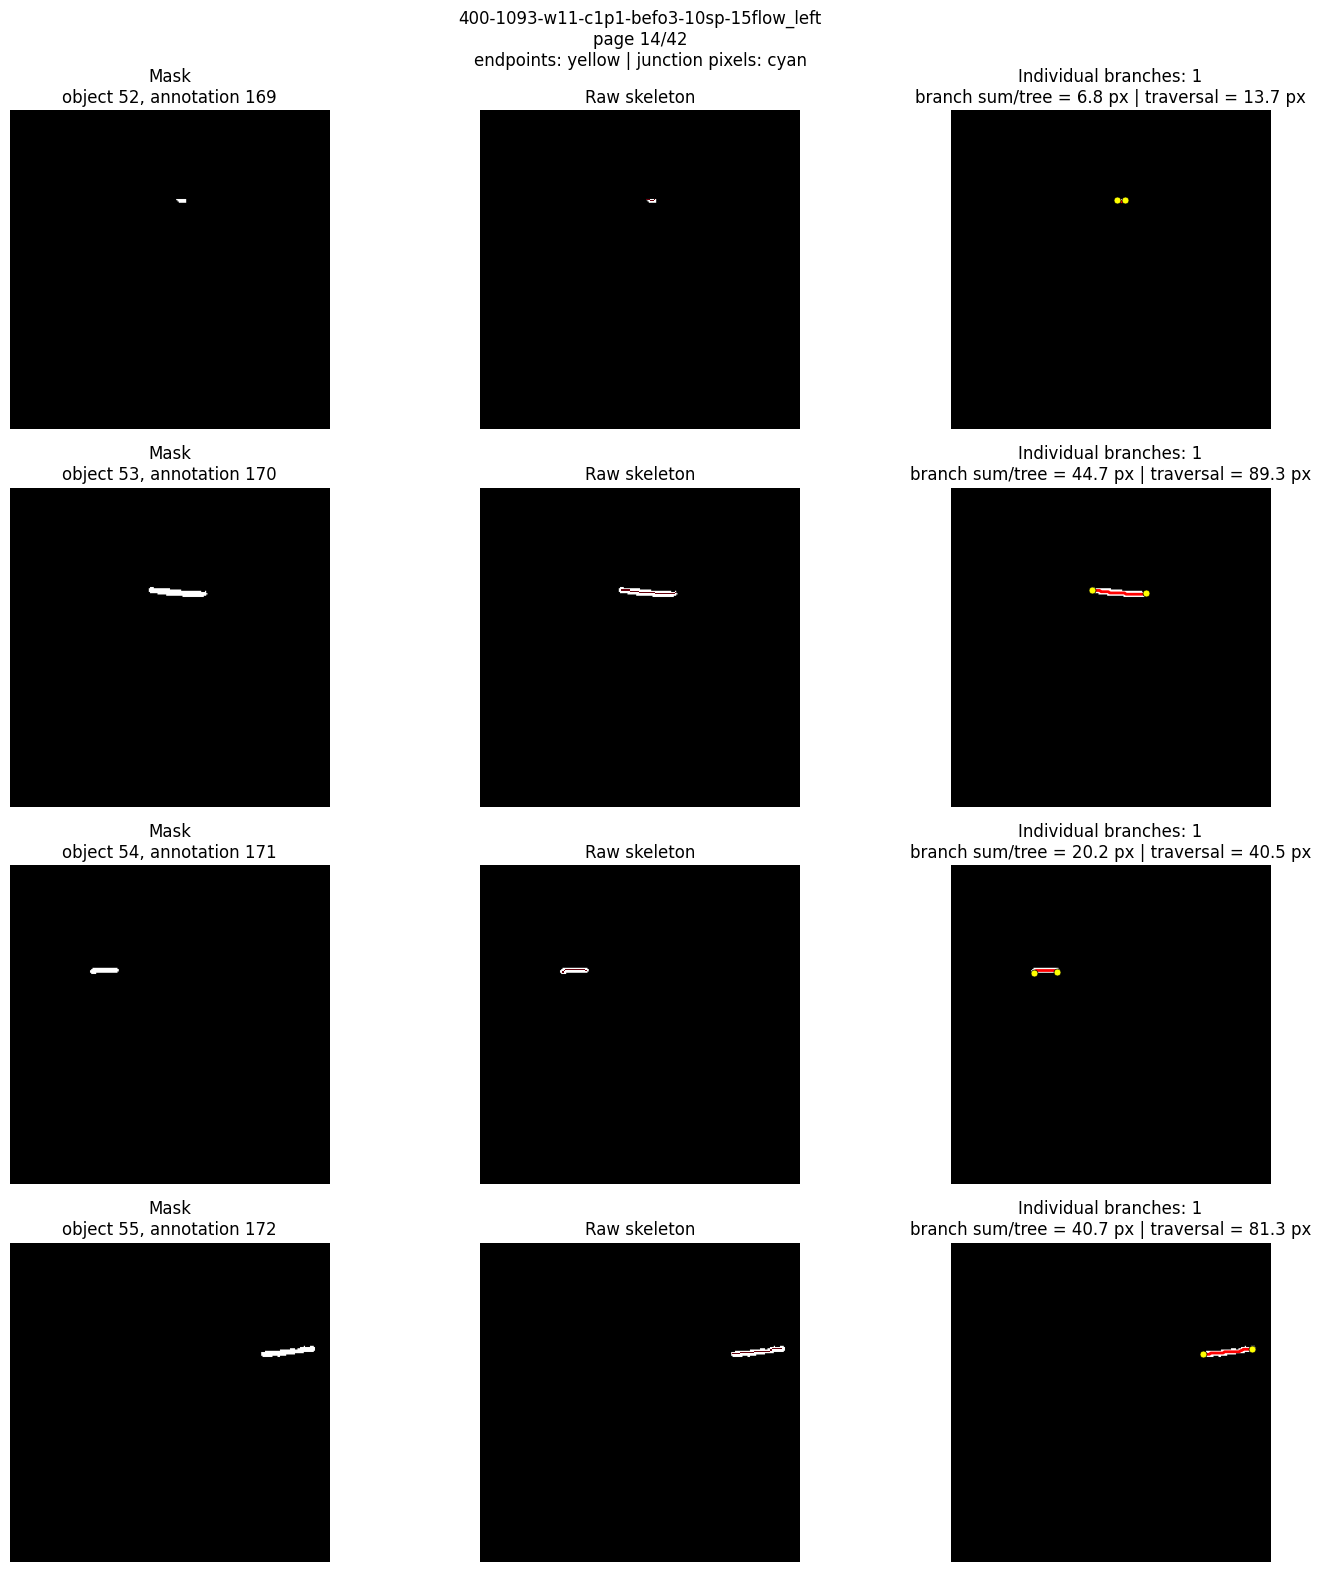

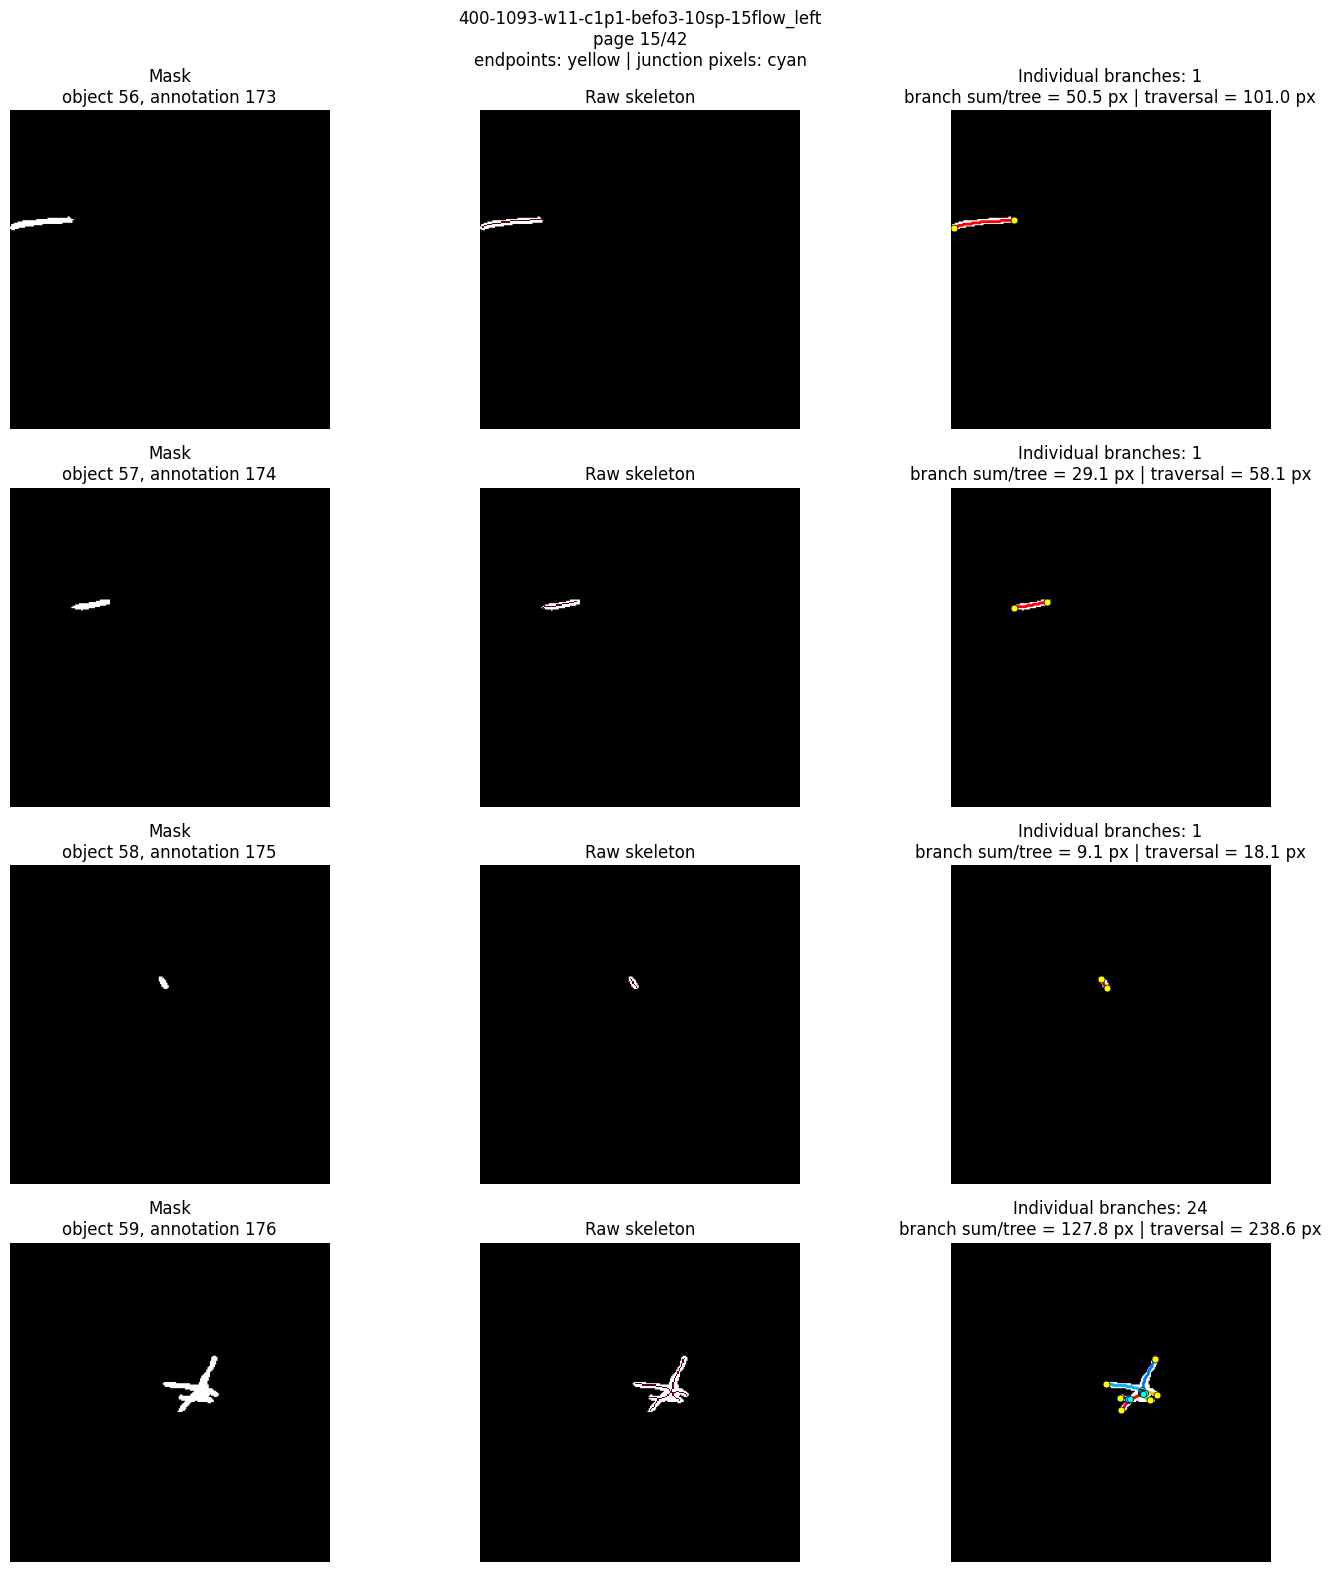

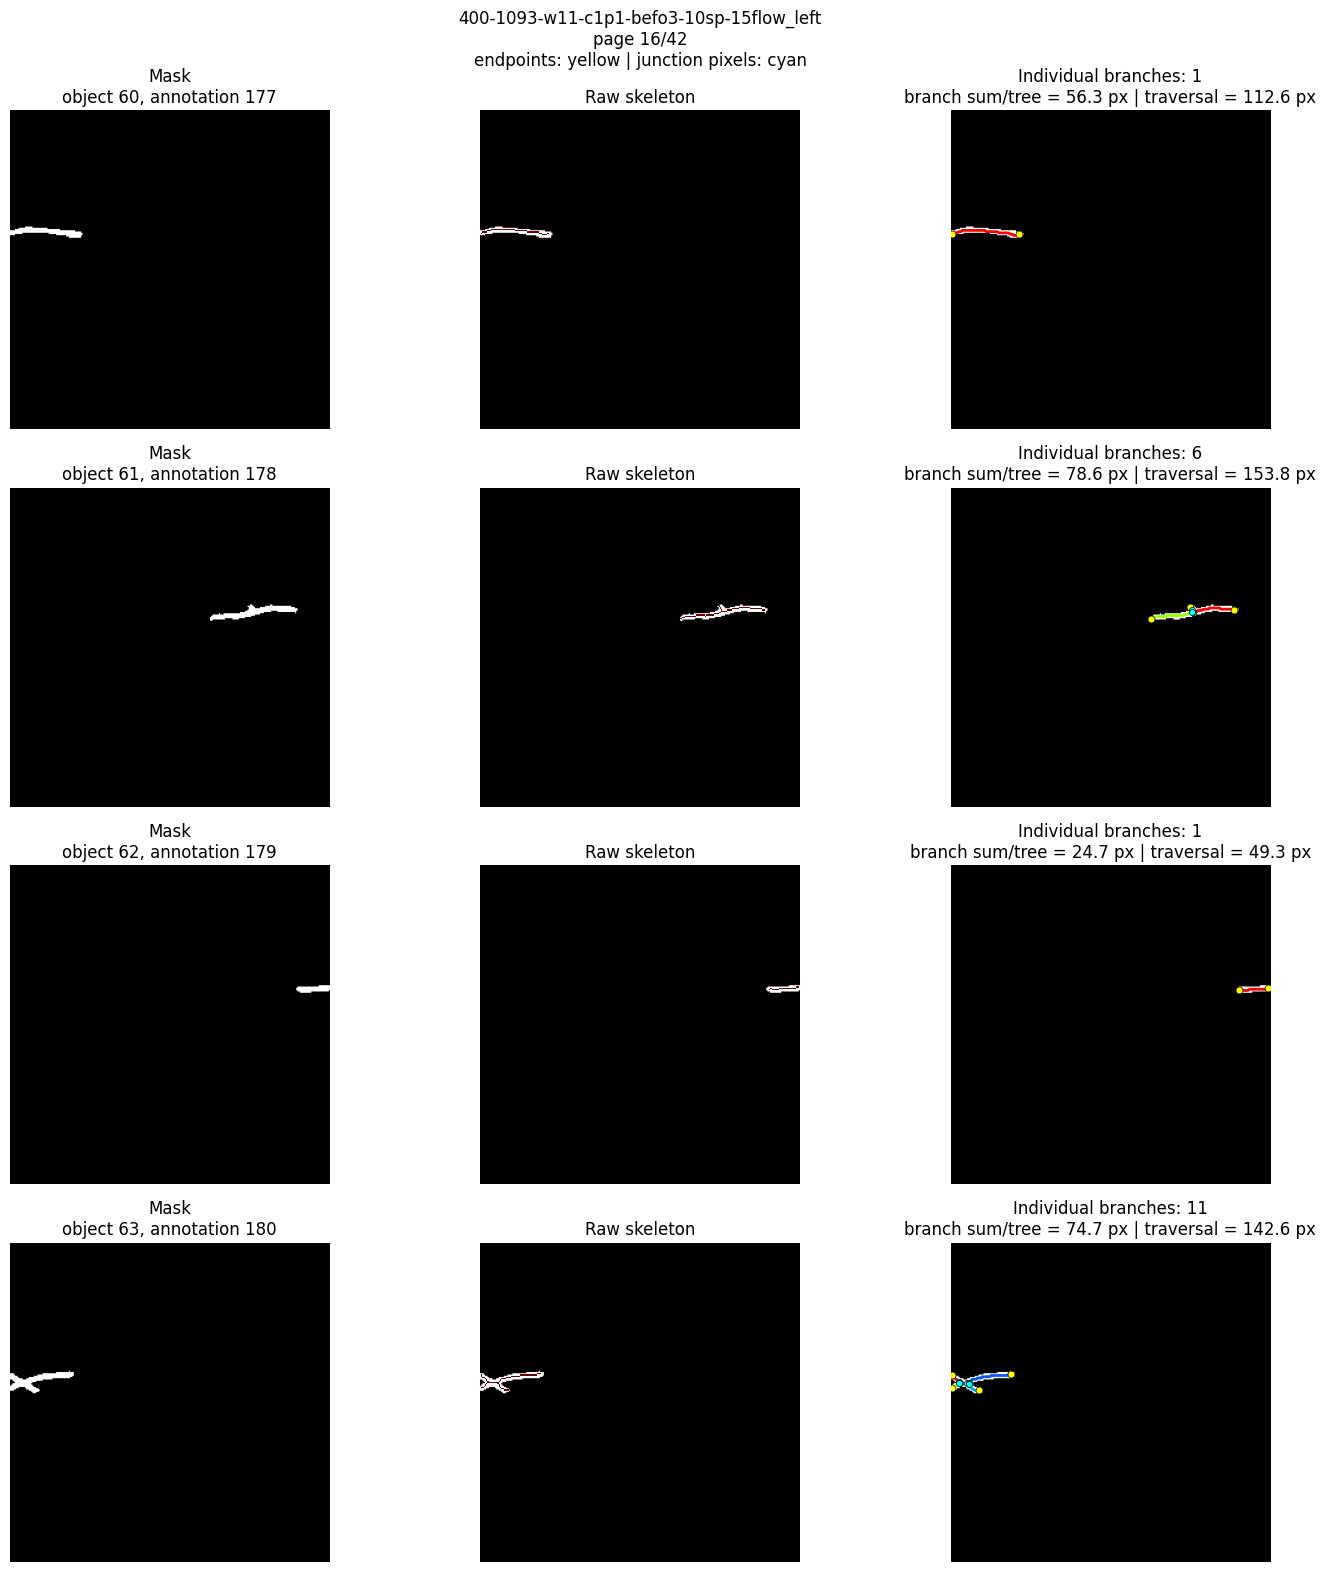

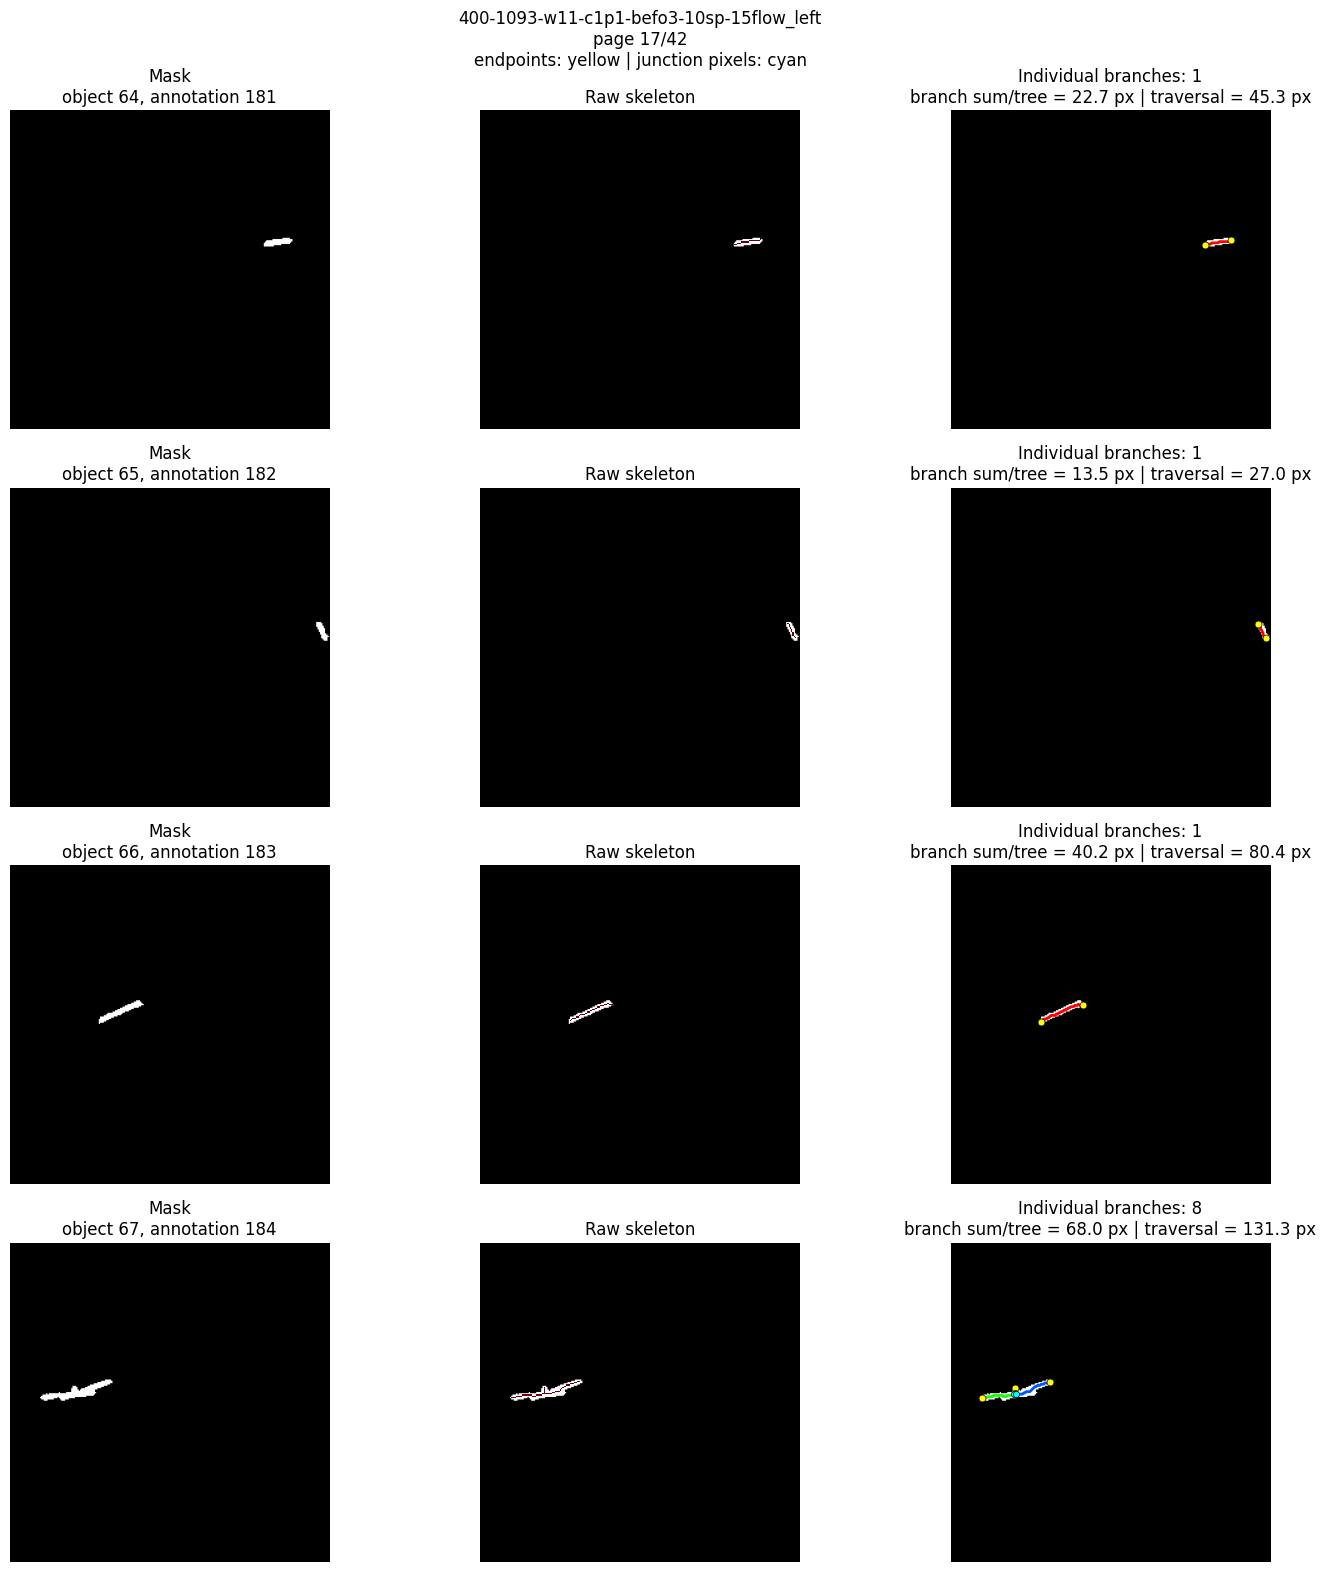

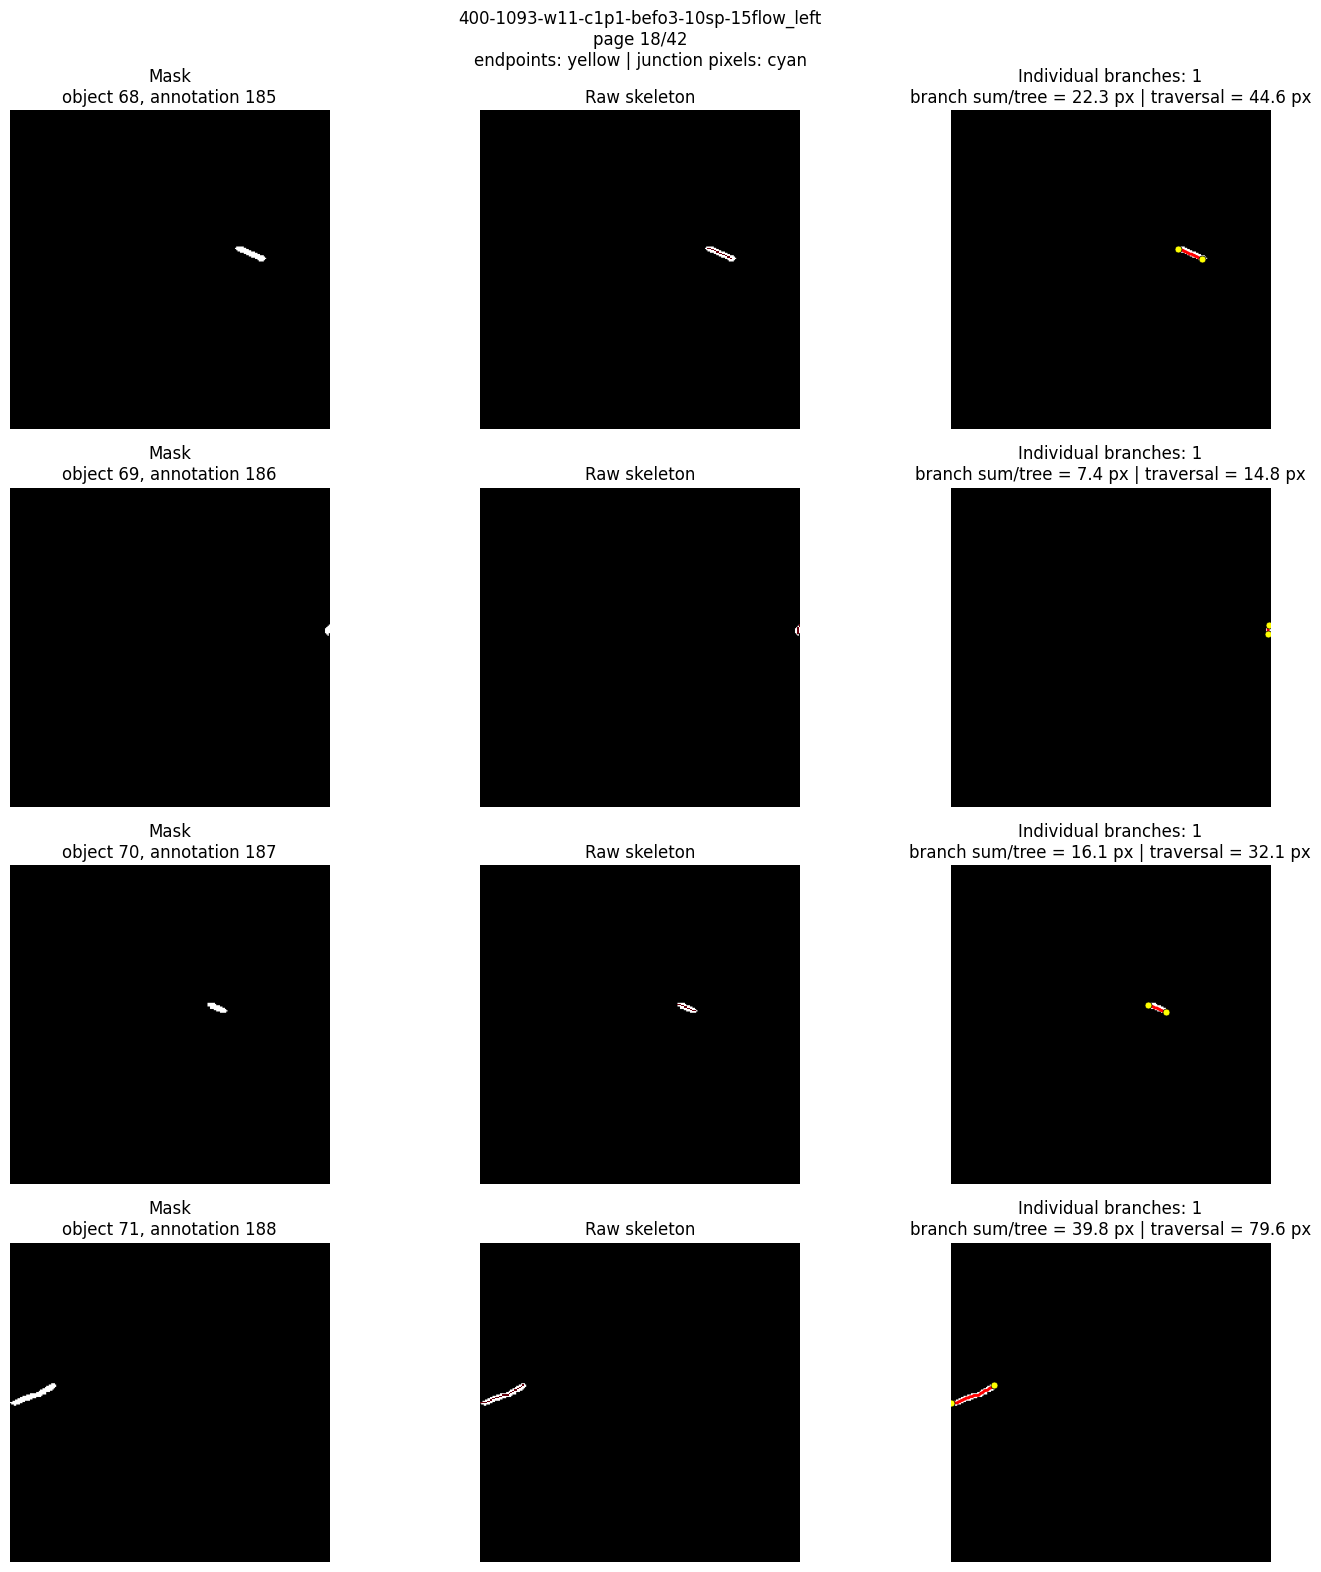

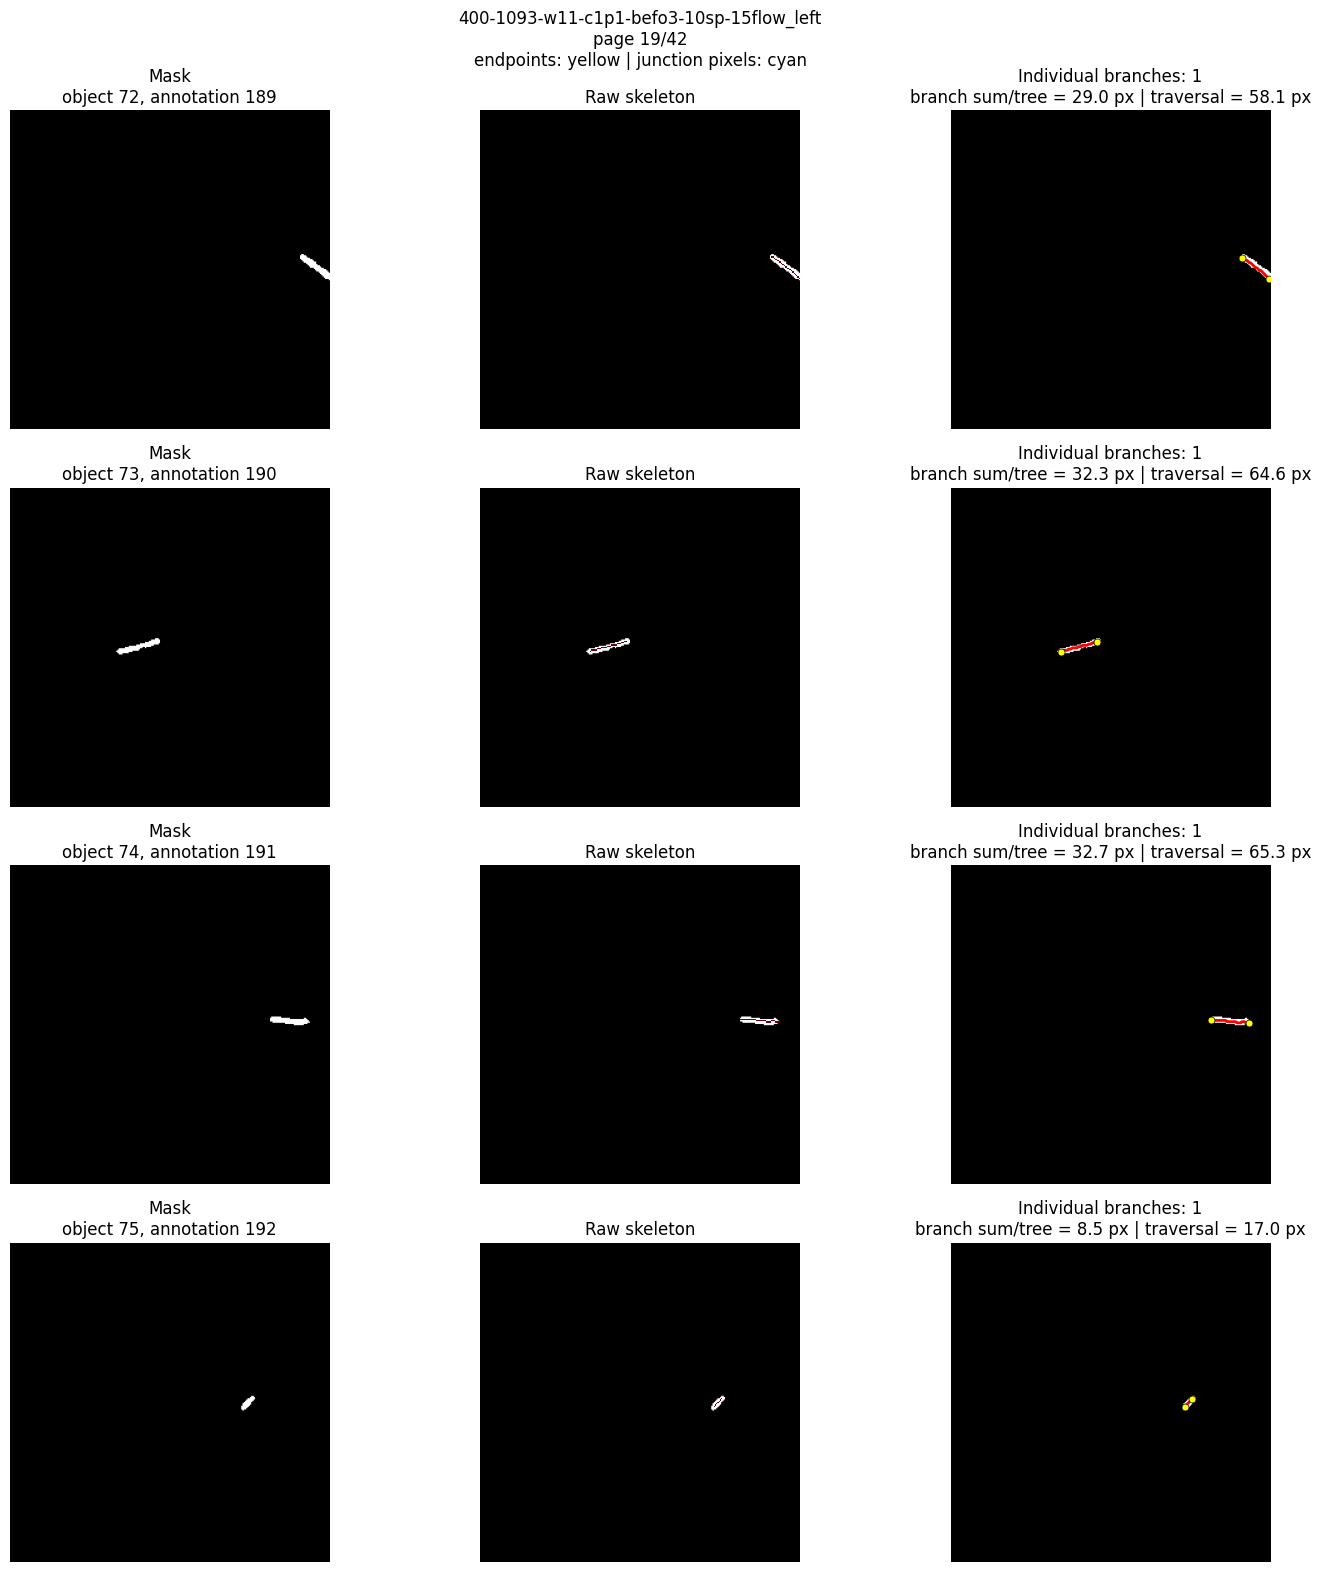

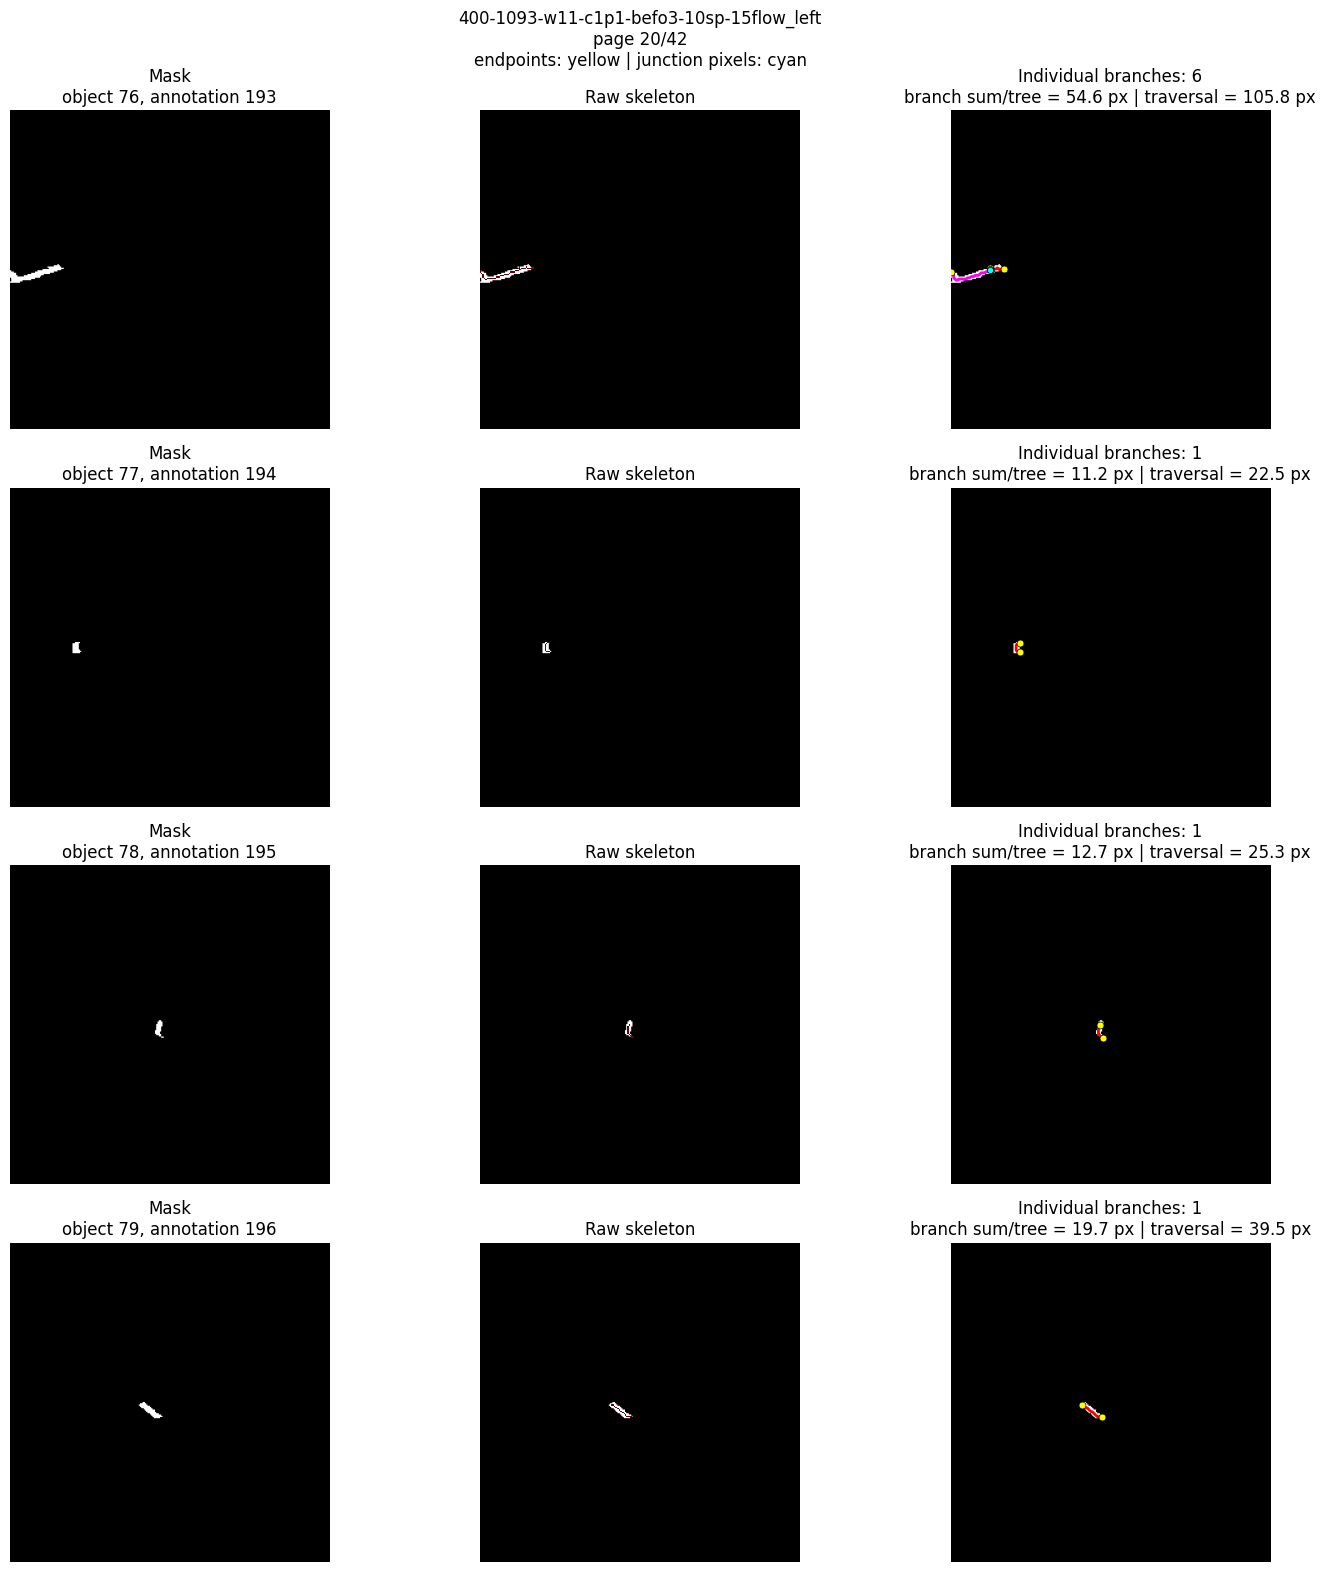

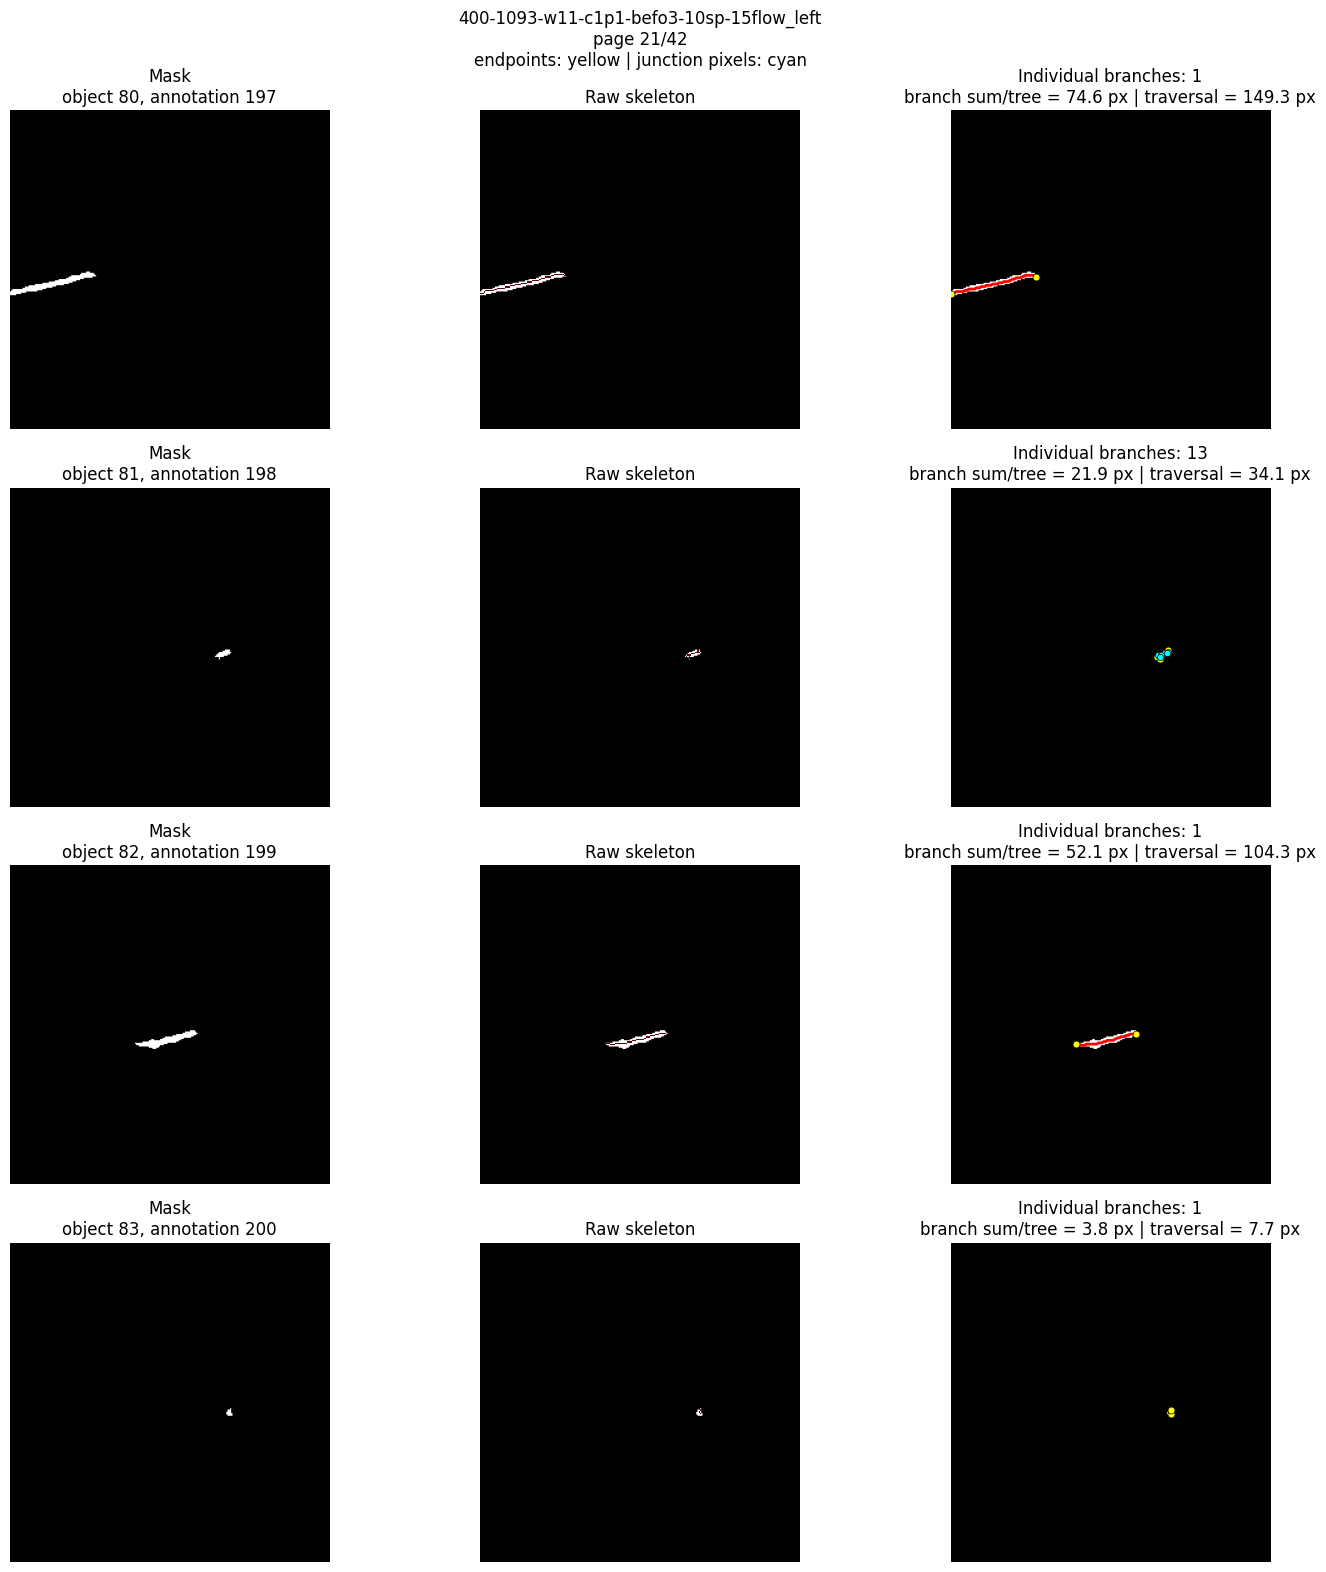

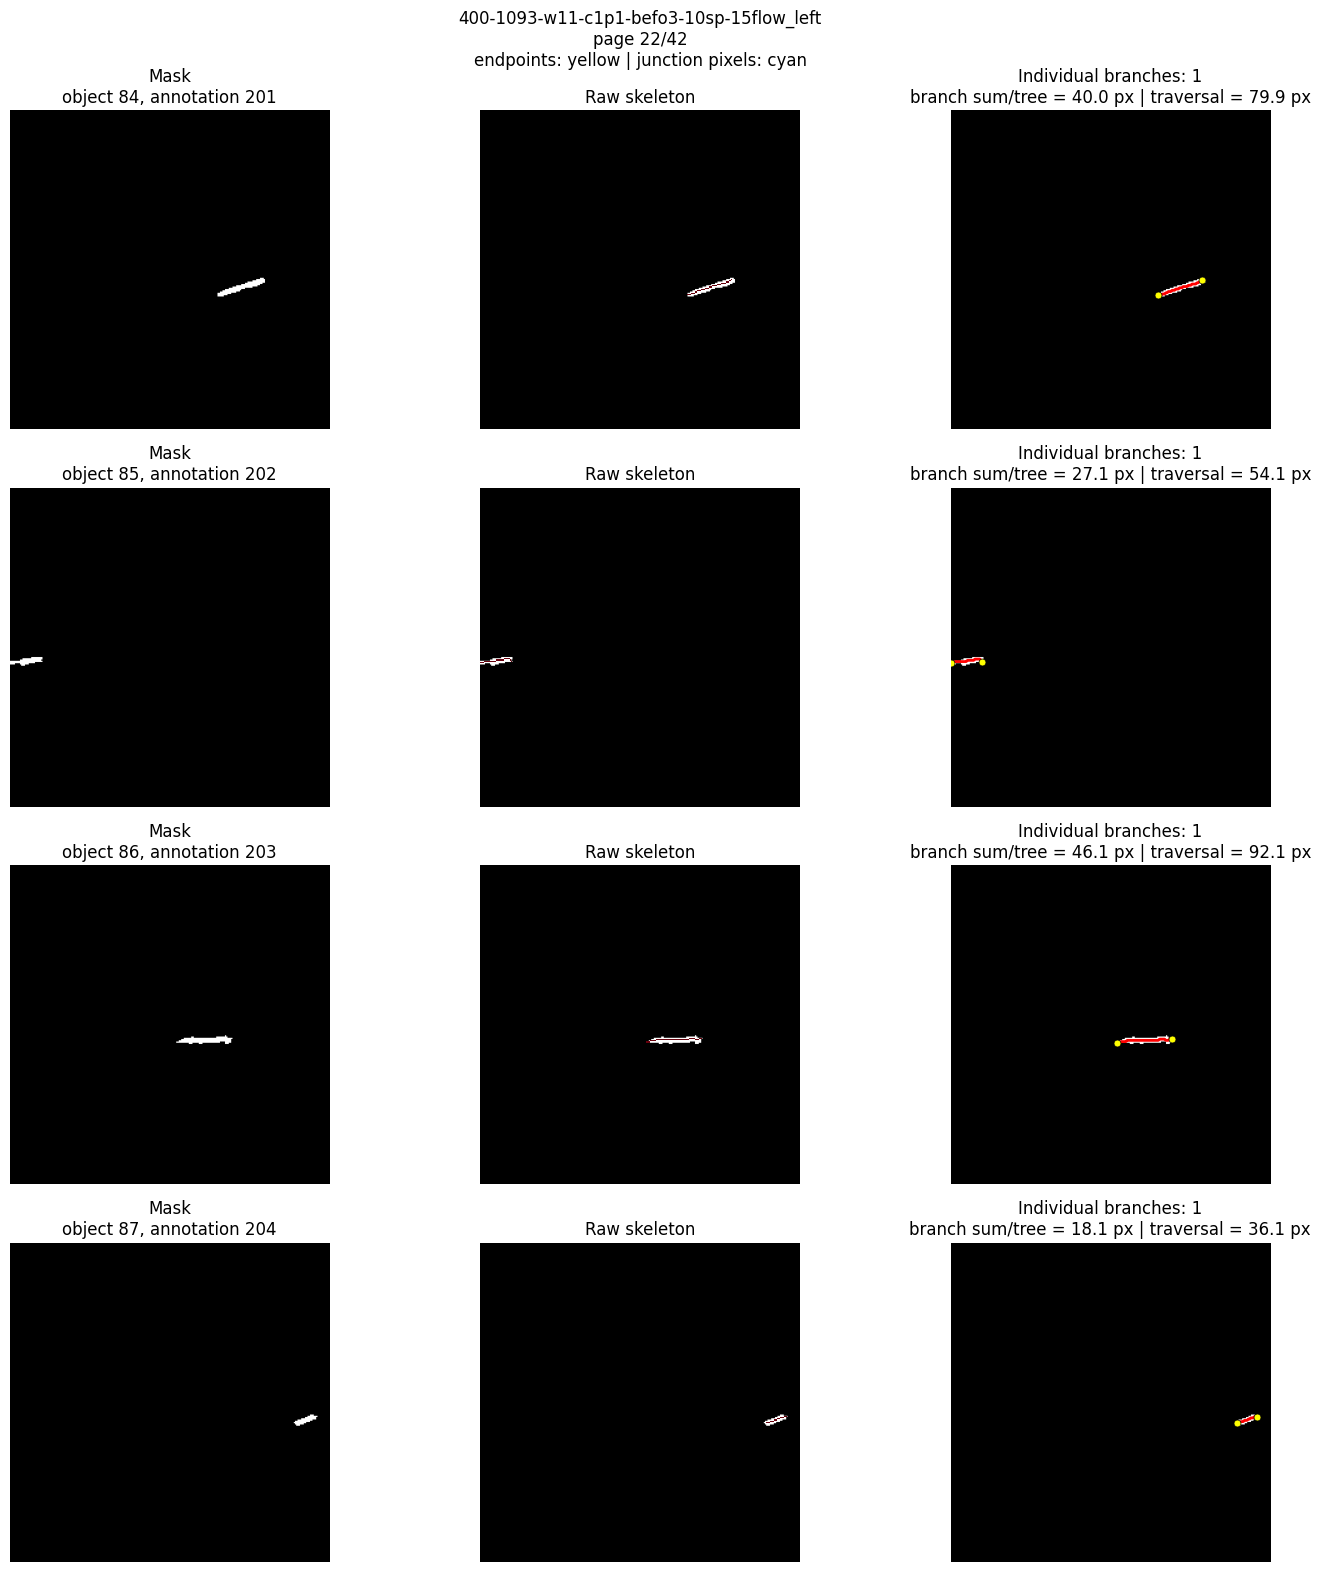

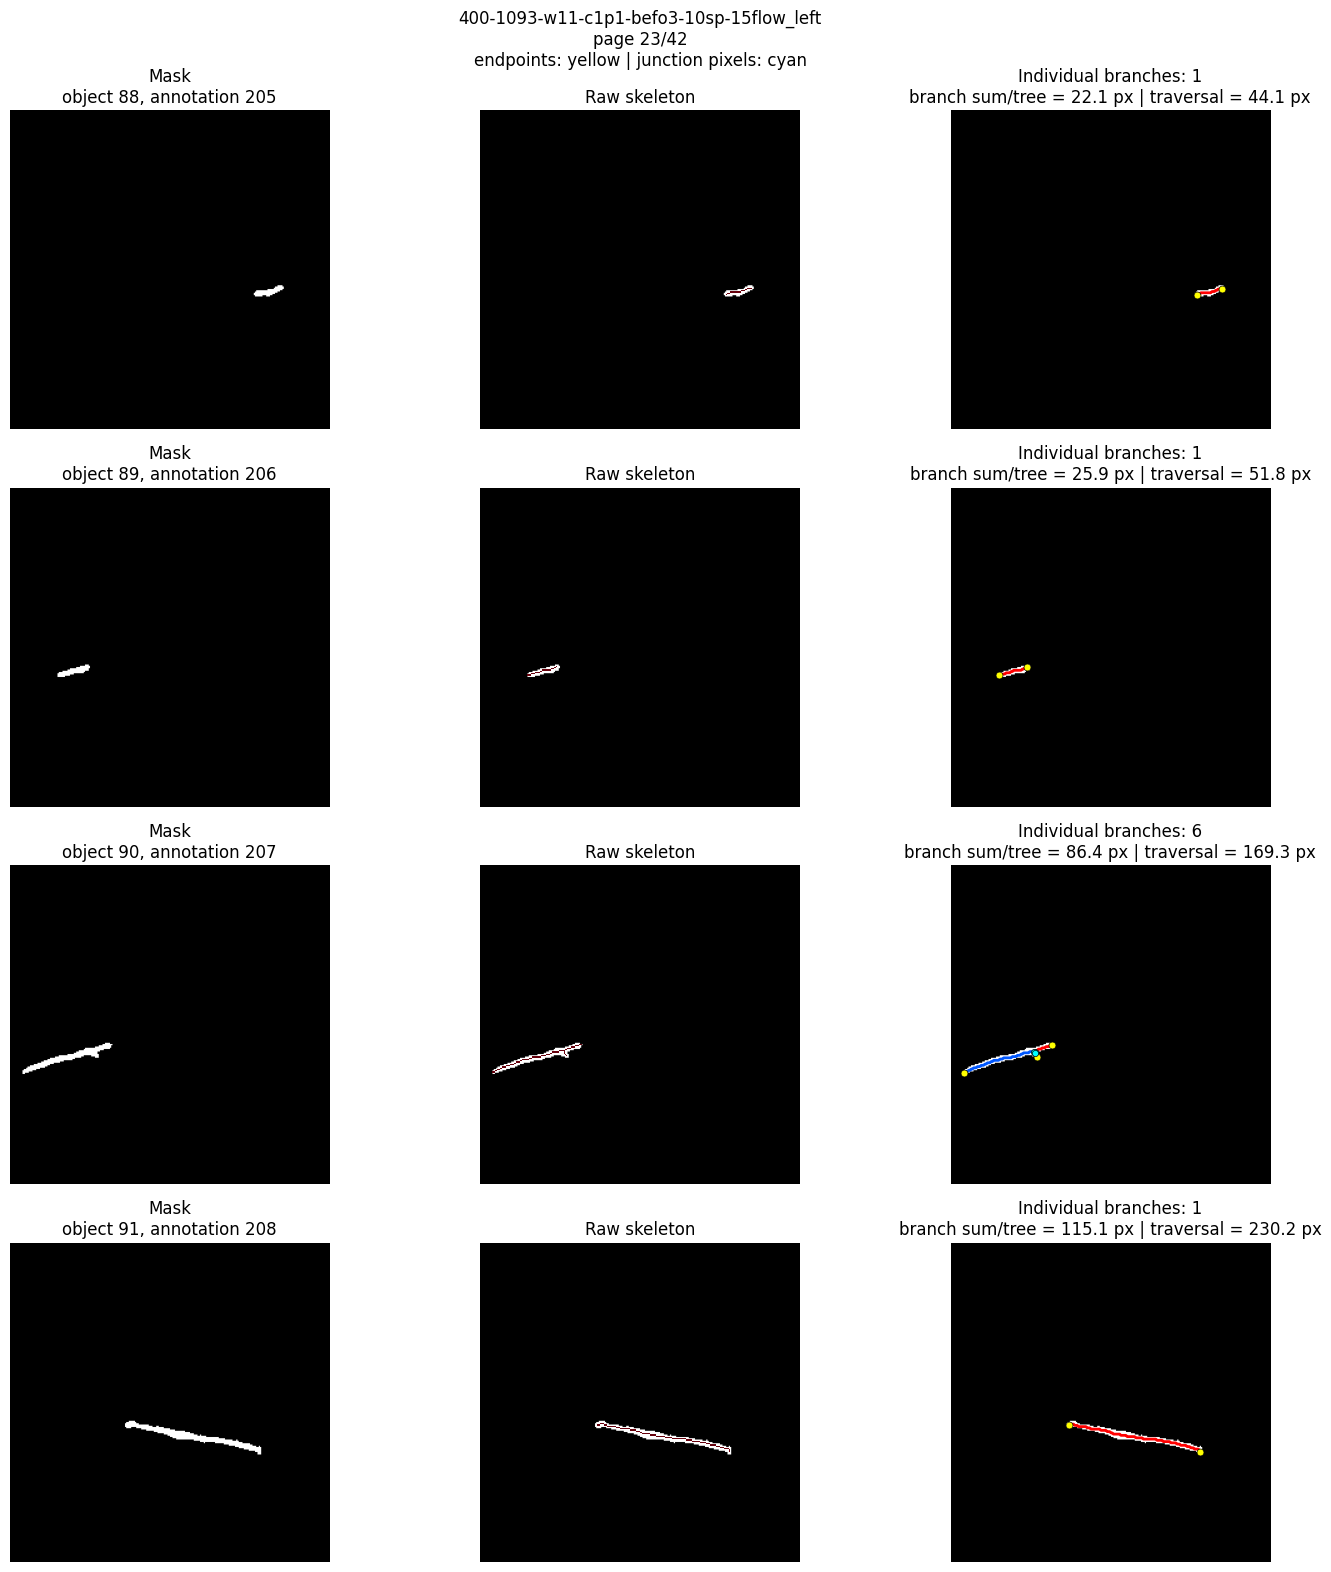

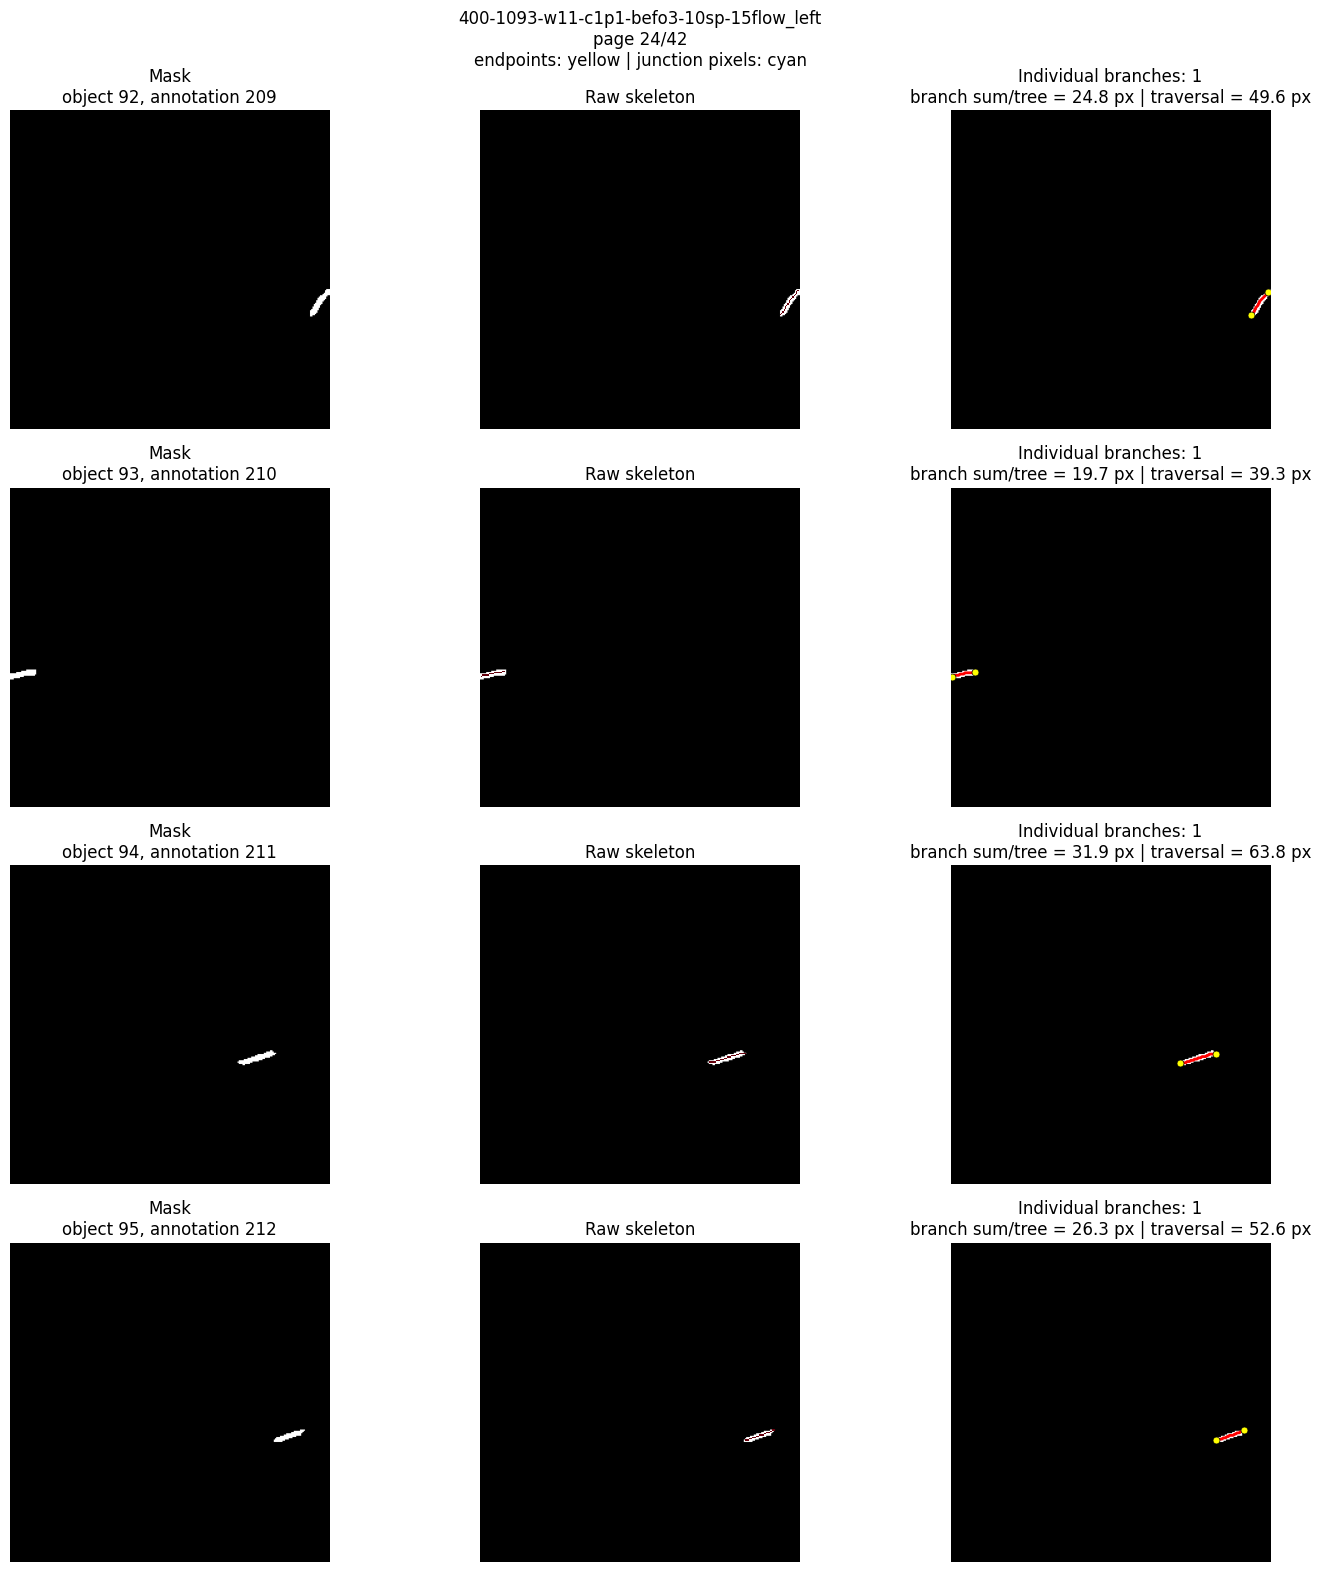

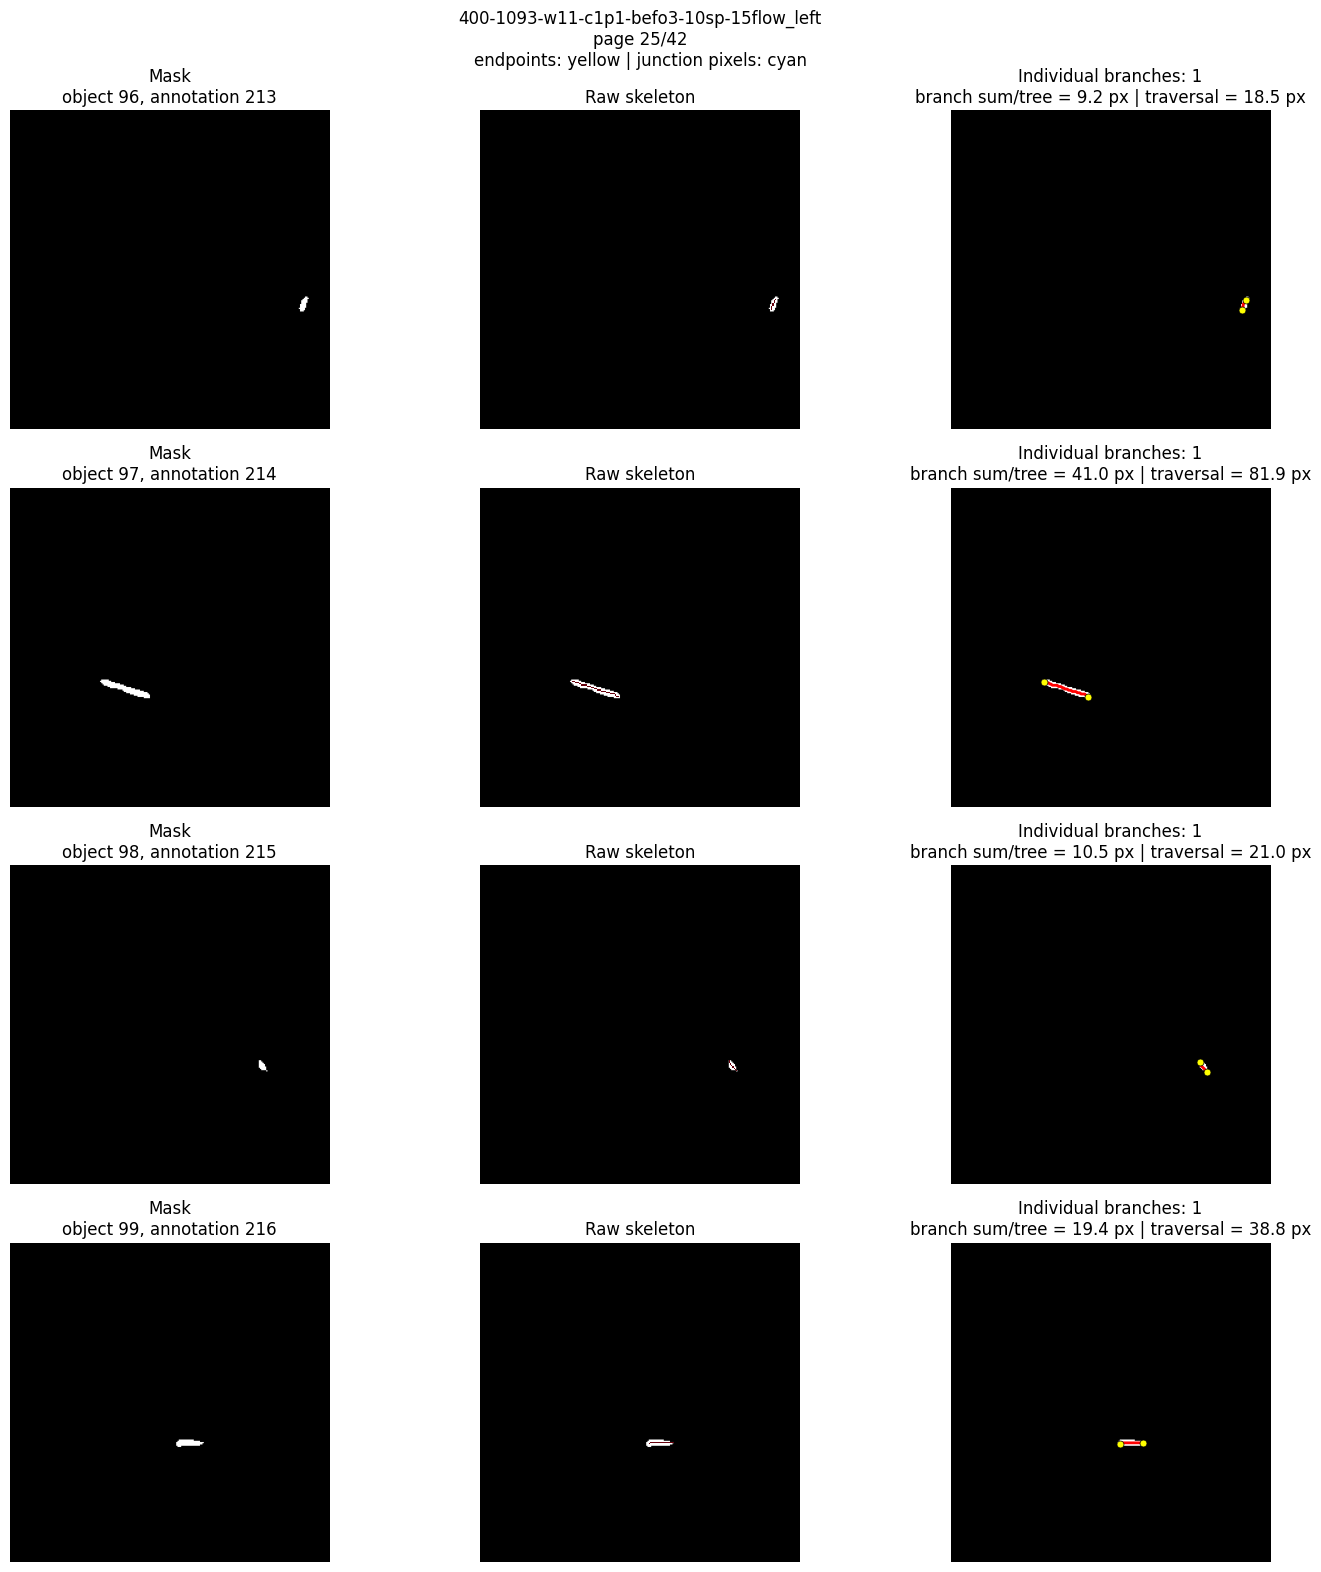

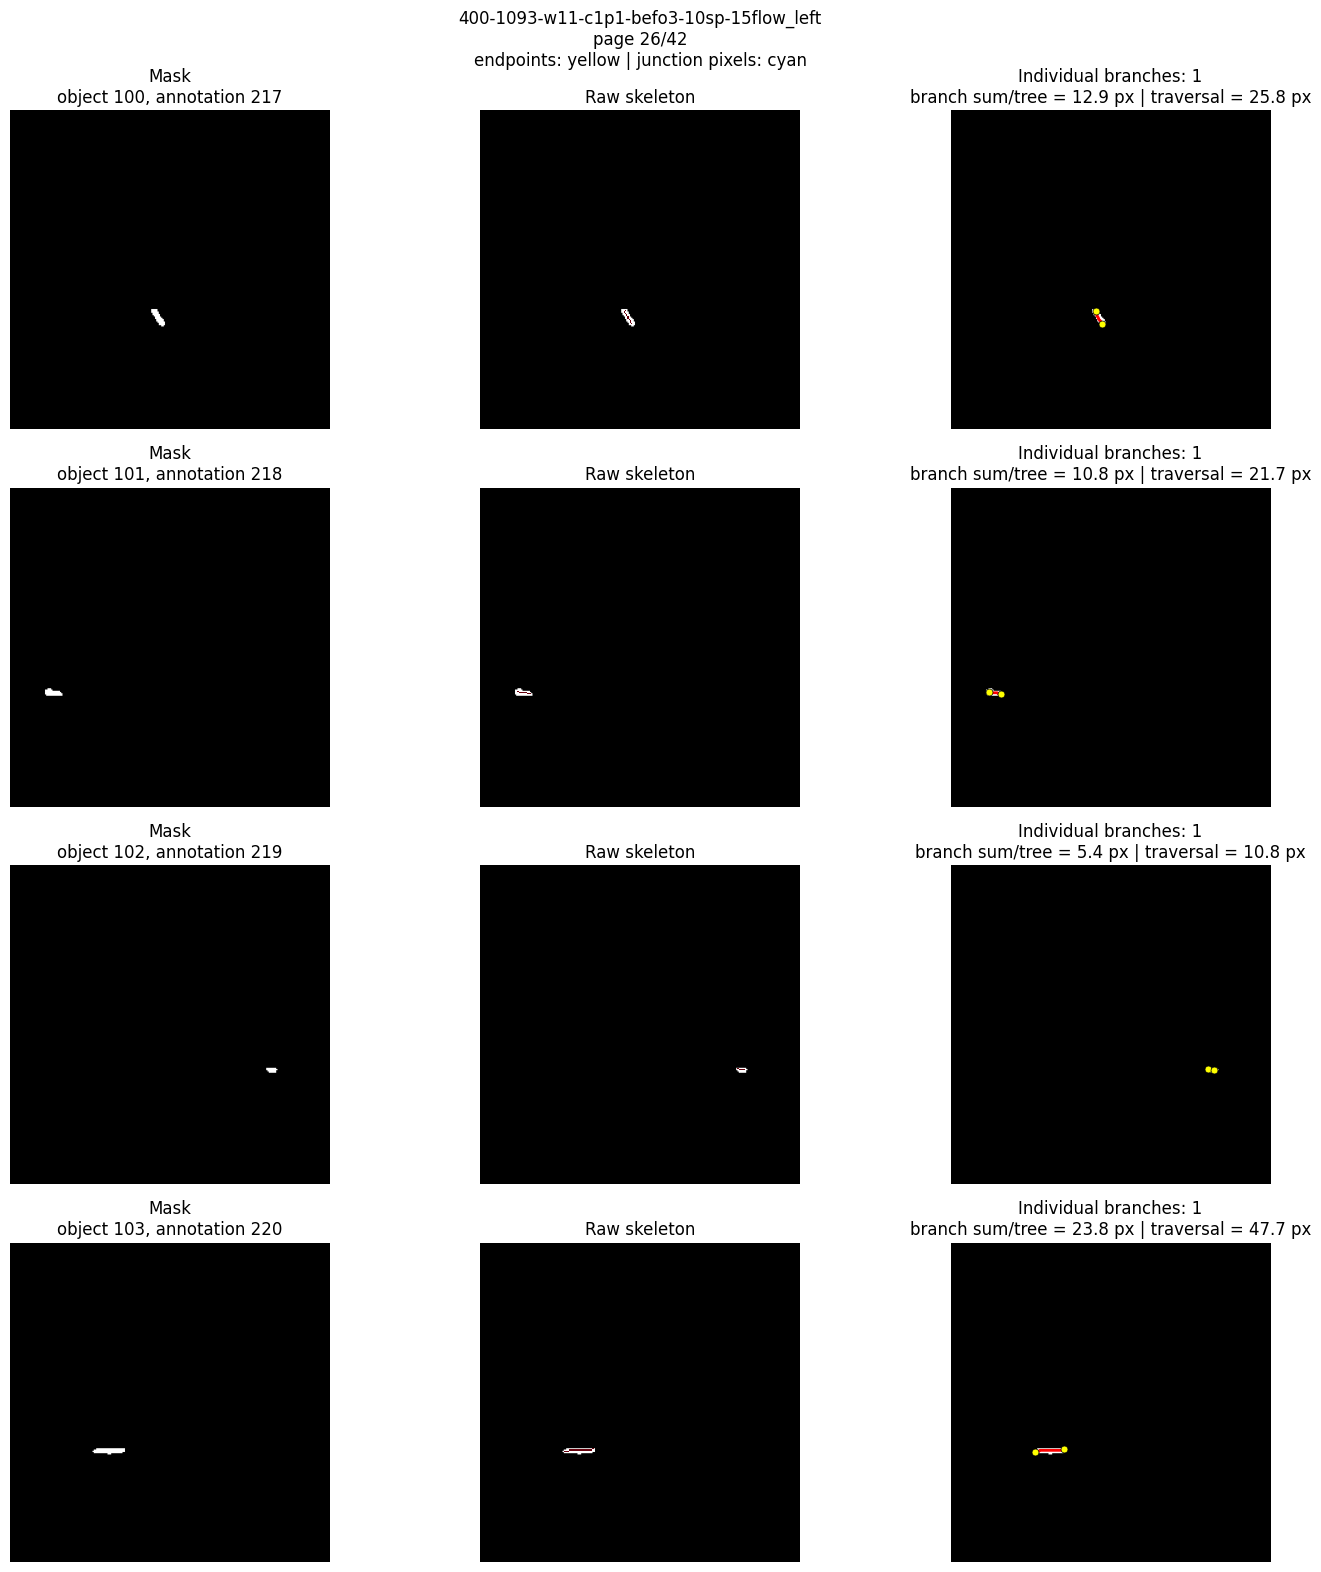

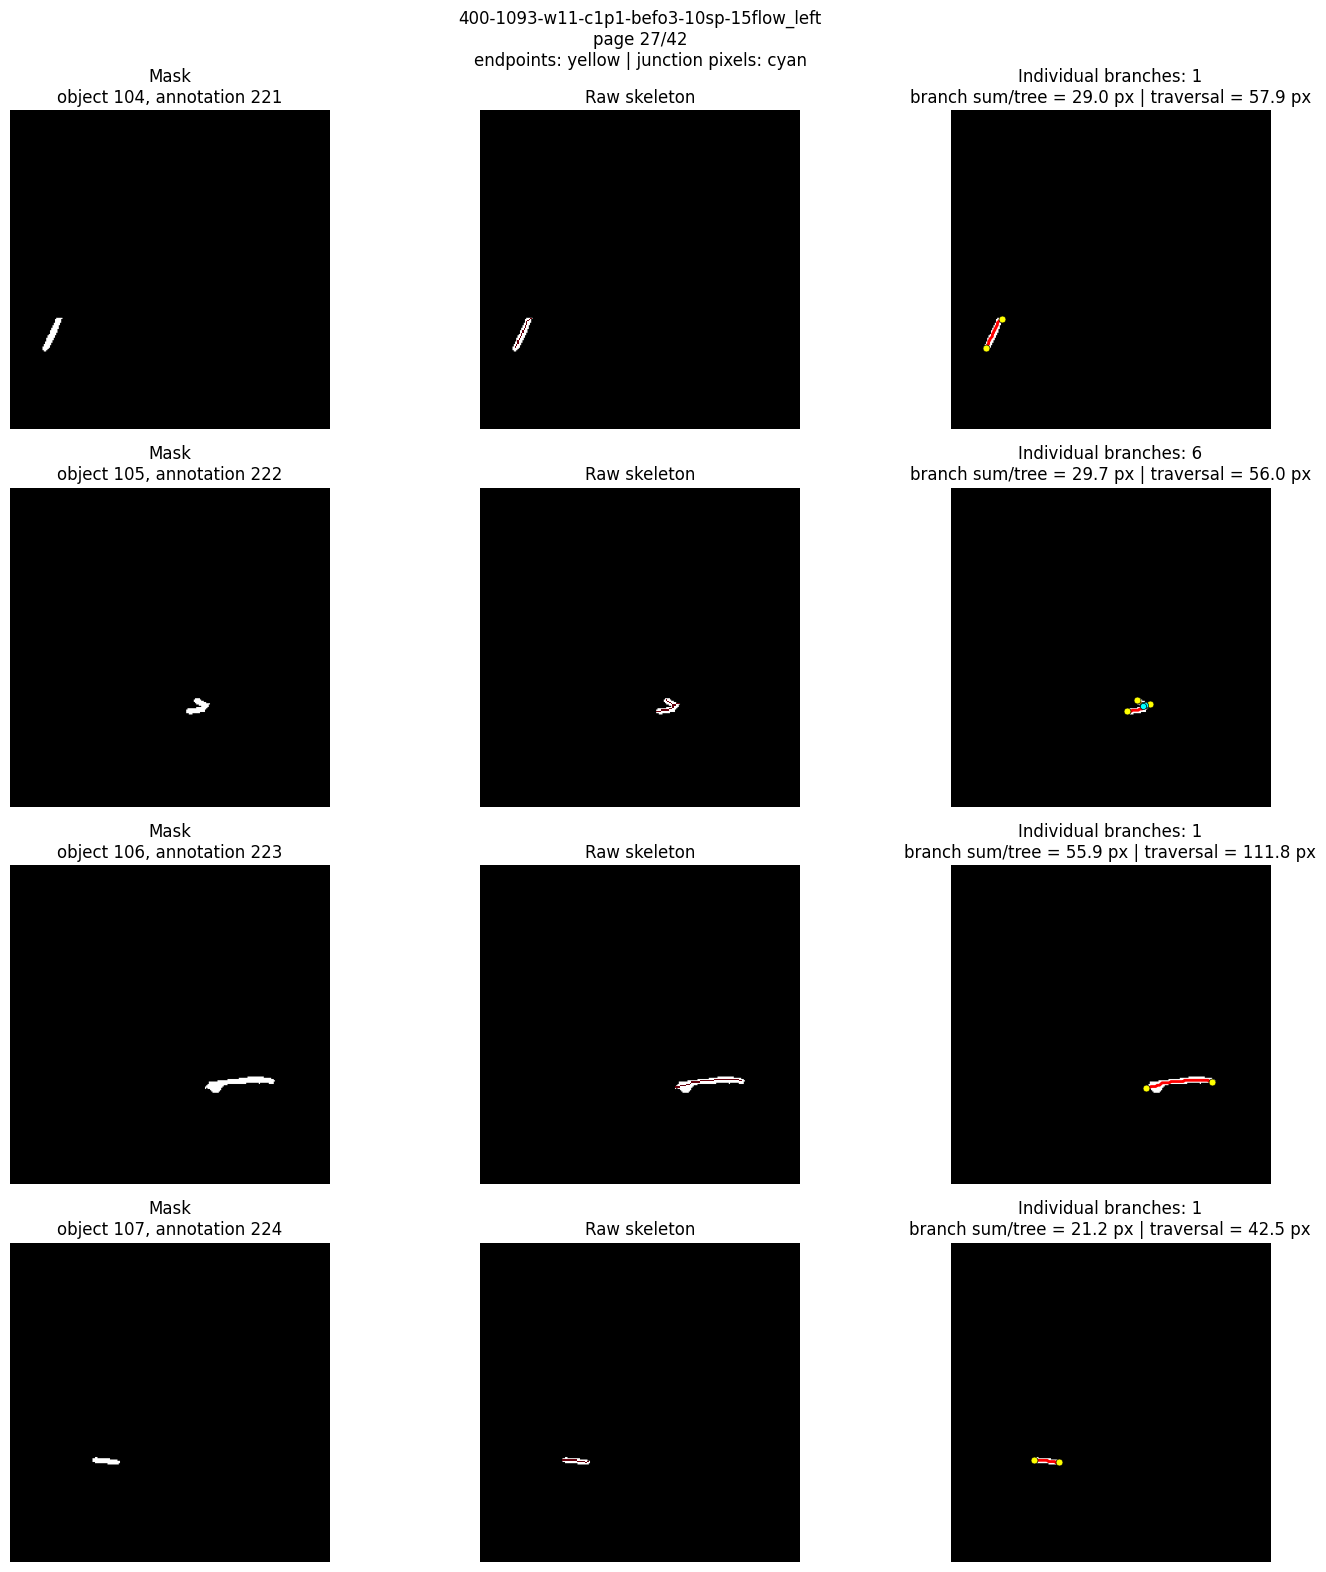

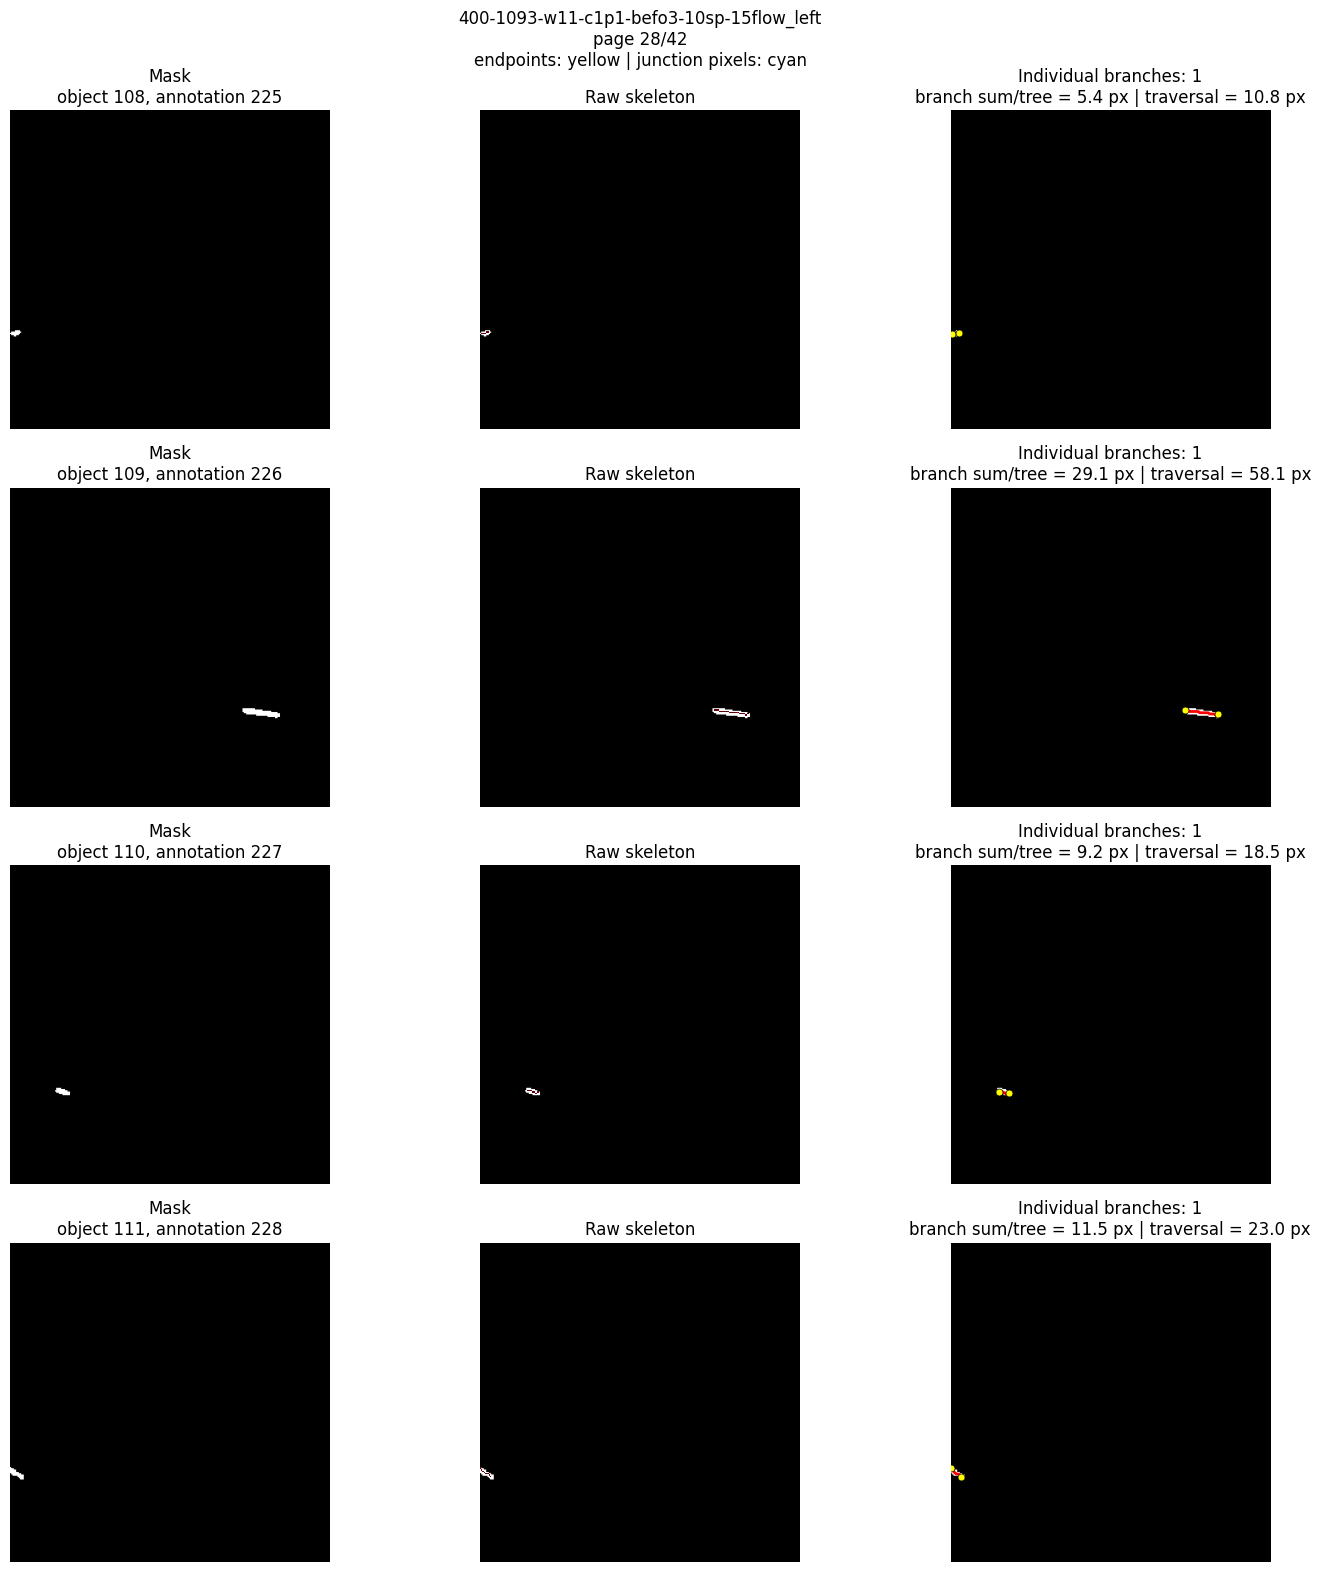

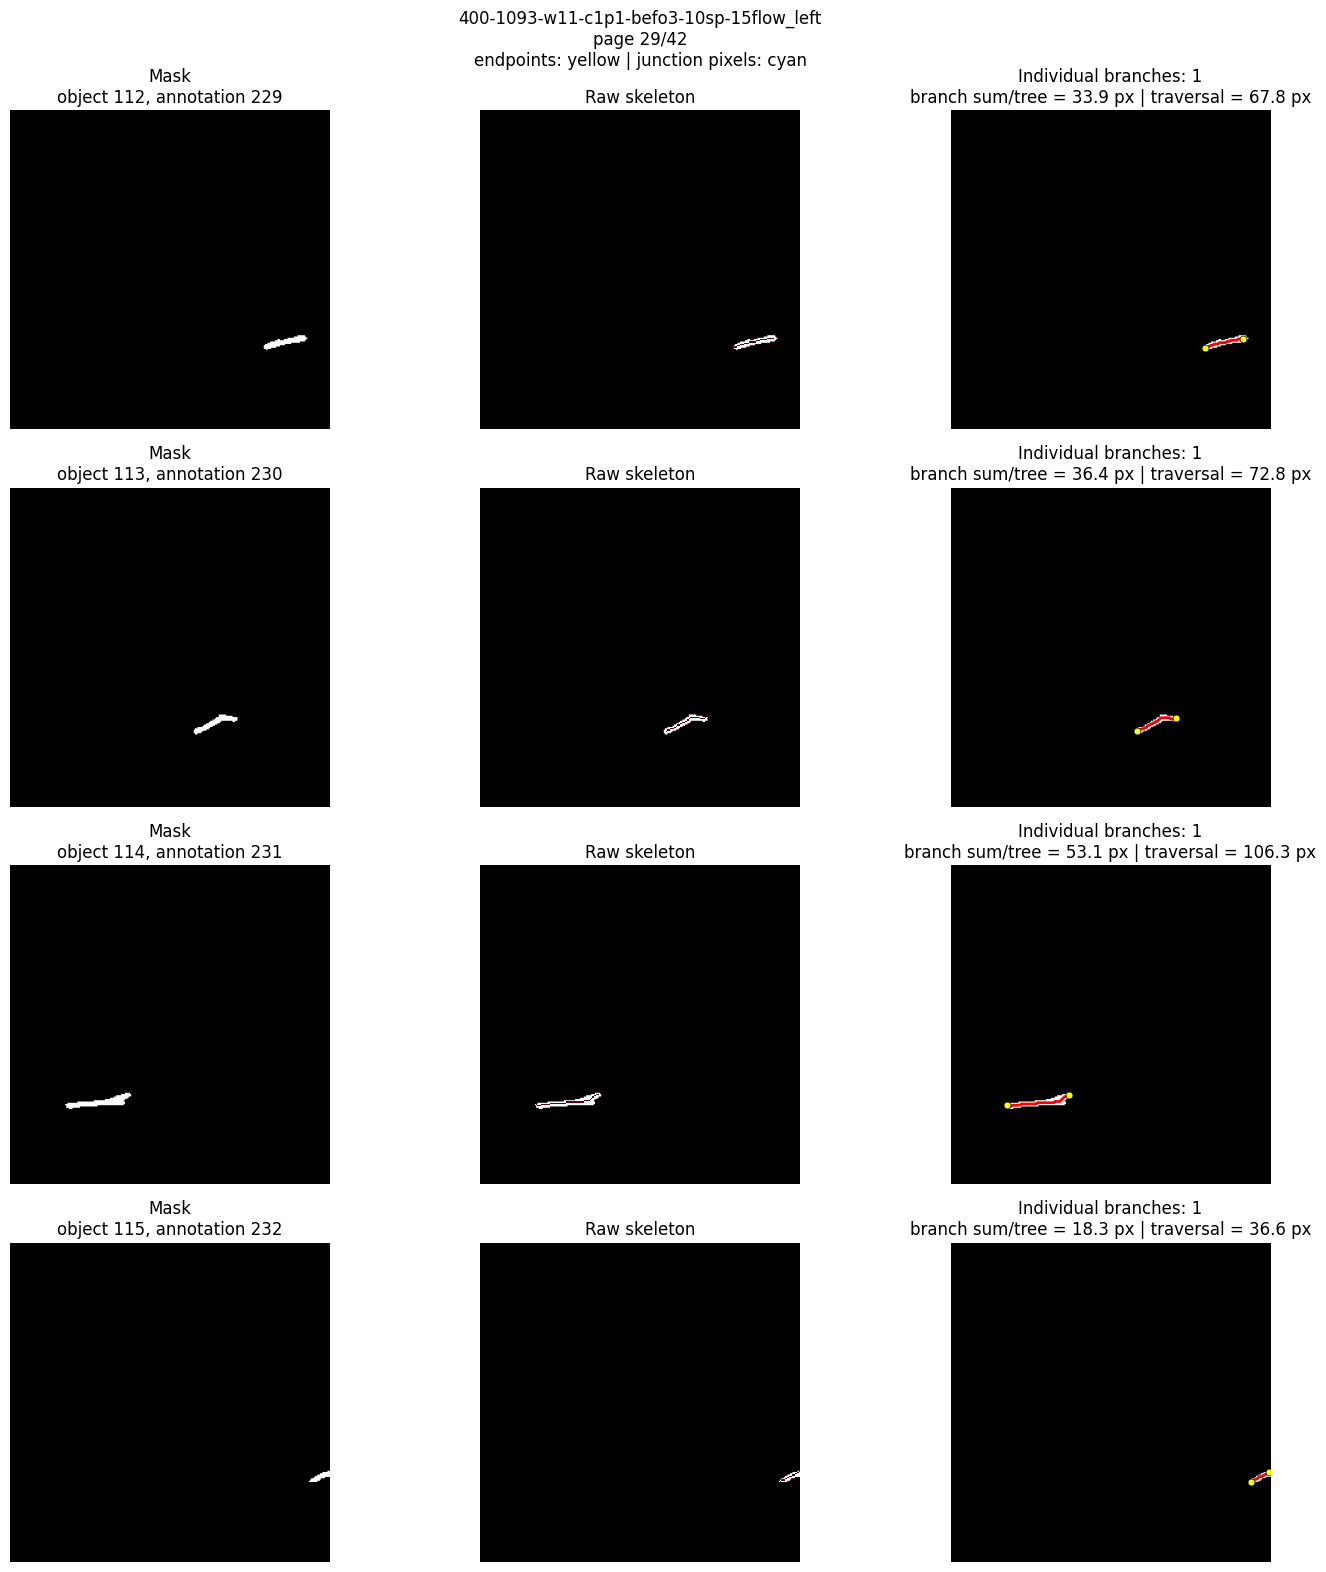

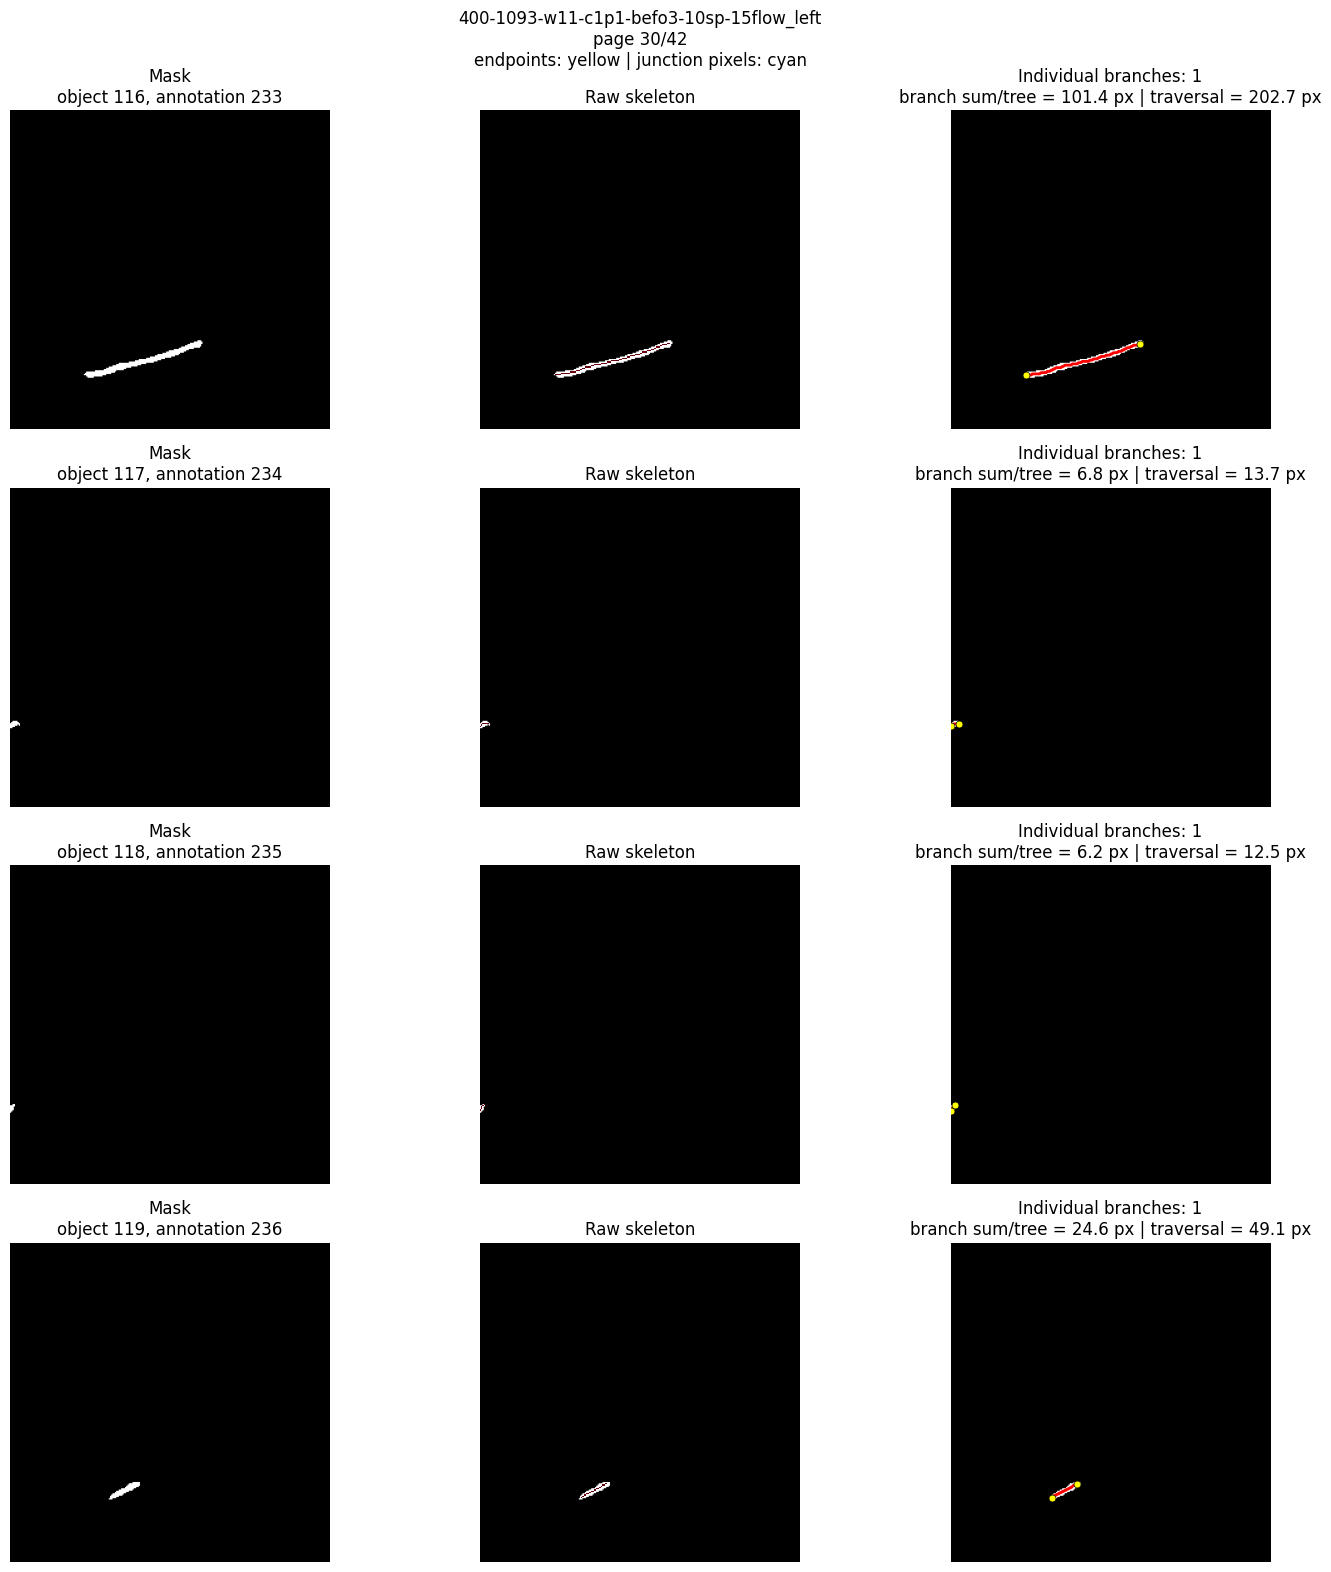

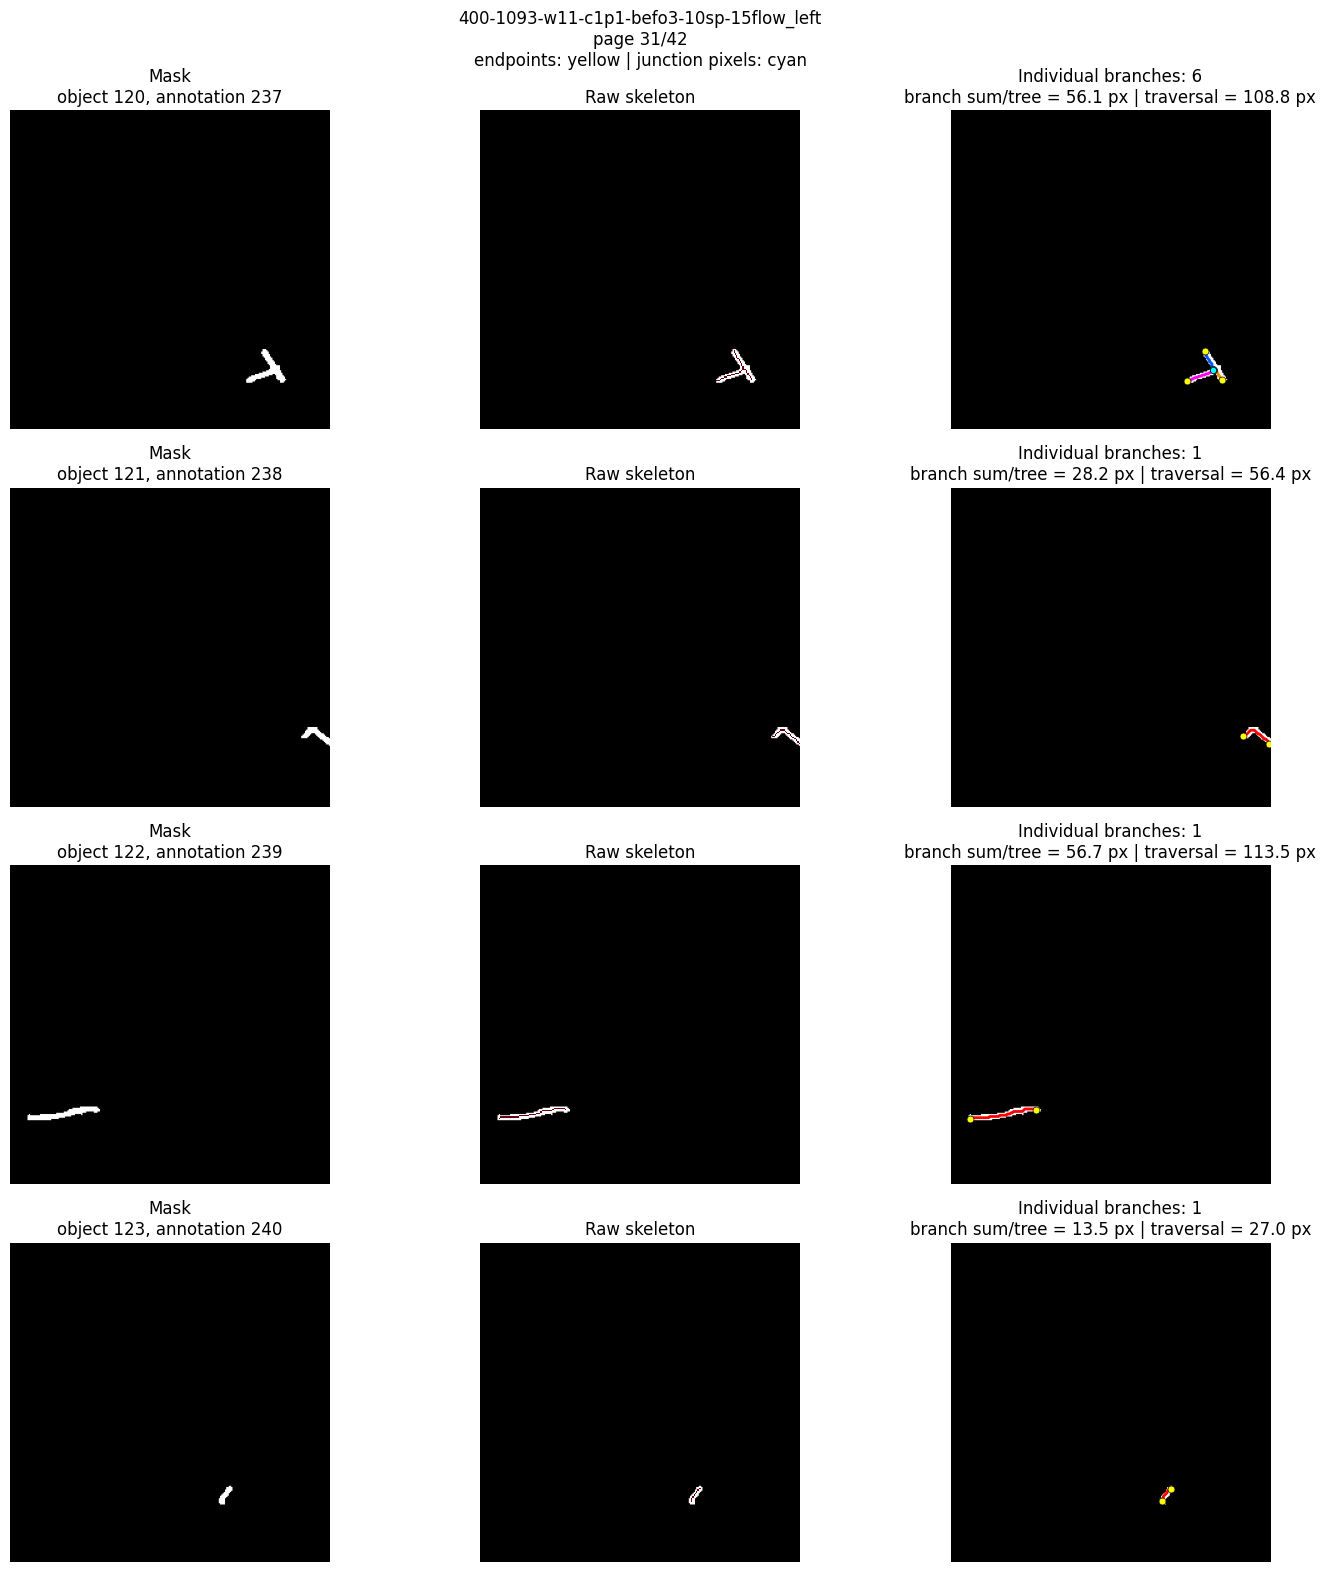

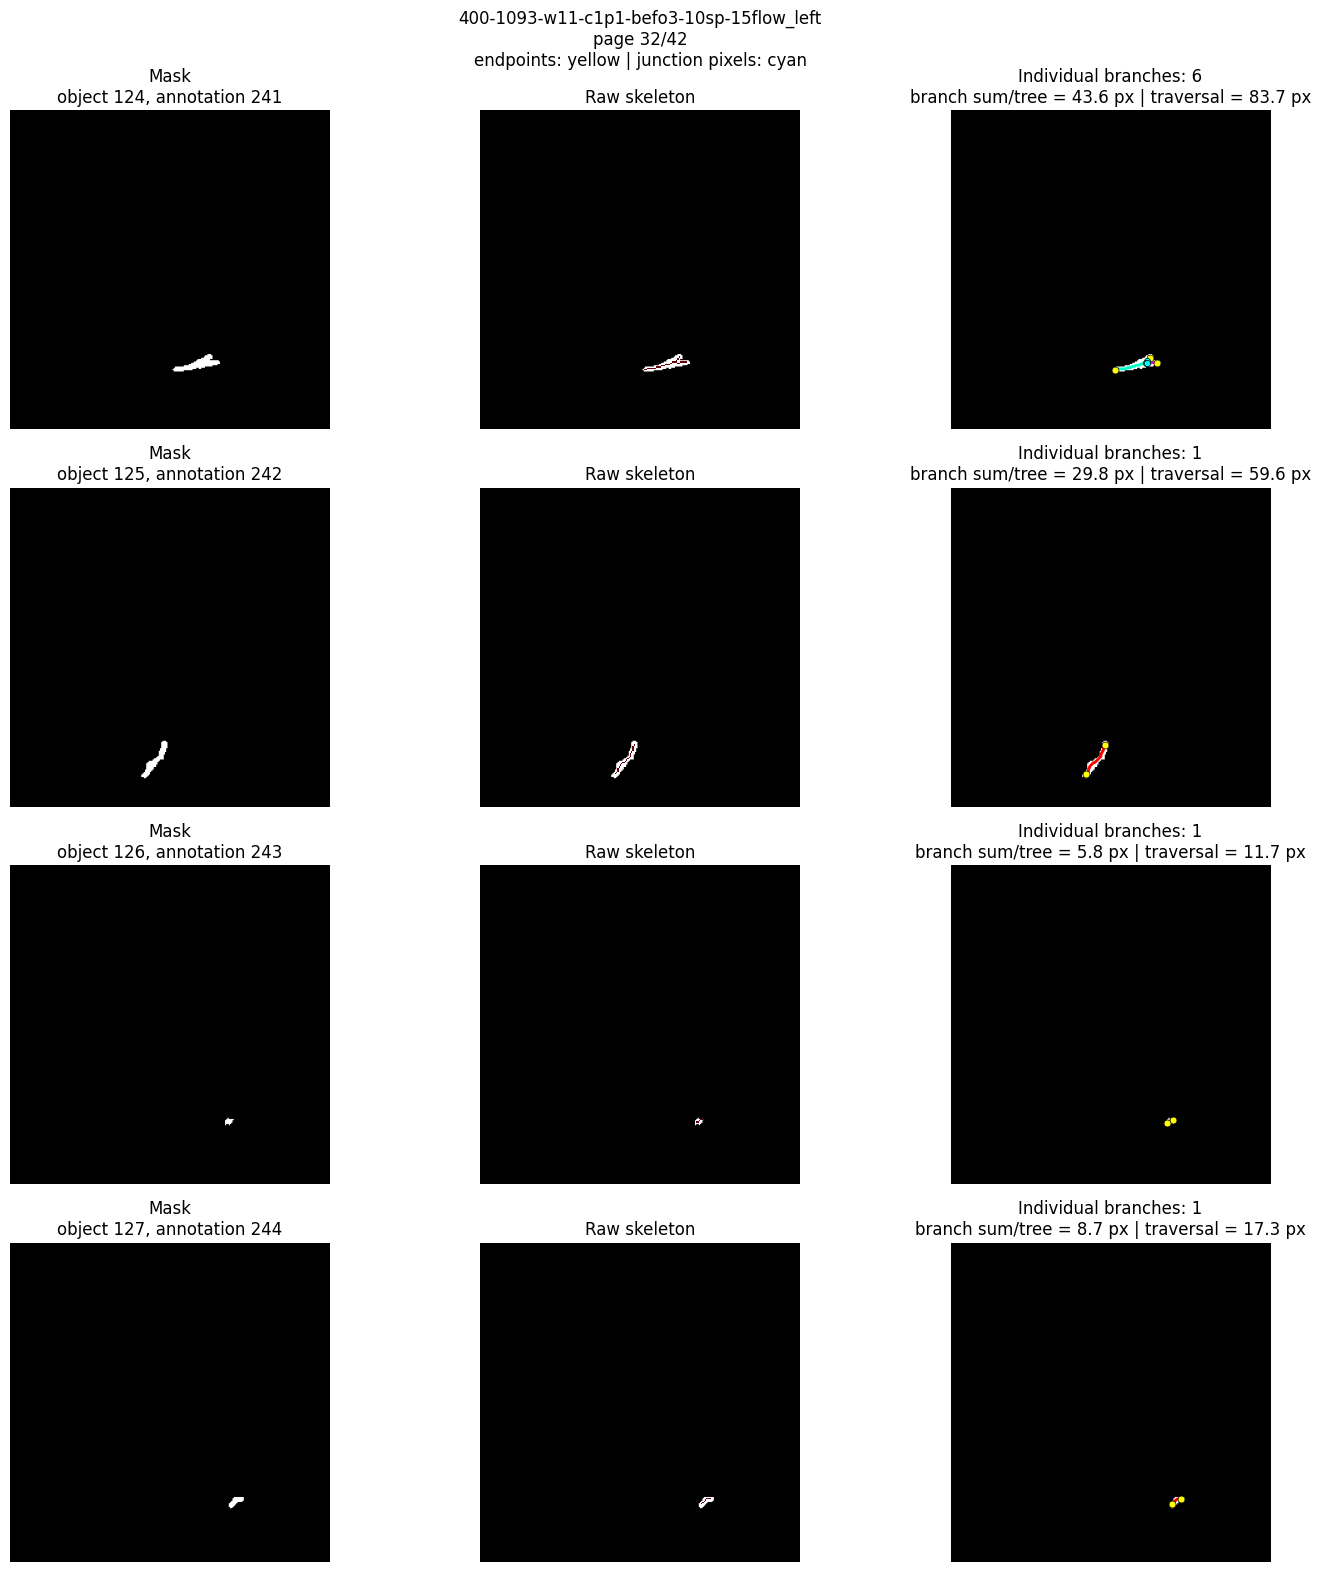

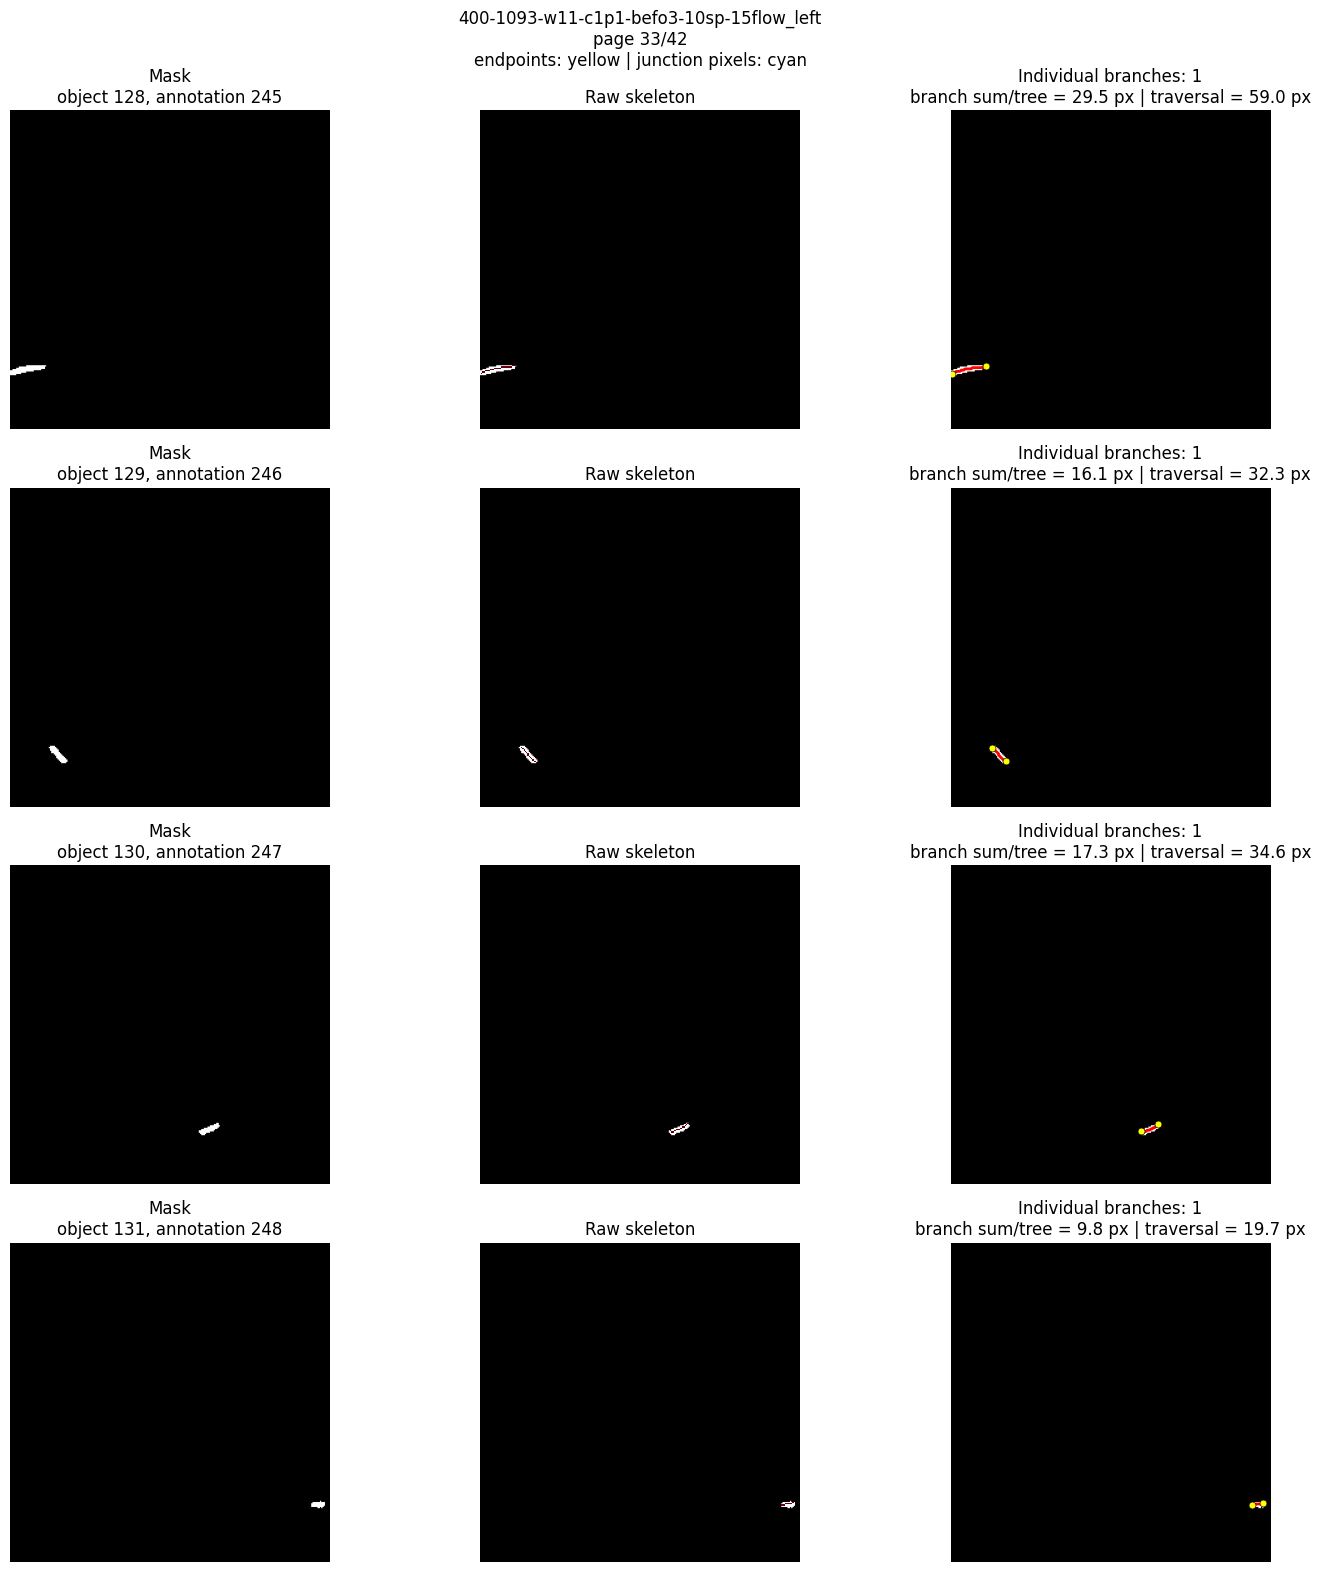

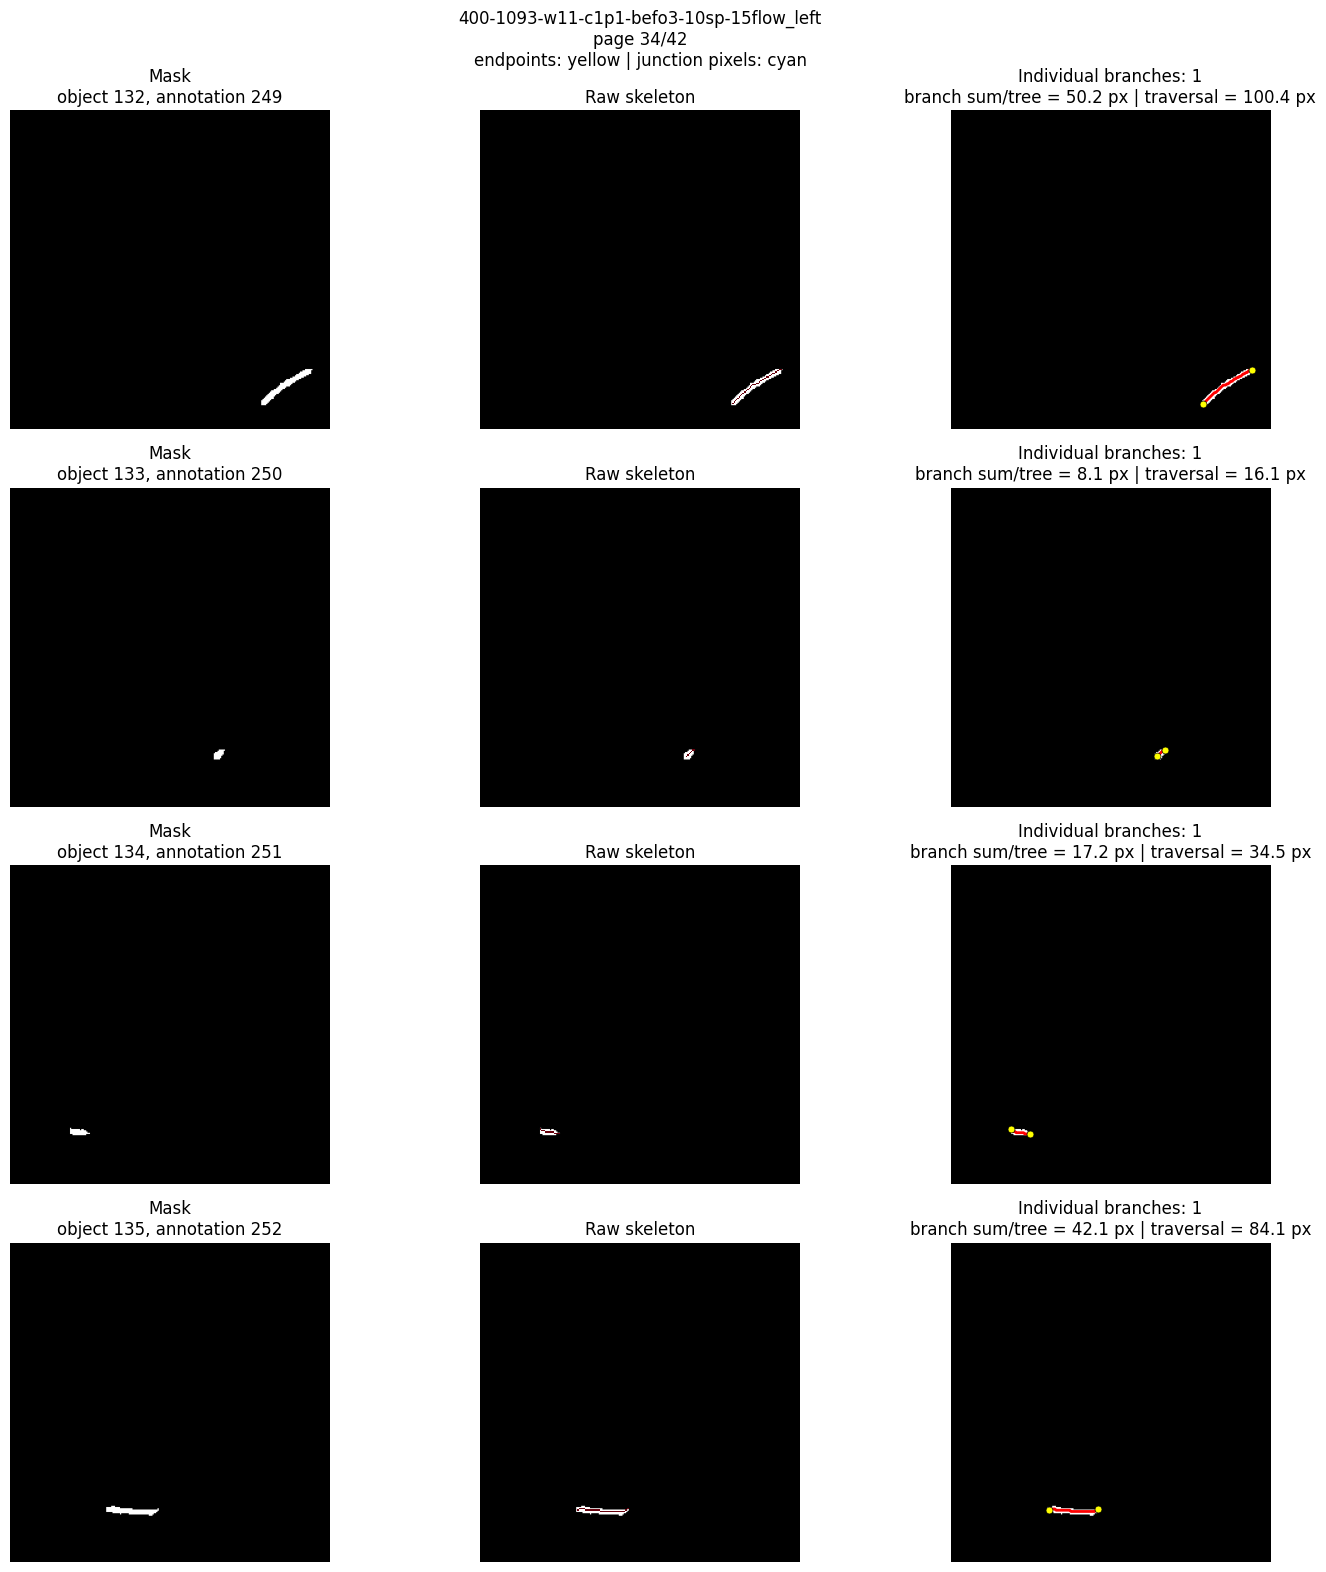

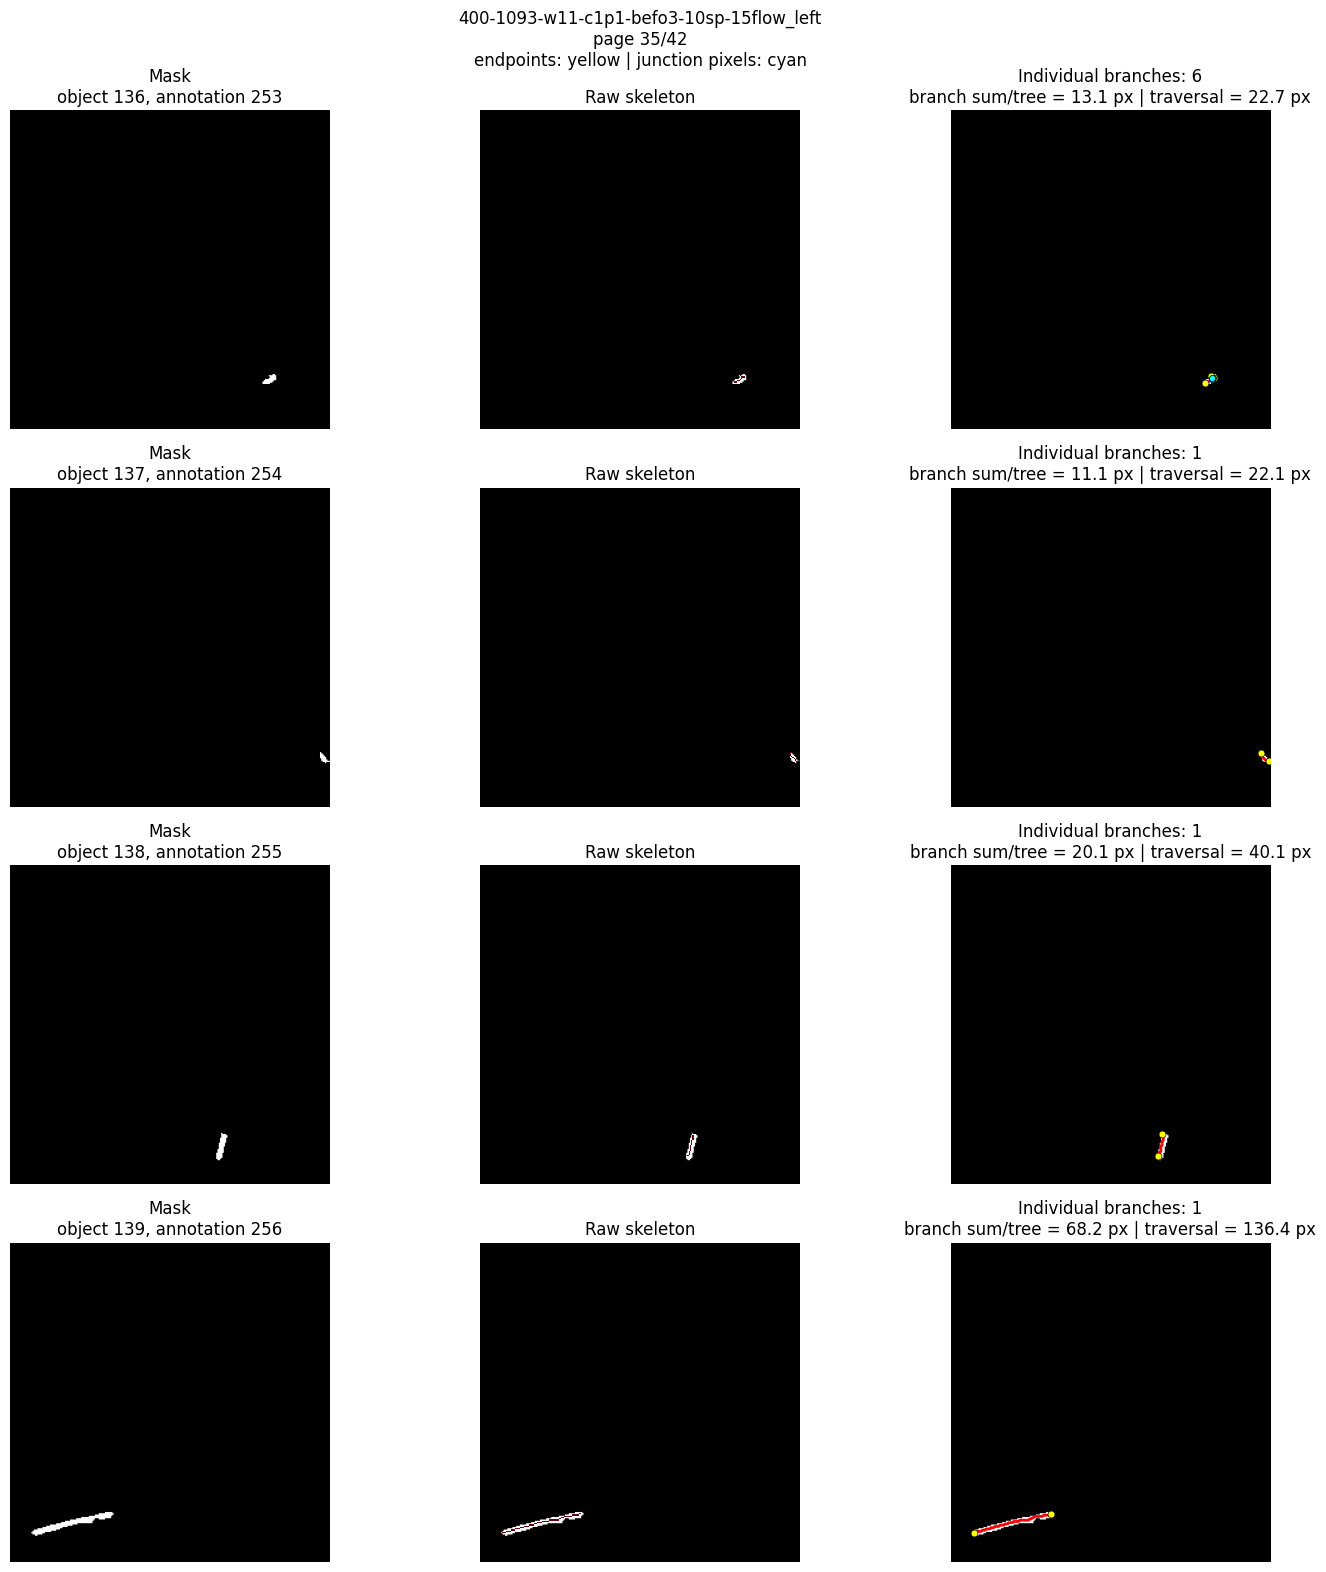

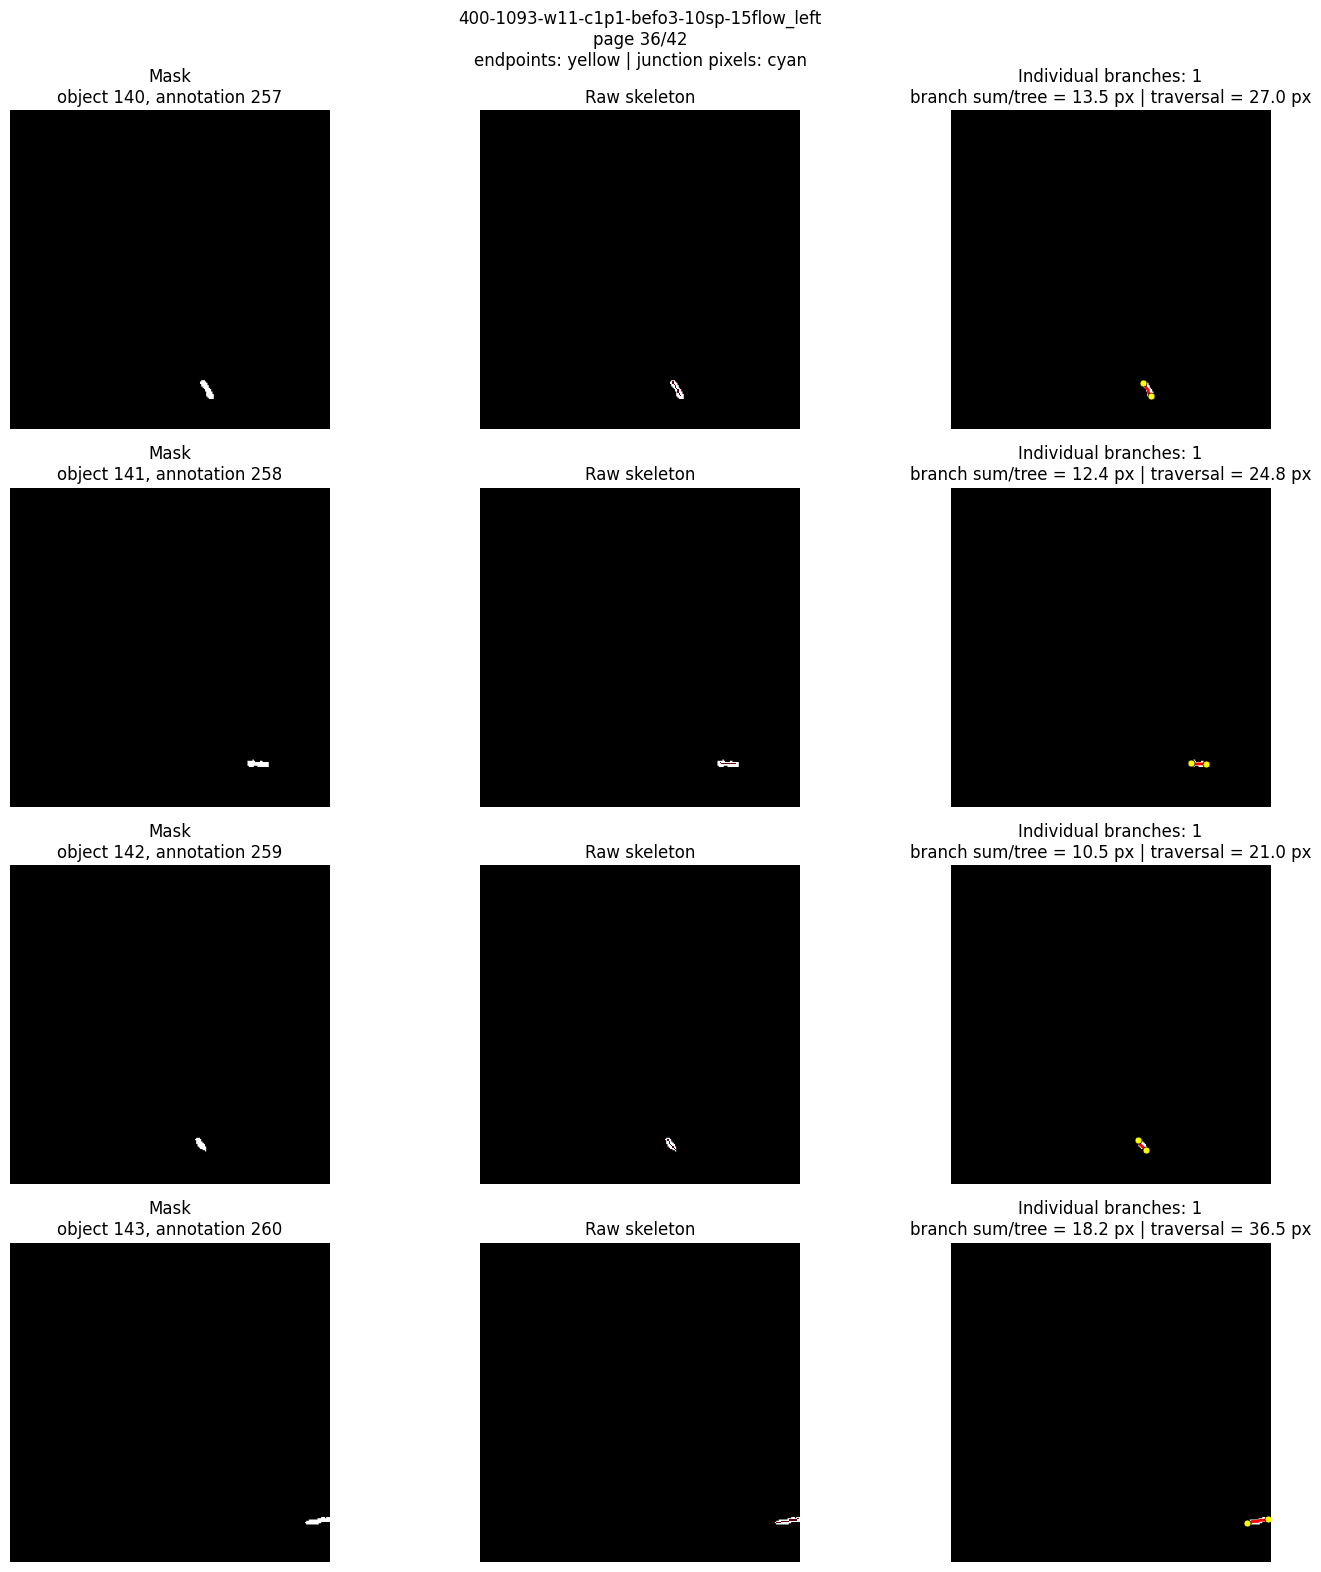

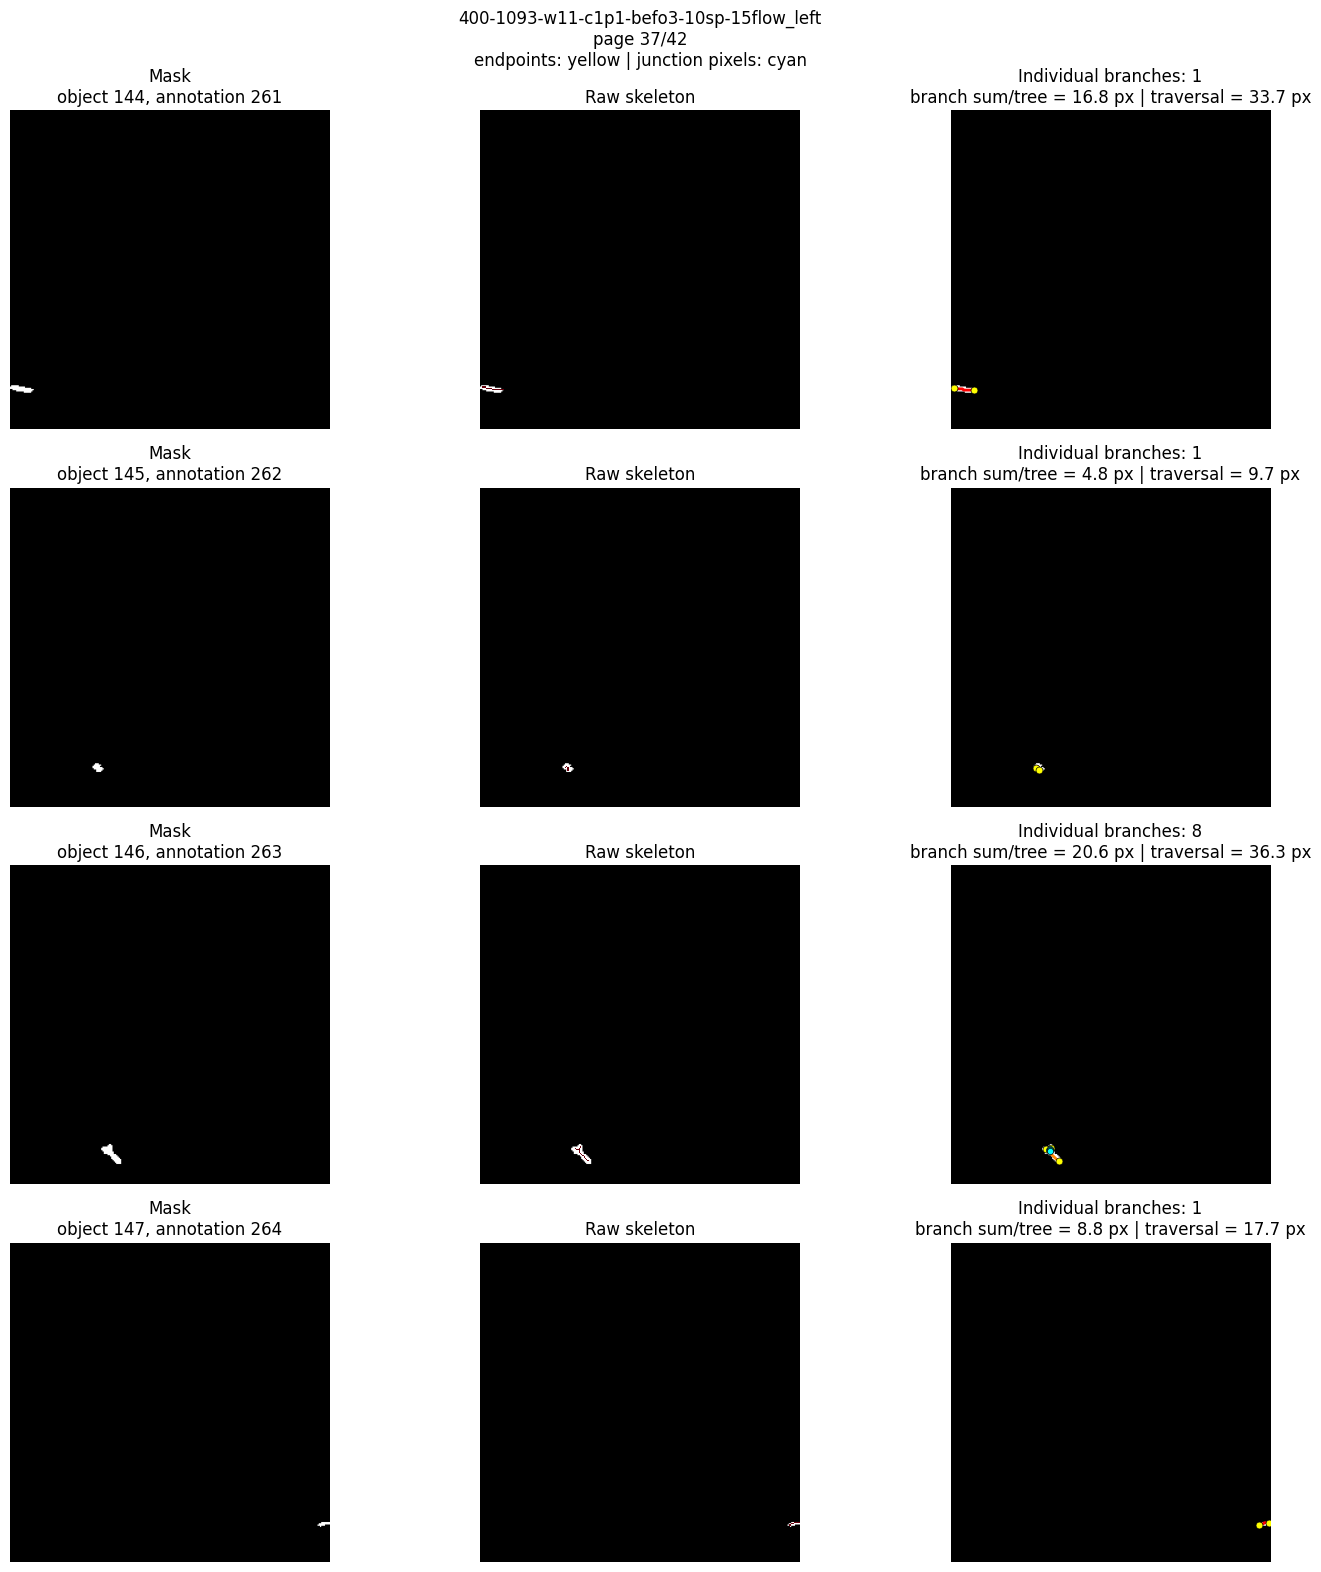

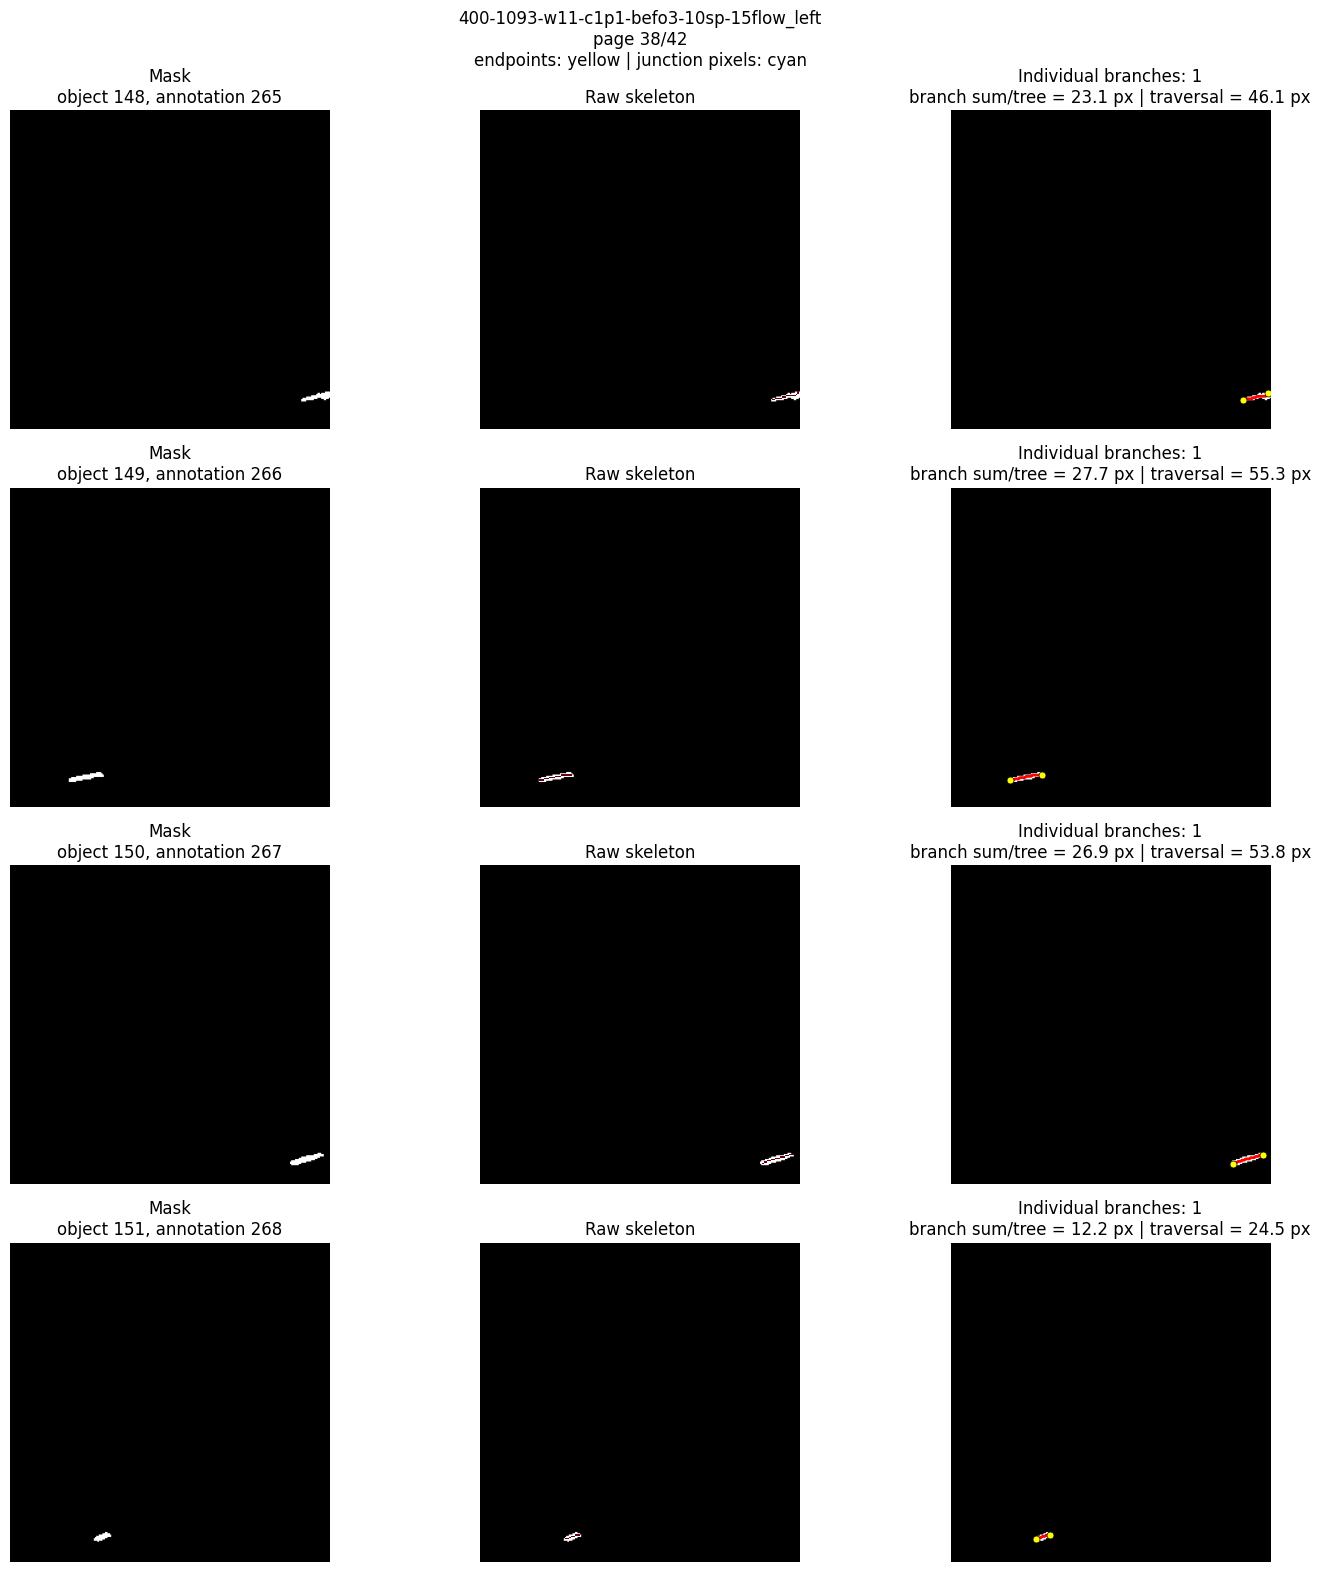

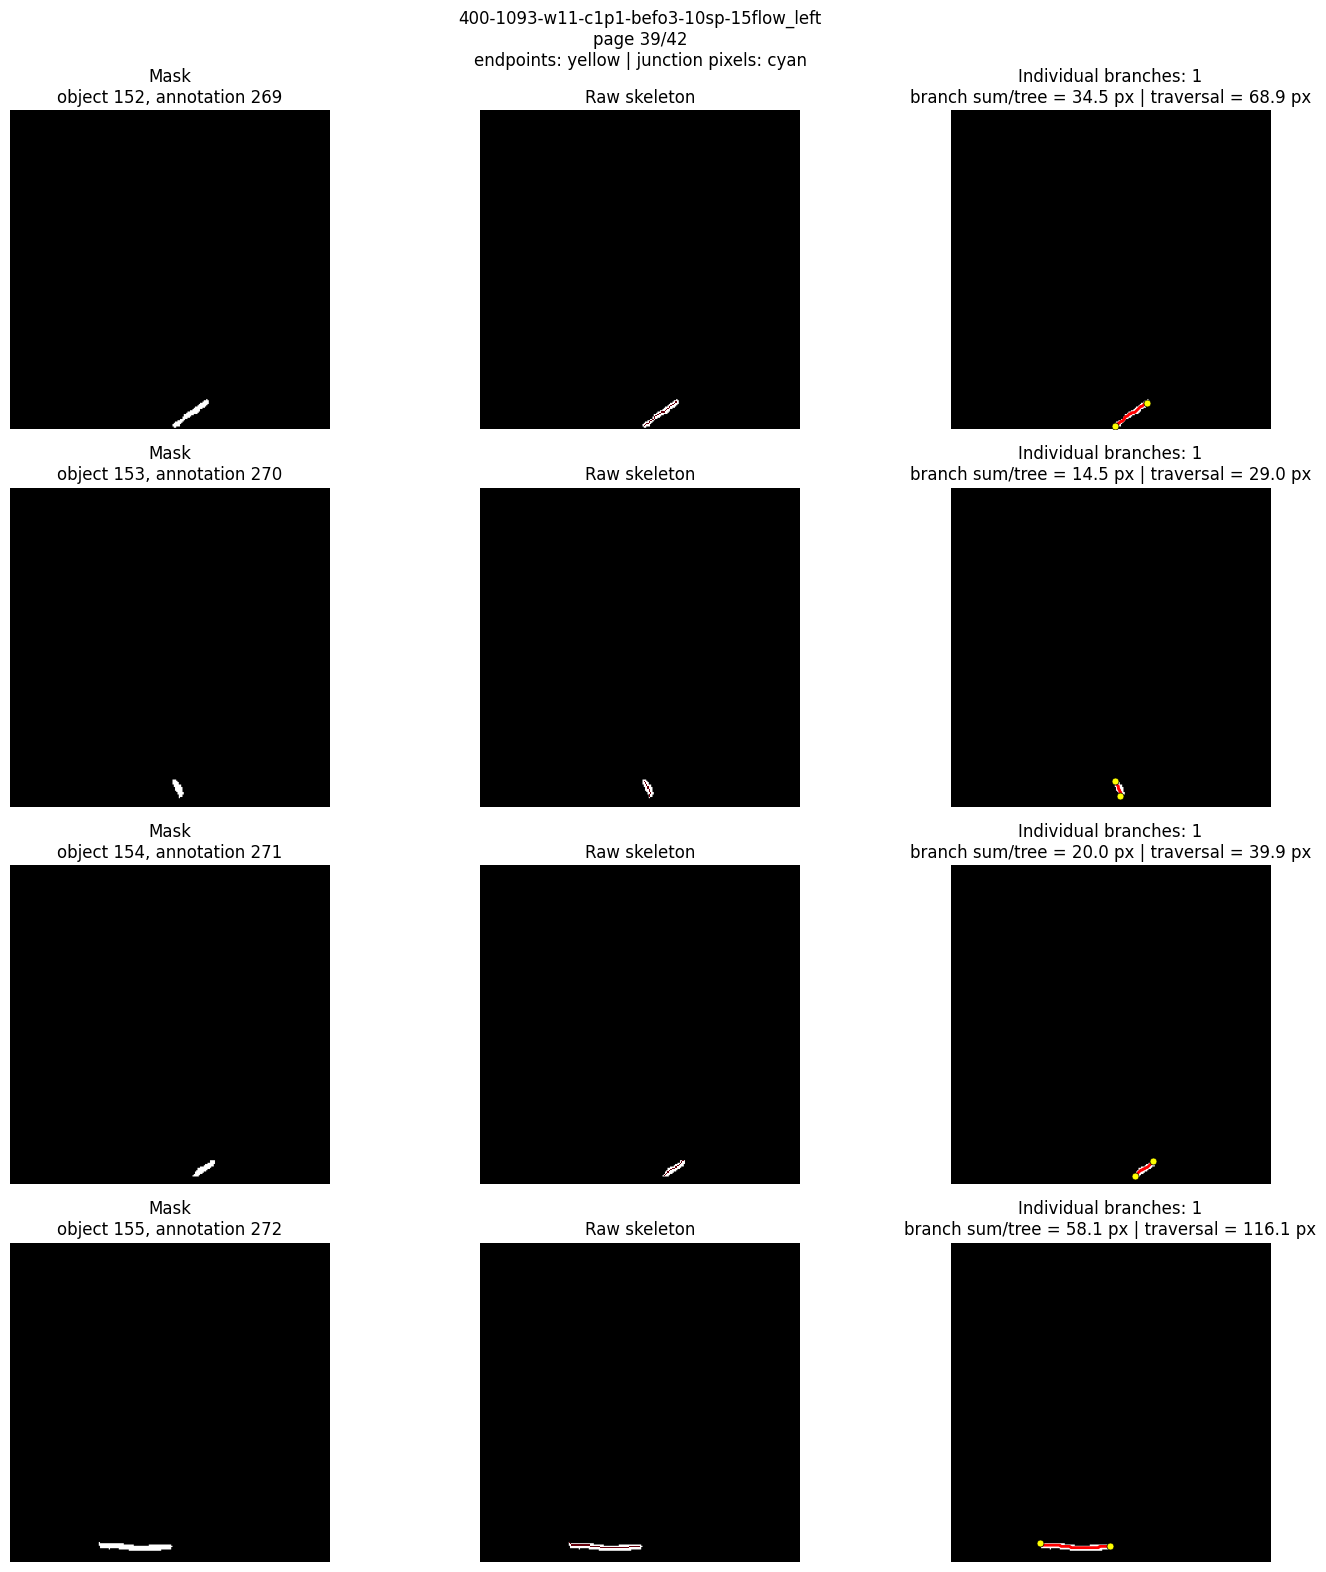

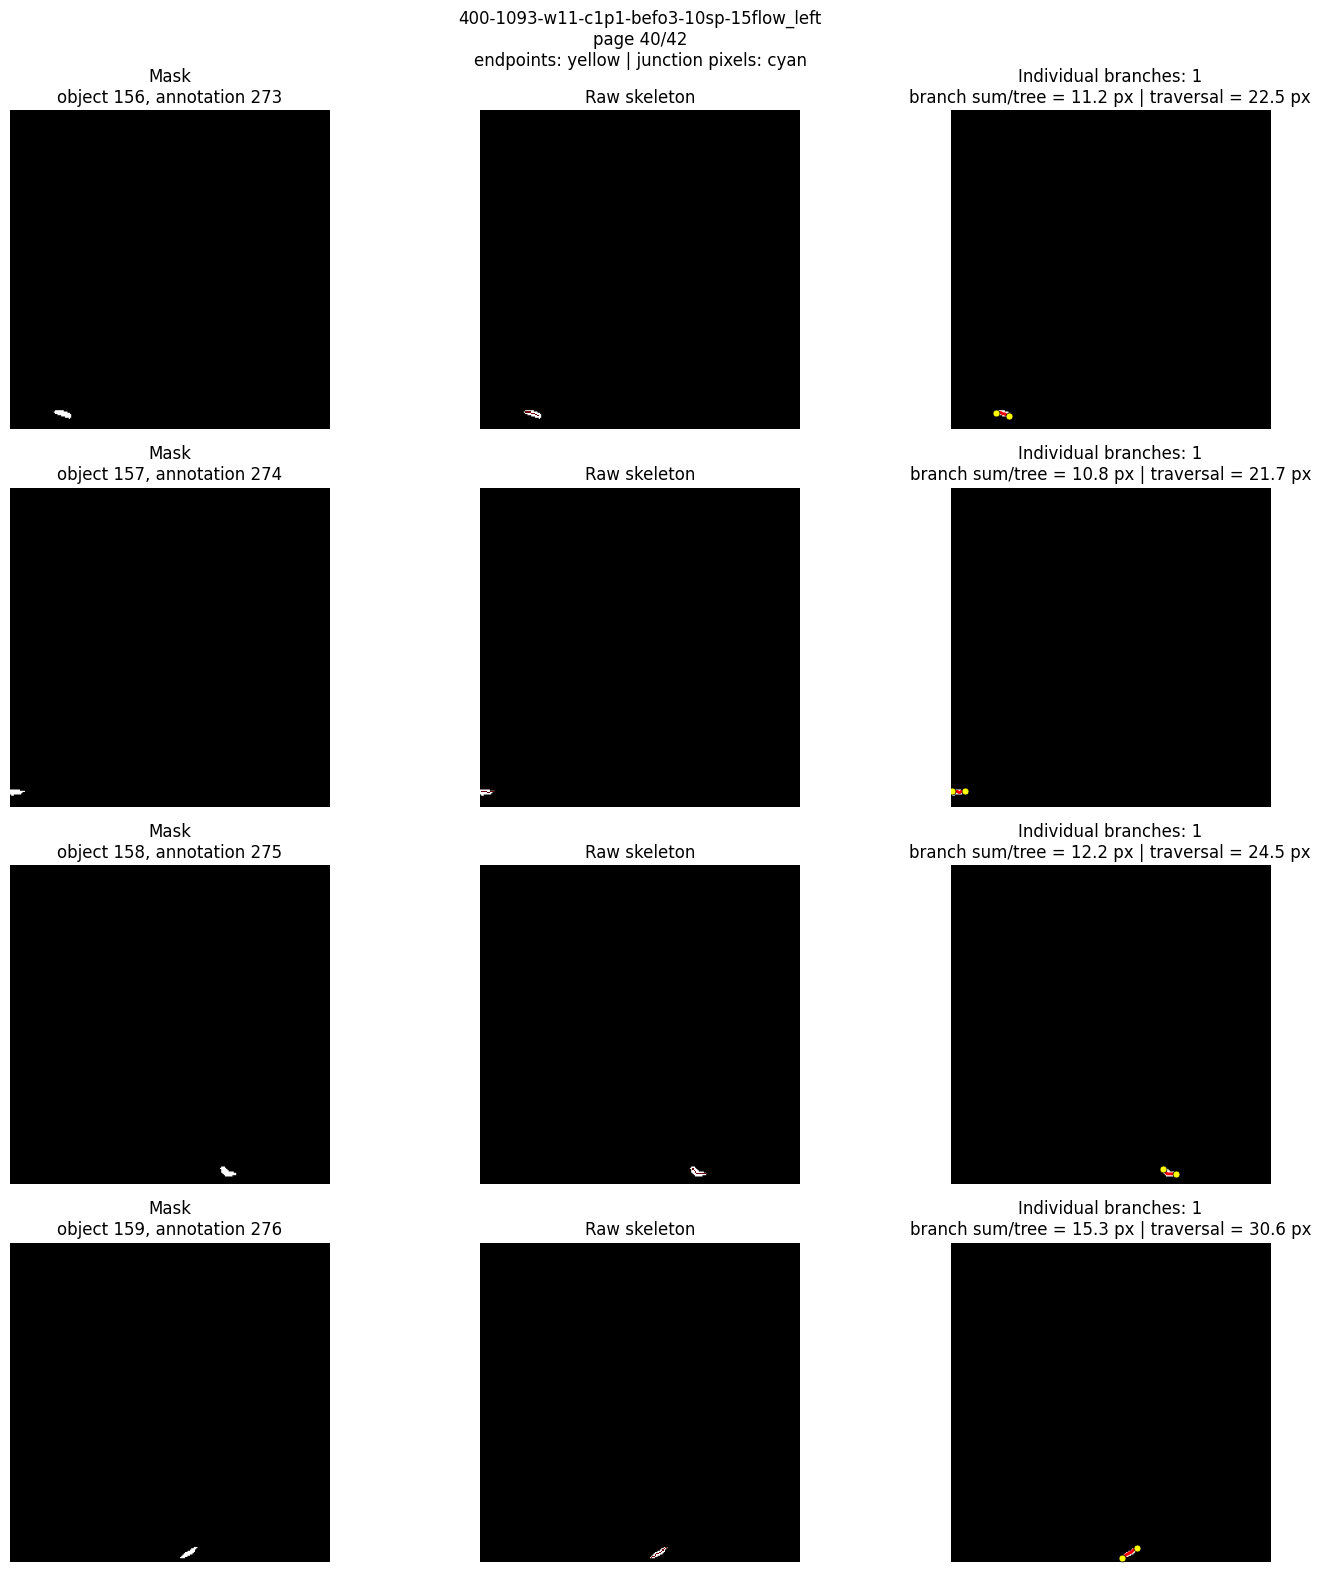

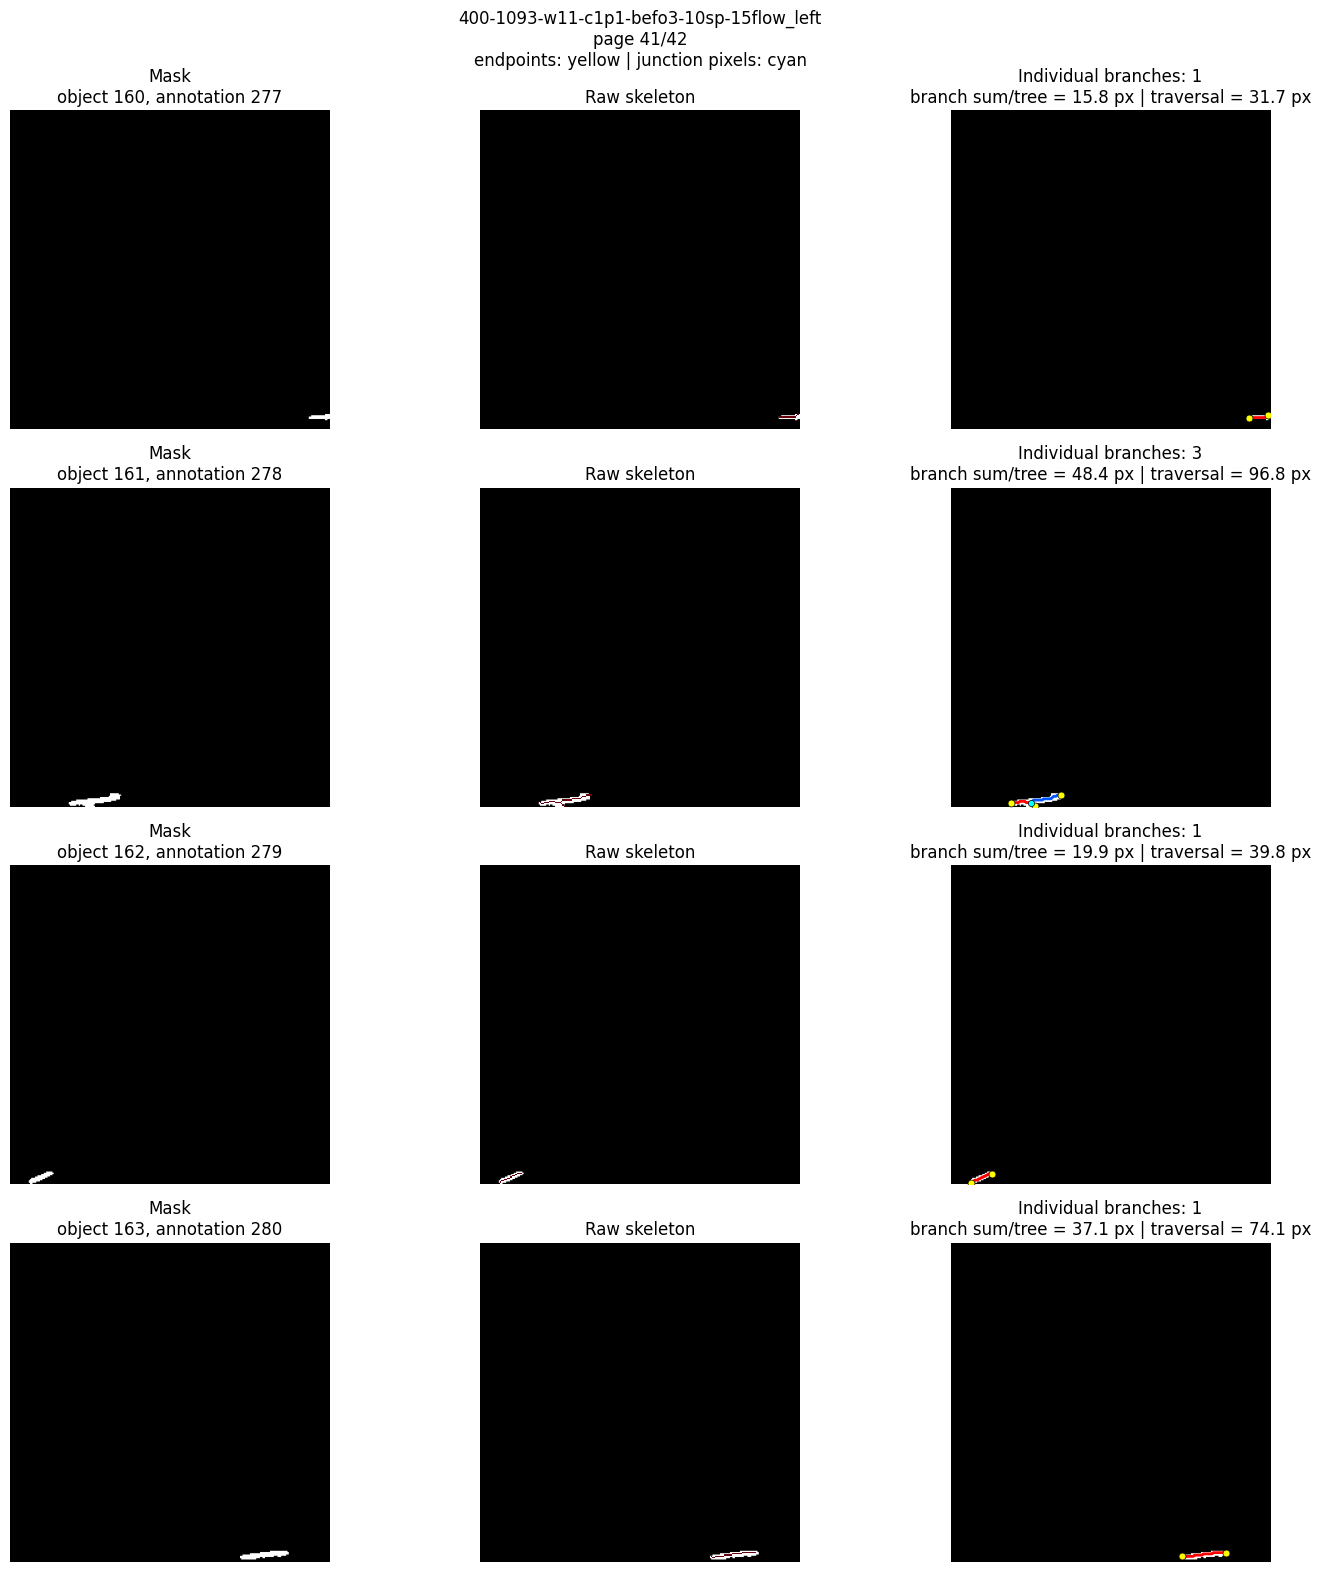

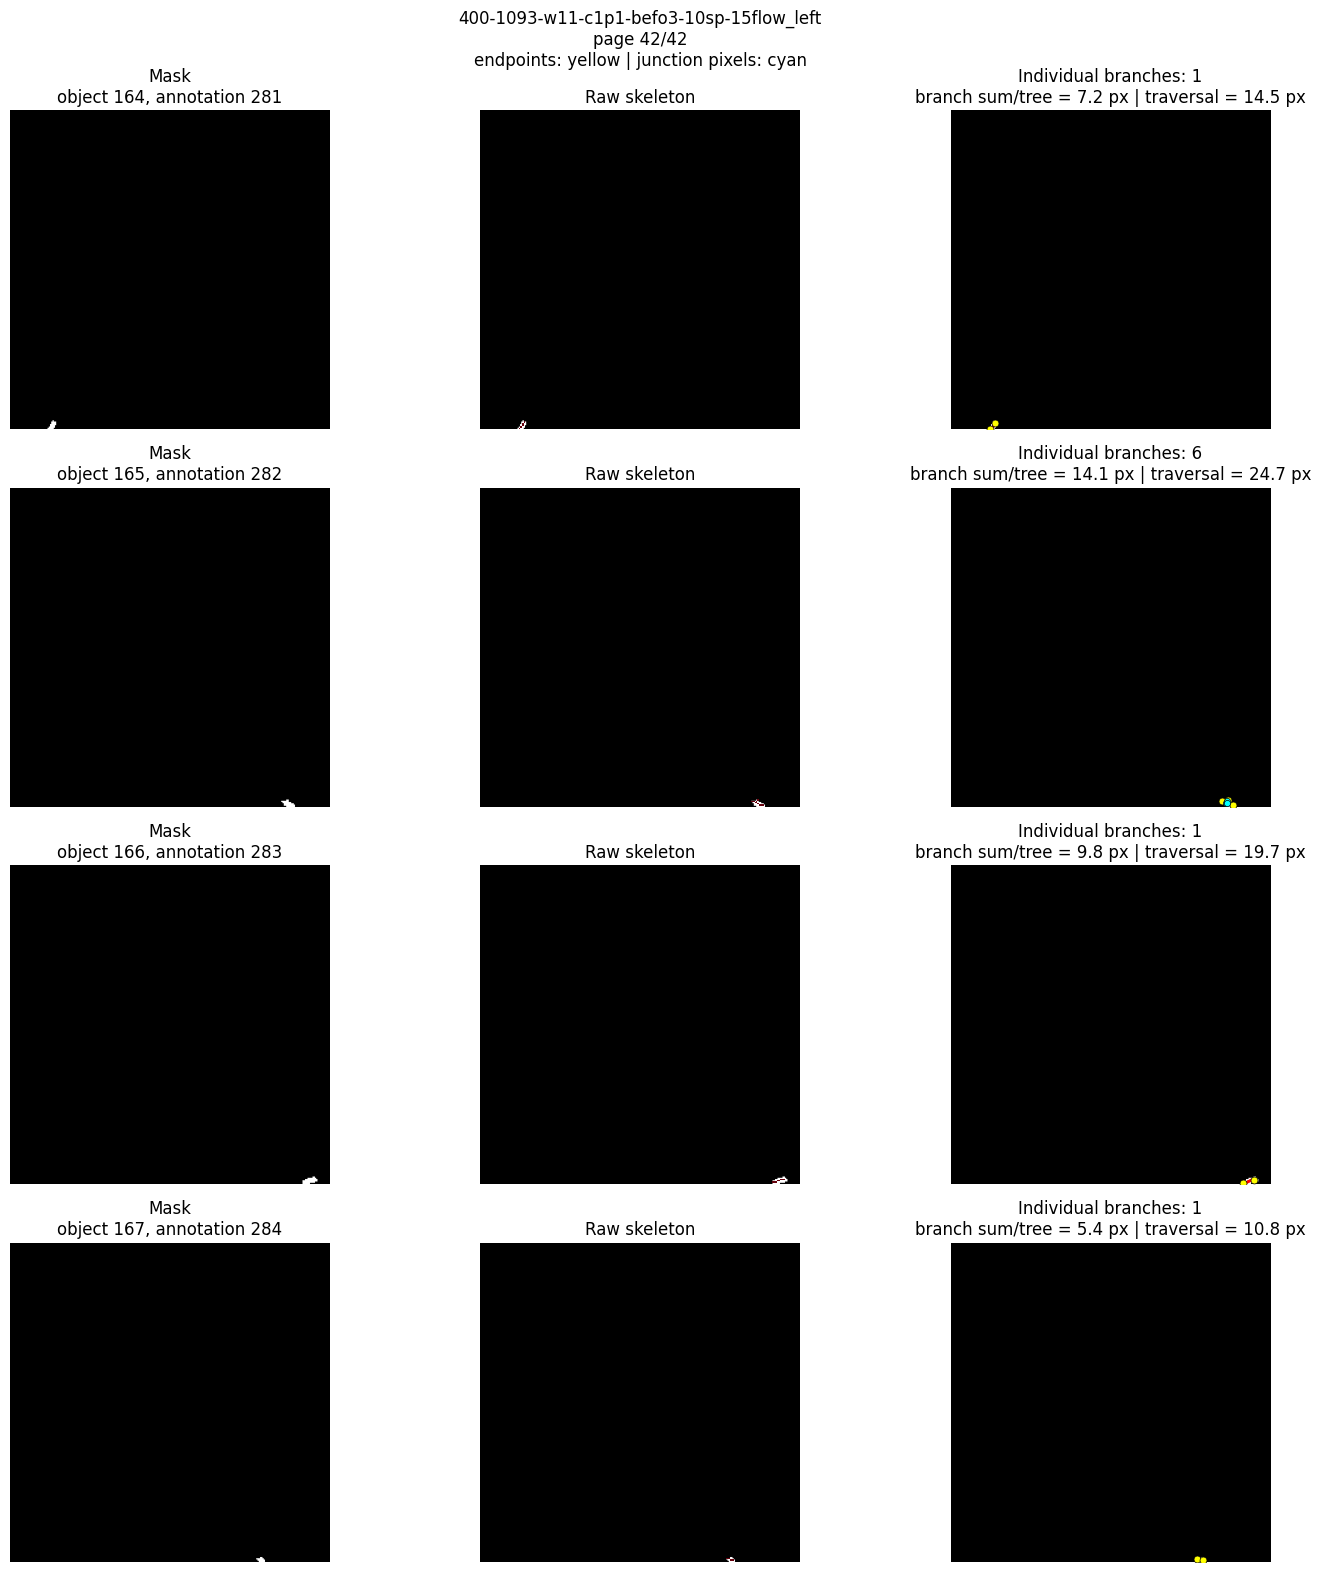

In [25]:
# %%
OBJECTS_PER_PAGE = 4

ordered_results = (
    length_results
    .sort_values("object_index")
    .reset_index(drop=True)
)

number_of_pages = int(
    np.ceil(
        len(ordered_results)
        / OBJECTS_PER_PAGE
    )
)

for page_index in range(number_of_pages):
    page_results = ordered_results.iloc[
        page_index * OBJECTS_PER_PAGE:
        (page_index + 1) * OBJECTS_PER_PAGE
    ]

    figure, axes = plt.subplots(
        len(page_results),
        3,
        figsize=(
            15,
            4 * len(page_results),
        ),
        squeeze=False,
    )

    for row_index, result_row in enumerate(
        page_results.itertuples(
            index=False
        )
    ):
        annotation_id = int(
            result_row.annotation_id
        )

        data = object_data[
            annotation_id
        ]

        mask = data["mask"]
        skeleton = data["skeleton"]
        graph = data["graph"]

        branches = extract_graph_branches(
            graph
        )

        branch_length_sum = sum(
            branch["length"]
            for branch in branches
        )

        mask_axis = axes[
            row_index,
            0,
        ]

        skeleton_axis = axes[
            row_index,
            1,
        ]

        branch_axis = axes[
            row_index,
            2,
        ]

        # --------------------------------------------------
        # Full-image mask
        # --------------------------------------------------

        mask_axis.imshow(
            mask,
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        mask_axis.set_title(
            f"Mask\n"
            f"object {int(result_row.object_index)}, "
            f"annotation {annotation_id}"
        )

        # --------------------------------------------------
        # Full-image skeleton
        # --------------------------------------------------

        skeleton_axis.imshow(
            mask,
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        skeleton_axis.imshow(
            np.ma.masked_where(
                ~skeleton,
                skeleton,
            ),
            cmap="Reds",
            vmin=0,
            vmax=1,
            interpolation="nearest",
        )

        skeleton_axis.set_title(
            "Raw skeleton"
        )

        # --------------------------------------------------
        # Individual retained branches
        # --------------------------------------------------

        branch_axis.imshow(
            mask,
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        color_positions = (
            np.arange(
                max(
                    len(branches),
                    1,
                ),
                dtype=float,
            )
            * 0.618033988749895
        ) % 1.0

        branch_colors = plt.cm.hsv(
            color_positions
        )

        for branch_index, branch in enumerate(
            branches
        ):
            path = branch["path"]
            branch_length = branch[
                "length"
            ]

            path_rows = [
                point[0]
                for point in path
            ]

            path_columns = [
                point[1]
                for point in path
            ]

            color = branch_colors[
                branch_index
            ]

            branch_axis.plot(
                path_columns,
                path_rows,
                color=color,
                linewidth=2.0,
                label=(
                    f"B{branch_index + 1}: "
                    f"{branch_length:.1f} px"
                ),
            )


        endpoints = [
            node
            for node in graph
            if graph.degree[node] == 1
        ]

        junctions = [
            node
            for node in graph
            if graph.degree[node] > 2
        ]

        if endpoints:
            branch_axis.scatter(
                [
                    point[1]
                    for point in endpoints
                ],
                [
                    point[0]
                    for point in endpoints
                ],
                color="yellow",
                edgecolor="black",
                linewidth=0.5,
                s=25,
                zorder=3,
            )

        if junctions:
            branch_axis.scatter(
                [
                    point[1]
                    for point in junctions
                ],
                [
                    point[0]
                    for point in junctions
                ],
                color="cyan",
                edgecolor="black",
                linewidth=0.5,
                s=20,
                zorder=3,
            )

        branch_axis.set_title(
            f"Individual branches: "
            f"{len(branches)}\n"
            f"branch sum/tree = "
            f"{branch_length_sum:.1f} px | "
            f"traversal = "
            f"{result_row.traversal_length_px:.1f} px"
        )

        # Keep the complete image coordinate system.
        for axis in (
            mask_axis,
            skeleton_axis,
            branch_axis,
        ):
            axis.set_xlim(
                -0.5,
                width - 0.5,
            )

            axis.set_ylim(
                height - 0.5,
                -0.5,
            )

            axis.set_aspect("equal")
            axis.axis("off")

    figure.suptitle(
        f"{TARGET_FILENAME}\n"
        f"page {page_index + 1}/"
        f"{number_of_pages}\n"
        "endpoints: yellow | "
        "junction pixels: cyan",
        fontsize=12,
    )

    figure.tight_layout()
    plt.show()